# ════════════════════════════════════════════════════════════
#  PART 1 — PRODUCTION PIPELINE
# ════════════════════════════════════════════════════════════

## 1.1 — Import & Configuration

In [1]:
import os
import json
import time
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, shape
from shapely import wkt
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import requests
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
import hdbscan
from sklearn.metrics import silhouette_score
import rasterio
from pyproj import Transformer
from shapely.geometry import box as shapely_box
from math import radians, cos, sin, asin, sqrt
from collections import Counter
import re
import shap
import optuna
from dotenv import load_dotenv
from rasterio.windows import from_bounds
from rasterio.warp import calculate_default_transform, reproject
from PIL import Image
from PIL import ImageEnhance, ImageFilter
from ultralytics import YOLO
from IPython.display import display, HTML
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from scipy.spatial import KDTree
import random
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from open_mastr import Mastr
import sqlite3
from urllib.parse import quote
from transformers import pipeline
from transformers import AutoProcessor, AutoModelForImageClassification

warnings.filterwarnings('ignore')

DATA_ROOT = r"C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw"


c:\Users\alexandre.batisse\.vscode\Projet\Projet_Stage_Scalian\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1.2 — TABULA Reference Data

In [2]:
def extract_tabula_data(filepath: str) -> dict:
    """Extrait automatiquement les consommations spécifiques du fichier TABULA."""
    df = pd.read_excel(filepath, header=0)
    
    tabula = {}
    renovation_states = ['not_renovated', 'partially_renovated', 'renovated']
    
    for block_idx, rs in enumerate(renovation_states):
        start = block_idx * 44
        end = start + 44
        
        for i in range(start, min(end, len(df))):
            row = df.iloc[i]
            bt_code = str(row.iloc[4]) if pd.notna(row.iloc[4]) else ''
            period = str(row.iloc[6]).strip() if pd.notna(row.iloc[6]) else ''
            val_15 = row.iloc[15]
            val_16 = row.iloc[16]
            
            if not bt_code or not period or pd.isna(val_15):
                continue
            
            # Exclure les sous-types (NBL, LightFrame)
            if 'NBL' in bt_code or '/' in bt_code:
                continue
            
            bt = bt_code.split('_')[0]
            heating = float(val_15)
            water = float(val_16) if pd.notna(val_16) else 0
            
            if bt not in tabula:
                tabula[bt] = {}
            if period not in tabula[bt]:
                tabula[bt][period] = {}
            tabula[bt][period][rs] = round(heating + water, 1)
    
    print(f"✓ TABULA extrait : {sum(len(p) for p in tabula.values())} combinaisons type×période")
    for bt in sorted(tabula.keys()):
        print(f"  {bt}: {len(tabula[bt])} périodes × {len(list(tabula[bt].values())[0])} états")
    
    return tabula

TABULA_SPECIFIC_HD = extract_tabula_data(r'C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw\TABULA.xlsx')

✓ TABULA extrait : 36 combinaisons type×période
  EFH: 10 périodes × 3 états
  GMH: 5 périodes × 3 états
  HH: 2 périodes × 3 états
  MFH: 10 périodes × 3 états
  RH: 9 périodes × 3 états


## 1.3 — Geocoding

In [3]:
def geocode_address(address: str) -> dict:
    """
    Géocode une adresse via Nominatim (OpenStreetMap).
    Retourne lat, lon, adresse formatée, et les détails.
    """
    geolocator = Nominatim(user_agent="building_disaggregation_research")
    geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)
    
    location = geocode(address, exactly_one=True, addressdetails=True)
    
    if location is None:
        print(f"❌ Adresse non trouvée : {address}")
        return None
    
    result = {
        'address_input': address,
        'address_found': location.address,
        'lat': location.latitude,
        'lon': location.longitude,
        'details': location.raw.get('address', {}),
    }
    
    print(f"✓ Géocodage réussi")
    print(f"  Adresse : {result['address_found']}")
    print(f"  Coordonnées : ({result['lat']:.6f}, {result['lon']:.6f})")
    
    return result

In [4]:
# ── Test avec une adresse ─────────────────────
# Remplace par une vraie adresse de ton dataset pour tester
# Baumberger Weg 150, Dusseldorf, Germany
#Husemannstraße 1, Gelsenkirchen, Germany
#Paul-Moor-Weg 5a, Bottrop, Germany
#Bestenweg 13, Gladbeck, Germany

TEST_ADDRESS = "Zur Marienkapelle 48, Gelsenkirchen, Germany"

geo_result = geocode_address(TEST_ADDRESS)
geo_result

✓ Géocodage réussi
  Adresse : 48, Zur Marienkapelle, Resse, Gelsenkirchen-Ost, Gelsenkirchen, Nordrhein-Westfalen, 45892, Deutschland
  Coordonnées : (51.585199, 7.079825)


{'address_input': 'Zur Marienkapelle 48, Gelsenkirchen, Germany',
 'address_found': '48, Zur Marienkapelle, Resse, Gelsenkirchen-Ost, Gelsenkirchen, Nordrhein-Westfalen, 45892, Deutschland',
 'lat': 51.5851986,
 'lon': 7.079825,
 'details': {'house_number': '48',
  'road': 'Zur Marienkapelle',
  'suburb': 'Resse',
  'city_district': 'Gelsenkirchen-Ost',
  'city': 'Gelsenkirchen',
  'state': 'Nordrhein-Westfalen',
  'ISO3166-2-lvl4': 'DE-NW',
  'postcode': '45892',
  'country': 'Deutschland',
  'country_code': 'de'}}

## 1.4 — City Detection & Config

In [5]:
# =============================================================================
# ANALYSE AUTOMATIQUE DU DATASET — Génère CITY_CONFIG et BUILDING_STATS
# =============================================================================

def analyze_dataset(df: pd.DataFrame, city_name: str = "Unknown") -> tuple[dict, dict]:
    """
    Analyse le dataset measured et génère automatiquement :
    - CITY_CONFIG : consommations spécifiques, heating distribution, ratios HS/FA
    - BUILDING_STATS : statistiques détaillées par building_type (seuils, distributions)
    
    Args:
        df: DataFrame du dataset measured (individuel)
        city_name: nom de la ville
    
    Returns:
        (city_config, building_stats)
    """
    
    print(f"{'=' * 60}")
    print(f"ANALYSE AUTOMATIQUE DU DATASET — {city_name}")
    print(f"{'=' * 60}")
    print(f"  {len(df)} bâtiments dans le dataset")
    
    # ── 1. Consommations spécifiques ───────────────────────────
    print("\n── Consommations spécifiques ──")
    df_a = df.copy()
    df_a['conso_specifique'] = df_a['initial_heat_demand'] / df_a['heated_space']
    df_a = df_a[(df_a['conso_specifique'] > 10) & (df_a['conso_specifique'] < 500)]
    
    conso_spec = {}
    for cyc in sorted(df_a['construction_year_class'].dropna().unique()):
        conso_spec[cyc] = {}
        for rs in ['not_renovated', 'partially_renovated', 'renovated']:
            subset = df_a[(df_a['construction_year_class'] == cyc) & (df_a['renovation_state'] == rs)]
            if len(subset) > 0:
                conso_spec[cyc][rs] = int(round(subset['conso_specifique'].median()))
            else:
                # Fallback : médiane globale de la classe
                fallback = df_a[df_a['construction_year_class'] == cyc]['conso_specifique'].median()
                conso_spec[cyc][rs] = int(round(fallback)) if pd.notna(fallback) else 100
        print(f"  {cyc}: NR={conso_spec[cyc]['not_renovated']}, PR={conso_spec[cyc]['partially_renovated']}, R={conso_spec[cyc]['renovated']}")
    
    # ── 2. Heating distribution par building_type ──────────────
    print("\n── Distribution heating system ──")
    heating_dist = {}
    if 'initial_heating_system' in df.columns:
        ct = pd.crosstab(df['building_type'], df['initial_heating_system'], normalize='index')
        for bt in ct.index:
            row = ct.loc[bt]
            top = row[row > 0.01].sort_values(ascending=False)
            heating_dist[bt] = {sys: int(round(pct * 100)) for sys, pct in top.head(6).items()}
            print(f"  {bt}: {heating_dist[bt]}")
    
    # ── 3. Ratio HS/FA par building_type ───────────────────────
    print("\n── Ratio heated_space / floor_area ──")
    df_a['ratio_hs_fa'] = df_a['heated_space'] / df_a['floor_area']
    hs_fa_ratio = {}
    for bt in df_a['building_type'].dropna().unique():
        subset = df_a[df_a['building_type'] == bt]
        ratio = subset['ratio_hs_fa'].median()
        hs_fa_ratio[bt] = round(ratio, 2) if pd.notna(ratio) else 1.0
        print(f"  {bt}: {hs_fa_ratio[bt]}")
    
    # ── 4. BUILDING_STATS — statistiques détaillées ────────────
    print("\n── Statistiques par building_type ──")
    building_stats = {}
    
    for bt in sorted(df['building_type'].dropna().unique()):
        subset = df[df['building_type'] == bt]
        stats = {
            'count': len(subset),
            'share_pct': round(len(subset) / len(df) * 100, 1),
        }
        
        # Stats pour chaque variable numérique clé
        for col in ['floor_area', 'heated_space', 'initial_heat_demand', 'construction_year']:
            if col in subset.columns:
                vals = subset[col].dropna()
                if len(vals) > 0:
                    stats[col] = {
                        'min': round(float(vals.min()), 1),
                        'p5': round(float(vals.quantile(0.05)), 1),
                        'p25': round(float(vals.quantile(0.25)), 1),
                        'median': round(float(vals.median()), 1),
                        'p75': round(float(vals.quantile(0.75)), 1),
                        'p95': round(float(vals.quantile(0.95)), 1),
                        'max': round(float(vals.max()), 1),
                    }
        
        # Stats pour construction_year_class (distribution)
        if 'construction_year_class' in subset.columns:
            cyc_dist = subset['construction_year_class'].value_counts(normalize=True)
            stats['construction_year_class_top3'] = {
                k: round(v * 100, 1) for k, v in cyc_dist.head(3).items()
            }
        
        # Stats pour renovation_state (distribution)
        if 'renovation_state' in subset.columns:
            rs_dist = subset['renovation_state'].value_counts(normalize=True)
            stats['renovation_state'] = {
                k: round(v * 100, 1) for k, v in rs_dist.items()
            }
        
        # Nombre d'appartements
        if 'number_of_apartments_min' in subset.columns:
            apt = subset['number_of_apartments_min'].dropna()
            if len(apt) > 0:
                stats['apartments'] = {
                    'median_min': int(apt.median()),
                    'median_max': int(subset['number_of_apartments_max'].dropna().median()) if 'number_of_apartments_max' in subset.columns else int(apt.median()),
                }
        # Ratio HS/FA comme proxy du nombre d'étages
        if 'heated_space' in subset.columns and 'floor_area' in subset.columns:
            ratio = subset['heated_space'] / subset['floor_area']
            ratio = ratio[(ratio > 0) & (ratio < 20)]
            if len(ratio) > 0:
                stats['ratio_hs_fa'] = {
                    'p25': round(float(ratio.quantile(0.25)), 2),
                    'median': round(float(ratio.median()), 2),
                    'p75': round(float(ratio.quantile(0.75)), 2),
                }
                
        building_stats[bt] = stats
        print(f"  {bt}: {stats['count']} bâtiments ({stats['share_pct']}%), "
              f"floor_area médian={stats.get('floor_area', {}).get('median', '?')}m²")
    
    # ── Construire le CITY_CONFIG ──────────────────────────────
    city_config = {
        "city_name": city_name,
        "conso_specifique": conso_spec,
        "heating_distribution": heating_dist,
        "hs_fa_ratio": hs_fa_ratio,
    }
    
    # Lister tous les systèmes de chauffage présents
    if 'initial_heating_system' in df.columns:
        all_systems = sorted(df['initial_heating_system'].dropna().unique().tolist())
        city_config['all_heating_systems'] = all_systems
        print(f"\n  Systèmes de chauffage : {all_systems}")
    
    print(f"\n{'=' * 60}")
    print(f"✓ Analyse terminée — {len(building_stats)} types de bâtiments analysés")
    
    return city_config, building_stats

In [6]:
# =============================================================================
# INITIALISATION AUTOMATIQUE PAR VILLE
# =============================================================================


def read_csv_auto(filepath: str) -> pd.DataFrame:
    """Lit un CSV en détectant automatiquement le séparateur."""
    # Lire les premières lignes pour détecter le séparateur
    with open(filepath, 'r', encoding='utf-8') as f:
        first_line = f.readline()
    
    # Compter les séparateurs potentiels
    sep_counts = {
        ',': first_line.count(','),
        ';': first_line.count(';'),
        '\t': first_line.count('\t'),
    }
    
    best_sep = max(sep_counts, key=sep_counts.get)
    print(f"  Séparateur détecté : '{repr(best_sep)}' ({sep_counts[best_sep]} occurrences)")
    
    df = pd.read_csv(filepath, sep=best_sep, encoding='utf-8')
    
    # Si une seule colonne, essayer avec un autre encodage
    if len(df.columns) <= 1:
        for enc in ['latin-1', 'iso-8859-1', 'cp1252']:
            try:
                df = pd.read_csv(filepath, sep=best_sep, encoding=enc)
                if len(df.columns) > 1:
                    print(f"  Encodage corrigé : {enc}")
                    break
            except:
                continue
    
    print(f"  ✓ {len(df)} lignes, {len(df.columns)} colonnes")
    return df

def initialize_city(city_name: str = None, data_folder: str = None, 
                    geo_details: dict = None) -> tuple[pd.DataFrame, pd.DataFrame, dict, dict, str]:
    """
    Initialise automatiquement la pipeline pour une ville donnée.
    
    Détecte la ville depuis le géocodage ou le nom fourni,
    charge les datasets, lance l'analyse, et retourne tout.
    
    Args:
        city_name: nom de la ville (optionnel si geo_details fourni)
        geo_details: dict retourné par geocode_address (pour auto-détection)
    
    Returns:
        (df_individual, df_blocks, city_config, building_stats, tif_folder)
    """
    # ── Auto-détection de la ville ─────────────────────────────
    if city_name is None and geo_details:
        city_name = geo_details.get('details', {}).get('city', 
                    geo_details.get('details', {}).get('town',
                    geo_details.get('details', {}).get('municipality', 'Unknown')))
    
    if city_name is None:
        raise ValueError("Impossible de déterminer la ville. Fournis city_name ou geo_details.")
    
    print(f"{'=' * 60}")
    print(f"INITIALISATION — {city_name}")
    print(f"{'=' * 60}")
    
    # ── Trouver le dossier de la ville ─────────────────────────
    if data_folder is None:
        data_folder = r"C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw"
    
    city_folder = os.path.join(data_folder, city_name)
    
    if not os.path.isdir(city_folder):
        # Essayer sans accent / avec variantes
        for folder in os.listdir(data_folder):
            if city_name.lower() in folder.lower():
                city_folder = os.path.join(data_folder, folder)
                break
    
    if not os.path.isdir(city_folder):
        raise FileNotFoundError(f"Dossier non trouvé : {city_folder}")
    
    print(f"  Dossier : {city_folder}")
    
    # ── Trouver les fichiers CSV ───────────────────────────────
    csv_files = [f for f in os.listdir(city_folder) if f.endswith('.csv')]
    
    path_individual = None
    path_aggregated = None
    
    for f in csv_files:
        f_lower = f.lower()
        if 'aggregat' in f_lower or 'geo_area' in f_lower:
            path_aggregated = os.path.join(city_folder, f)
        elif 'building' in f_lower or 'twin' in f_lower:
            path_individual = os.path.join(city_folder, f)
        else:
            # Fallback : le plus gros fichier est probablement l'individuel
            if path_individual is None:
                path_individual = os.path.join(city_folder, f)
    
    print(f"  Dataset individuel : {os.path.basename(path_individual)}")
    print(f"  Dataset agrégé : {os.path.basename(path_aggregated) if path_aggregated else 'NON TROUVÉ'}")
    
    # ── Trouver le dossier TIF ─────────────────────────────────
    tif_folder = None
    for subfolder in ['height', 'tif', 'heights', 'TIF']:
        candidate = os.path.join(city_folder, subfolder)
        if os.path.isdir(candidate):
            tif_folder = candidate
            break
    
    if tif_folder:
        n_tif = len([f for f in os.listdir(tif_folder) if f.endswith('.tif')])
        print(f"  TIF : {tif_folder} ({n_tif} fichiers)")
    else:
        print(f"  ⚠️ Pas de dossier TIF trouvé")
    
    # ── Charger les datasets ───────────────────────────────────

    print(f"\n  Chargement des données...")
    df_individual = read_csv_auto(path_individual)
    print(f"  Dataset individuel : {len(df_individual)} bâtiments")
    
    df_blocks = None
    if path_aggregated:
        df_blocks = read_csv_auto(path_aggregated)
        print(f"  Dataset agrégé : {len(df_blocks)} blocs")
    
    # ── Nettoyer les données ───────────────────────────────────
    df_individual = df_individual.dropna(subset=['heated_space', 'initial_heat_demand'])

    df_individual = df_individual[(df_individual['heated_space'] > 0) & (df_individual['initial_heat_demand'] > 0)]
    print(f"  Après nettoyage : {len(df_individual)} bâtiments")
    
    # ── Analyser le dataset ────────────────────────────────────
    city_config, building_stats = analyze_dataset(df_individual, city_name)
    
    # ── Ajouter les coordonnées du centre-ville ────────────────
    CITY_CENTERS = {
        "Düsseldorf": (51.2277, 6.7735),
        "Gelsenkirchen": (51.5177, 7.0857),
    }
    center = CITY_CENTERS.get(city_name, None)
    if center:
        city_config["center_lat"] = center[0]
        city_config["center_lon"] = center[1]
    else:
        # Utiliser le centroïde des données comme approximation
        if 'geometry' in df_individual.columns:
            print(f"  ⚠️ Centre-ville non défini pour {city_name} — utilisation du centroïde des données")
        city_config["center_lat"] = 0
        city_config["center_lon"] = 0
    
    print(f"\n✓ Initialisation complète pour {city_name}")
    
    # Renommer la variable pour être générique
    CITY_CENTER = (city_config["center_lat"], city_config["center_lon"])

    return df_individual, df_blocks, city_config, building_stats, tif_folder


In [7]:
# ── Initialisation à partir du géocodage ───────────────────────

detected_city = geo_result['details'].get('city', 
                geo_result['details'].get('town',
                geo_result['details'].get('municipality', None)))

print(f"Ville détectée : {detected_city}")

df_individual, df_blocks, CITY_CONFIG, BUILDING_STATS, TIF_FOLDER = initialize_city(
    city_name=detected_city,
    data_folder=DATA_ROOT
)

# Mettre à jour les variables globales utilisées dans le profiling
CITY_CENTER = (CITY_CONFIG.get("center_lat", 0), CITY_CONFIG.get("center_lon", 0))
PATH_TIF = TIF_FOLDER

# Afficher ce qui a été créé
print(json.dumps(CITY_CONFIG, indent=2, ensure_ascii=False, default=str))
print("\n")

Ville détectée : Gelsenkirchen
INITIALISATION — Gelsenkirchen
  Dossier : C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw\Gelsenkirchen
  Dataset individuel : Gelsenkirchen_digital_twin_buildings.csv
  Dataset agrégé : Gelsenkirchen_digital_twin_geo_area_aggregated.csv
  TIF : C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw\Gelsenkirchen\height (249 fichiers)

  Chargement des données...
  Séparateur détecté : '','' (113 occurrences)
  ✓ 44339 lignes, 114 colonnes
  Dataset individuel : 44339 bâtiments
  Séparateur détecté : '';'' (49 occurrences)
  ✓ 1723 lignes, 50 colonnes
  Dataset agrégé : 1723 blocs
  Après nettoyage : 44339 bâtiments
ANALYSE AUTOMATIQUE DU DATASET — Gelsenkirchen
  44339 bâtiments dans le dataset

── Consommations spécifiques ──
  1860 - 1918: NR=154, PR=123, R=79
  1919 - 1948: NR=150, PR=122, R=85
  1949 - 1978: NR=163, PR=118, R=72
  1979 - 1986: NR=137, PR=118, R=70
  1987 - 1990: NR=124, PR=1

## 1.5 — TIF Height Extraction

In [8]:
def extract_height_from_tif(lat: float, lon: float, tif_folder: str) -> dict:
    """
    Extrait la hauteur du bâtiment à partir d'un dossier de tuiles TIF.
    Parcourt les tuiles pour trouver celle qui contient le point.
    
    Args:
        lat, lon: coordonnées GPS du bâtiment
        tif_folder: dossier contenant les fichiers .tif
    """
    
    if not os.path.isdir(tif_folder):
        print(f"⚠️ Dossier TIF non trouvé : {tif_folder}")
        return None
    
    tif_files = [f for f in os.listdir(tif_folder) if f.endswith('.tif')]
    if not tif_files:
        print(f"⚠️ Aucun fichier .tif dans {tif_folder}")
        return None
    
    print(f"  {len(tif_files)} tuiles TIF disponibles")
    
    # Transformer les coordonnées GPS → UTM (EPSG:25832 comme ton code existant)
    transformer_to_utm = Transformer.from_crs('EPSG:4326', 'EPSG:25832', always_xy=True)
    x_utm, y_utm = transformer_to_utm.transform(lon, lat)
    
    # Chercher la bonne tuile
    for tif_name in tif_files:
        tif_path = os.path.join(tif_folder, tif_name)
        
        try:
            with rasterio.open(tif_path) as src:
                bounds = src.bounds
                
                # Vérifier si le point est dans cette tuile
                if (bounds.left <= x_utm <= bounds.right and 
                    bounds.bottom <= y_utm <= bounds.top):
                    
                    print(f"  ✓ Tuile trouvée : {tif_name}")
                    
                    # Lire la hauteur au point (fenêtre 5x5 pour robustesse)
                    row, col = src.index(x_utm, y_utm)
                    
                    window_size = 5
                    half = window_size // 2
                    row_start = max(0, row - half)
                    col_start = max(0, col - half)
                    
                    window = rasterio.windows.Window(col_start, row_start, window_size, window_size)
                    data = src.read(1, window=window)
                    
                    # Filtrer nodata et valeurs invalides
                    nodata = src.nodata if src.nodata is not None else -9999
                    valid = data[(data != nodata) & (data > 0)]
                    
                    if len(valid) == 0:
                        print("  ⚠️ Pas de donnée de hauteur valide à cette position")
                        return {'height_m': None, 'estimated_floors': None, 'source': 'tif_no_data'}
                    
                    height_max = float(valid.max())
                    height_p90 = float(np.percentile(valid, 90))
                    
                    # Estimation étages (3.4m par étage, comme ton code)
                    FLOOR_HEIGHT_M = 3.4
                    estimated_floors = max(1, round(height_p90 / FLOOR_HEIGHT_M))
                    
                    result = {
                        'height_max_m': round(height_max, 2),
                        'height_p90_m': round(height_p90, 2),
                        'estimated_floors': estimated_floors,
                        'tif_file': tif_name,
                        'tif_crs': str(src.crs),
                        'tif_resolution_m': round(src.res[0], 2),
                        'source': 'tif'
                    }
                    
                    print(f"  Hauteur max : {result['height_max_m']:.1f} m")
                    print(f"  Hauteur p90 : {result['height_p90_m']:.1f} m")
                    print(f"  Étages estimés : {result['estimated_floors']}")
                    print(f"  Résolution : {result['tif_resolution_m']}m/pixel")
                    
                    return result
                    
        except Exception as e:
            continue
    
    print(f"  ⚠️ Aucune tuile ne couvre le point ({lat}, {lon})")
    return None


# ── Test ───────────────────────────────────────────────────────

if geo_result and os.path.isdir(TIF_FOLDER):
    height_data = extract_height_from_tif(geo_result['lat'], geo_result['lon'], TIF_FOLDER)
else:
    print("ℹ️ TIF non disponible — la hauteur sera estimée par OSM ou par le LLM")
    height_data = None  

  249 tuiles TIF disponibles
  ✓ Tuile trouvée : ndom50_32366_5716_1_nw_2022.tif
  Hauteur max : 9.7 m
  Hauteur p90 : 9.3 m
  Étages estimés : 3
  Résolution : 0.5m/pixel


## 1.6 — Block Identification

In [9]:
def identify_block(lat: float, lon: float, df_blocks: pd.DataFrame) -> dict:
    """
    Identifie le bloc (floor) contenant le bâtiment.
    Utilise la colonne geometry du dataset agrégé.
    """
    point = Point(lon, lat)
    
    # Convertir les géométries texte en objets Shapely
    for idx, row in df_blocks.iterrows():
        geom_str = row.get('geometry', '')
        if not geom_str or pd.isna(geom_str):
            continue
        
        try:
            polygon = wkt.loads(geom_str)
            if polygon.contains(point):
                # Extraire les données du bloc
                block_data = row.to_dict()
                
                print(f"✓ Bloc identifié")
                print(f"  Floor ID : {row.get('floor_area_id', '?')}")
                print(f"  Nom : {row.get('floor_area_name', '?')}")
                print(f"  Nombre de bâtiments : {row.get('building_count', '?')}")
                
                # Afficher les proportions principales
                bt_cols = [c for c in df_blocks.columns if c.startswith('building_type__')]
                if bt_cols:
                    print(f"  Répartition building_type :")
                    for col in bt_cols:
                        val = row[col]
                        if val > 0.01:
                            type_name = col.replace('building_type__', '')
                            print(f"    {type_name}: {val*100:.1f}%")
                
                return block_data
        except Exception as e:
            continue
    
    print(f"❌ Aucun bloc trouvé pour ({lat}, {lon})")
    print(f"   → Le bâtiment est peut-être en dehors des limites des blocs")
    return None

## 1.7 — Spatial Context

In [10]:
def haversine(lat1, lon1, lat2, lon2):
    """Distance en km entre deux points GPS."""
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * 6371 * asin(sqrt(a))


def compute_spatial_context(lat: float, lon: float, block_data: dict = None) -> dict:
    """
    Calcule les features de contexte spatial enrichies pour un bâtiment.
    
    Combine 3 sources :
    - Distance au centre-ville (géométrique)
    - Densité et types des bâtiments voisins (OSM)
    - Proportions du bloc agrégé (dataset CoEnergy)
    """
    result = {}
    
    # ── 1. Distance au centre-ville ────────────────────────────
    dist_center = haversine(lat, lon, CITY_CENTER[0], CITY_CENTER[1])
    result['distance_center_km'] = round(dist_center, 2)
    
    # ── 2. Densité et profil des bâtiments voisins (OSM) ──────
    print("  Récupération des bâtiments voisins (OSM)...")
    neighbors = get_nearby_buildings_profile(lat, lon, radius=200)
    result.update(neighbors)
    
    # ── 3. Proportions du bloc (si disponible) ─────────────────
    if block_data:
        result['block_building_count'] = block_data.get('building_count', None)

        # Répartition complète building_type
        bt_cols = {k.replace('building_type__', ''): round(v * 100, 1) 
                   for k, v in block_data.items() 
                   if k.startswith('building_type__') and isinstance(v, (int, float)) and v > 0.01}
        result['block_building_type_distribution'] = bt_cols
        
        # Répartition complète construction_year_class
        cyc_cols = {k.replace('construction_year_class__', ''): round(v * 100, 1)
                    for k, v in block_data.items() 
                    if k.startswith('construction_year_class__') and isinstance(v, (int, float)) and v > 0.01}
        result['block_construction_year_distribution'] = cyc_cols
        
        # Répartition complète heating_system
        hs_cols = {k.replace('initial_heating_system__', ''): round(v * 100, 1) 
                   for k, v in block_data.items() 
                   if k.startswith('initial_heating_system__') and isinstance(v, (int, float)) and v > 0.01}
        result['block_heating_distribution'] = hs_cols
        
        # Répartition complète renovation_state
        rs_cols = {k.replace('renovation_state__', ''): round(v * 100, 1) 
                   for k, v in block_data.items() 
                   if k.startswith('renovation_state__') and isinstance(v, (int, float)) and v > 0.01}
        result['block_renovation_distribution'] = rs_cols


    # ── Résumé ─────────────────────────────────────────────────
    print(f"✓ Contexte spatial calculé")
    print(f"  Distance centre-ville : {result['distance_center_km']:.2f} km")
    print(f"  Bâtiments dans 200m : {result.get('n_neighbors', '?')}")
    print(f"  Hauteur moy. voisins : {result.get('neighbor_avg_levels', '?')} niveaux")
    print(f"  Types voisins : {result.get('neighbor_building_types', '?')}")
    if block_data:
        print(f"  Répartition building_type dans le bloc : {result.get('block_building_type_distribution', '?')}")
        print(f"  Répartition construction_year_class dans le bloc : {result.get('block_construction_year_distribution', '?')}")
        print(f"  Répartition heating_system dans le bloc : {result.get('block_heating_distribution', '?')}")
        print(f"  Répartition renovation_state dans le bloc : {result.get('block_renovation_distribution', '?')}")
    
    return result


def get_nearby_buildings_profile(lat: float, lon: float, radius: int = 200) -> dict:
    """
    Récupère le profil des bâtiments voisins via OSM :
    - Nombre de bâtiments
    - Distribution des types (residential, commercial, industrial...)
    - Nombre moyen d'étages
    """
    overpass_url = "https://overpass-api.de/api/interpreter"
    query = f"""
    [out:json][timeout:15];
    way["building"](around:{radius},{lat},{lon});
    out tags;
    """

    max_retries = 5
    for attempt in range(max_retries):
        try:
            response = requests.post(
                overpass_url,
                data={'data': query},
                timeout=30,
                headers={'User-Agent': 'building_disaggregation_research/1.0'}
            )

            if response.status_code == 429 or response.status_code == 504:
                wait = 10 * (attempt + 1)
                print(f"  ⚠️ Overpass HTTP {response.status_code} — attente {wait}s (tentative {attempt+1}/{max_retries})")
                time.sleep(wait)
                continue

            if response.status_code != 200:
                print(f"  ⚠️ Overpass HTTP {response.status_code} — tentative {attempt+1}/{max_retries}")
                time.sleep(5)
                continue

            if not response.text or len(response.text.strip()) == 0:
                print(f"  ⚠️ Réponse vide — tentative {attempt+1}/{max_retries}")
                time.sleep(5)
                continue

            data = response.json()
            elements = data.get('elements', [])

            if elements:
                break
            else:
                print(f"  ⚠️ Aucun élément retourné — tentative {attempt+1}/{max_retries}")
                time.sleep(5)
                continue

        except Exception as e:
            print(f"  ⚠️ Erreur : {e} — tentative {attempt+1}/{max_retries}")
            time.sleep(5)
            continue
    else:
        print(f"  ❌ Échec après {max_retries} tentatives")
        return {'n_neighbors': None, 'neighbor_building_types': {}}

    # Compter les types de bâtiments
    building_types = []
    levels_list = []

    for el in elements:
        tags = el.get('tags', {})
        bt = tags.get('building', 'yes')
        building_types.append(bt)

        levels = tags.get('building:levels')
        if levels:
            try:
                levels_list.append(float(levels))
            except ValueError:
                pass

    # Distribution des types
    type_counts = Counter(building_types)
    total = len(building_types)
    type_distribution = {k: round(v/total, 3) for k, v in type_counts.most_common(5)}

    result = {
        'n_neighbors': len(elements),
        'neighbor_building_types': type_distribution,
        'neighbor_dominant_type': type_counts.most_common(1)[0][0] if type_counts else 'unknown',
    }

    # Hauteur moyenne si disponible
    if levels_list:
        result['neighbor_avg_levels'] = round(np.mean(levels_list), 1)
        result['neighbor_max_levels'] = int(max(levels_list))
        result['neighbor_levels_available'] = len(levels_list)
    else:
        result['neighbor_avg_levels'] = None
        result['neighbor_max_levels'] = None
        result['neighbor_levels_available'] = 0

    return result

## 1.8 — Building Profiling

In [11]:
def collect_building_profile(address: str, df_blocks: pd.DataFrame, tif_path: str = None) -> dict:
    """
    Pipeline complète Phase 1 : adresse → profil complet du bâtiment.
    
    Retourne un dictionnaire avec toutes les données collectées,
    prêt à être passé au LLM pour prédiction.
    """
    print("=" * 60)
    print(f"PROFIL BÂTIMENT : {address}")
    print("=" * 60)
    
    profile = {'address': address}
    
    # 1. Géocodage
    print("\n── Étape 1 : Géocodage ──")
    geo = geocode_address(address)
    if geo is None:
        return None
    profile['geocoding'] = geo
    
    # 2. Empreinte bâtiment depuis le dataset individuel
    print("\n── Étape 2 : Empreinte bâtiment (dataset individuel) ──")
    footprint = None

    street_name = geo['details'].get('road') or geo['details'].get('street') or ''
    house_number = str(geo['details'].get('house_number', '')).strip()

    if 'street' in df_individual.columns:
        candidates = df_individual.copy()

        if street_name:
            street_lower = street_name.strip().lower()
            mask = pd.Series(False, index=candidates.index)
            if house_number:
                exact_address = f"{street_lower} {house_number}".strip()
                reverse_address = f"{house_number} {street_lower}".strip()
                mask |= candidates['street'].fillna('').str.lower().str.contains(exact_address, na=False)
                mask |= candidates['street'].fillna('').str.lower().str.contains(reverse_address, na=False)
            mask |= candidates['street'].fillna('').str.lower().str.contains(street_lower, na=False)
            candidates = candidates[mask]

        if len(candidates) == 0 and 'postal_code' in df_individual.columns and geo['details'].get('postcode'):
            candidates = df_individual[
                df_individual['postal_code'].astype(str).fillna('').str.contains(str(geo['details']['postcode']), na=False)
            ]

        if len(candidates) > 1 and 'geometry' in df_individual.columns:
            point = Point(geo['lon'], geo['lat'])
            candidates = candidates.copy()
            candidates['distance_to_point'] = candidates['geometry'].apply(
                lambda geom: Point(geo['lon'], geo['lat']).distance(wkt.loads(geom).centroid)
                if pd.notna(geom) else np.inf
            )
            candidates = candidates.sort_values('distance_to_point')

        if len(candidates) > 0:
            matched = candidates.iloc[0]
            footprint = {
                'source': 'dataset_match',
                'matched_street': matched.get('street'),
                'floor_area_m2': float(matched.get('floor_area')) if pd.notna(matched.get('floor_area')) else None,
                'geometry_wkt': matched.get('geometry'),
            }

    profile['footprint'] = footprint
    print(f"  Surface au sol : {footprint['floor_area_m2']:.1f} m²" if footprint and footprint.get('floor_area_m2') else "  Surface au sol : N/A")
    
# 3. Hauteur TIF (si disponible)
    print("\n── Étape 3 : Hauteur (TIF) ──")
    if tif_path and os.path.isdir(tif_path):
        height = extract_height_from_tif(geo['lat'], geo['lon'], tif_path)
        profile['height'] = height
    elif tif_path and os.path.isfile(tif_path):
        # Cas d'un fichier TIF unique
        height = extract_height_from_tif(geo['lat'], geo['lon'], os.path.dirname(tif_path))
        profile['height'] = height
    else:
        # Utiliser les niveaux OSM comme fallback
        osm_levels = footprint.get('osm_levels') if footprint else None
        if osm_levels:
            estimated_height = int(osm_levels) * 3.0
            profile['height'] = {
                'height_max_m': estimated_height,
                'estimated_floors': int(osm_levels),
                'source': 'osm_levels'
            }
            print(f"  ℹ️ Hauteur estimée via OSM levels : {estimated_height}m ({osm_levels} étages)")
        else:
            profile['height'] = None
            print(f"  ⚠️ Hauteur non disponible (tif_path={tif_path})")
    
    # 4. Identification du bloc
    print("\n── Étape 4 : Identification du bloc ──")
    block = identify_block(geo['lat'], geo['lon'], df_blocks)
    profile['block_data'] = block

    # 5. Contexte spatial
    print("\n── Étape 5 : Contexte spatial ──")
    spatial = compute_spatial_context(geo['lat'], geo['lon'], block_data=block) 
    profile['spatial_context'] = spatial
    
    # 6. Résumé
    print("\n" + "=" * 60)
    print("RÉSUMÉ DU PROFIL")
    print("=" * 60)
    print(f"  Adresse : {geo['address_found']}")
    print(f"  Coordonnées : ({geo['lat']:.6f}, {geo['lon']:.6f})")
    if footprint:
        print(f"  Surface au sol (OSM) : {footprint['floor_area_m2']:.1f} m²")
    if profile.get('height'):
        print(f"  Hauteur : {profile['height']['height_max_m']:.1f} m ({profile['height']['estimated_floors']} étages)")
    print(f"  Distance centre-ville : {spatial['distance_center_km']:.2f} km")
    if block:
        print(f"  Bloc : {block.get('floor_area_name', '?')} ({block.get('building_count', '?')} bâtiments)")
    
    return profile

# ── Test complet ───────────────────────────────────────────
profile = collect_building_profile(
    address=TEST_ADDRESS,
    df_blocks=df_blocks,
    tif_path=PATH_TIF if os.path.exists(PATH_TIF) else None
)

PROFIL BÂTIMENT : Zur Marienkapelle 48, Gelsenkirchen, Germany

── Étape 1 : Géocodage ──
✓ Géocodage réussi
  Adresse : 48, Zur Marienkapelle, Resse, Gelsenkirchen-Ost, Gelsenkirchen, Nordrhein-Westfalen, 45892, Deutschland
  Coordonnées : (51.585199, 7.079825)

── Étape 2 : Empreinte bâtiment (dataset individuel) ──
  Surface au sol : 150.7 m²

── Étape 3 : Hauteur (TIF) ──
  249 tuiles TIF disponibles
  ✓ Tuile trouvée : ndom50_32366_5716_1_nw_2022.tif
  Hauteur max : 9.7 m
  Hauteur p90 : 9.3 m
  Étages estimés : 3
  Résolution : 0.5m/pixel

── Étape 4 : Identification du bloc ──
✓ Bloc identifié
  Floor ID : be8553ef-cba1-4cf7-94fc-7e75b056a62b
  Nom : 1587
  Nombre de bâtiments : 24
  Répartition building_type :
    EFH: 33.3%
    MFH: 37.5%
    RH: 29.2%

── Étape 5 : Contexte spatial ──
  Récupération des bâtiments voisins (OSM)...
✓ Contexte spatial calculé
  Distance centre-ville : 7.52 km
  Bâtiments dans 200m : 103
  Hauteur moy. voisins : 1.7 niveaux
  Types voisins : {'ye

## 1.9 — Save Profile

In [12]:
# ── Sauvegarde du profil pour la Phase 2 ───────────────────
if profile:
    # Nettoyer pour JSON (retirer les objets non sérialisables)
    profile_clean = json.loads(json.dumps(profile, default=str))
    
    with open('building_profile_test.json', 'w') as f:
        json.dump(profile_clean, f, indent=2, ensure_ascii=False)

    print("✓ Profil sauvegardé dans building_profile_test.json")

✓ Profil sauvegardé dans building_profile_test.json


## 1.10 — Dataset Enrichment (heights + block proportions)

In [13]:
def enrich_dataset_with_tif_fast(df: pd.DataFrame, tif_folder: str) -> pd.DataFrame:
    """Version optimisée — indexe les TIF d'abord puis extraction rapide."""
    
    df = df.copy()
    
    # 1. Indexer tous les TIF (bounds)
    print("Indexation des tuiles TIF...")
    tif_index = []
    tif_files = [f for f in os.listdir(tif_folder) if f.endswith('.tif')]
    
    for tif_name in tif_files:
        tif_path = os.path.join(tif_folder, tif_name)
        try:
            with rasterio.open(tif_path) as src:
                b = src.bounds
                tif_index.append({
                    'name': tif_name,
                    'path': tif_path,
                    'left': b.left, 'right': b.right,
                    'bottom': b.bottom, 'top': b.top,
                })
        except:
            continue
    
    print(f"  {len(tif_index)} tuiles indexées")
    
    # 2. Extraire les centroïdes et transformer en UTM
    print("Extraction des centroïdes...")
    transformer = Transformer.from_crs('EPSG:4326', 'EPSG:25832', always_xy=True)
    
    coords_utm = []
    for idx, row in df.iterrows():
        try:
            geom = wkt.loads(row['geometry'])
            c = geom.centroid
            x, y = transformer.transform(c.x, c.y)
            coords_utm.append((x, y))
        except:
            coords_utm.append((None, None))
    
    df['_x_utm'] = [c[0] for c in coords_utm]
    df['_y_utm'] = [c[1] for c in coords_utm]
    
    print(f"  {df['_x_utm'].notna().sum()} centroïdes calculés")
    
    # 3. Pour chaque tuile, extraire les hauteurs de tous les bâtiments dedans
    print("Extraction des hauteurs...")
    heights = pd.Series(index=df.index, dtype=float)
    floors = pd.Series(index=df.index, dtype=float)
    
    for i, tile in enumerate(tif_index):
        if i % 20 == 0:
            print(f"  Tuile {i}/{len(tif_index)}")
        
        # Filtrer les bâtiments dans cette tuile
        mask = (
            df['_x_utm'].notna() &
            (df['_x_utm'] >= tile['left']) & (df['_x_utm'] <= tile['right']) &
            (df['_y_utm'] >= tile['bottom']) & (df['_y_utm'] <= tile['top'])
        )
        
        buildings_in_tile = df[mask]
        if len(buildings_in_tile) == 0:
            continue
        
        try:
            with rasterio.open(tile['path']) as src:
                for idx, row in buildings_in_tile.iterrows():
                    try:
                        r, c = src.index(row['_x_utm'], row['_y_utm'])
                        window = rasterio.windows.Window(max(0,c-2), max(0,r-2), 5, 5)
                        data = src.read(1, window=window)
                        nodata = src.nodata if src.nodata is not None else -9999
                        valid = data[(data != nodata) & (data > 0)]
                        if len(valid) > 0:
                            h = float(np.percentile(valid, 90))
                            if h > 2.0:
                                heights[idx] = round(h, 2)
                                floors[idx] = max(1, round(h / 3.4))
                    except:
                        continue
        except:
            continue
    
    df['height_tif_m'] = heights
    df['floors_tif'] = floors
    
    # Nettoyage
    df = df.drop(columns=['_x_utm', '_y_utm'])
    
    valid = df['height_tif_m'].notna().sum()
    print(f"\n✓ Hauteurs extraites : {valid}/{len(df)} ({valid/len(df)*100:.0f}%)")
    
    return df

## 1.11 — Feature Engineering (TABULA + Digital Twin)

In [14]:
# =============================================================================
# FEATURE ENGINEERING — Préparation des données pour le ML
# =============================================================================

def get_tabula_specific_hd(building_type: str, construction_year_class: str, 
                            renovation_state: str, city_config: dict = None) -> float:
    PERIOD_MAP = {
        "1860 - 1918": "1860 ... 1918",
        "1919 - 1948": "1919 ... 1948",
        "1949 - 1978": "1969 ... 1978",
        "1979 - 1986": "1979 ... 1983",
        "1987 - 1990": "1984 ... 1994",
        "1991 - 1995": "1995 ... 2001",
        "1996 - 2000": "1995 ... 2001",
        "2001 - 2004": "2002 ... 2009",
        "2005 - 2008": "2002 ... 2009",
        "2009 - 2011": "2002 ... 2009",
        "2012 - 2023": "2002 ... 2009",
    }
    
    period = PERIOD_MAP.get(construction_year_class)
    
    # Essayer TABULA d'abord
    if period:
        bt_data = TABULA_SPECIFIC_HD.get(building_type, {})
        period_data = bt_data.get(period, {})
        value = period_data.get(renovation_state)
        if value is not None:
            return value
    
# Fallback 1 : mapping vers le type TABULA le plus proche
    TABULA_PROXY = {
        'HH': 'GMH',        # Tour → grand immeuble (plus proche en taille et usage)
        'GHD': 'MFH',       # Commerce → immeuble collectif (proxy par défaut)
        'Industrie': 'GMH',  # Industriel → grand bâtiment (grands volumes)
        'Öffentlich': 'MFH', # Public → immeuble collectif (taille moyenne)
    }
    
    if building_type not in TABULA_SPECIFIC_HD and period:
        proxy_type = TABULA_PROXY.get(building_type, 'MFH')
        proxy_data = TABULA_SPECIFIC_HD.get(proxy_type, {}).get(period, {})
        value = proxy_data.get(renovation_state)
        if value is not None:
            return value
            
    # Fallback 2 : médianes du dataset (CITY_CONFIG)
    if city_config:
        conso = city_config.get('conso_specifique', {}).get(construction_year_class, {})
        value = conso.get(renovation_state)
        if value is not None:
            return value
    
    # Fallback 3 : valeur par défaut
    return 100.0

def compute_block_tabula_proxy(block_data: dict, city_config: dict) -> float:
    """
    Calcule la consommation spécifique moyenne pondérée du bloc
    en croisant les distributions bt × cyc × rs avec TABULA.
    """
    bt_dist = {k.replace('building_type__', ''): v 
               for k, v in block_data.items() 
               if k.startswith('building_type__') and isinstance(v, (int, float)) and v > 0}
    
    cyc_dist = {k.replace('construction_year_class__', ''): v 
                for k, v in block_data.items() 
                if k.startswith('construction_year_class__') and isinstance(v, (int, float)) and v > 0}
    
    rs_dist = {k.replace('renovation_state__', ''): v 
               for k, v in block_data.items() 
               if k.startswith('renovation_state__') and isinstance(v, (int, float)) and v > 0}
    
    if not bt_dist or not cyc_dist or not rs_dist:
        return None
    
    weighted_sum = 0
    total_weight = 0
    
    for bt, bt_pct in bt_dist.items():
        for cyc, cyc_pct in cyc_dist.items():
            for rs, rs_pct in rs_dist.items():
                tabula_val = get_tabula_specific_hd(bt, cyc, rs, city_config)
                if tabula_val:
                    weight = bt_pct * cyc_pct * rs_pct
                    weighted_sum += tabula_val * weight
                    total_weight += weight
    
    return round(weighted_sum / total_weight, 1) if total_weight > 0 else None


# =============================================================================
# JOINTURE SPATIALE — Associer chaque bâtiment à son bloc
# =============================================================================

def assign_blocks_to_buildings(df_individual: pd.DataFrame, df_blocks: pd.DataFrame) -> pd.DataFrame:
    """
    Associe chaque bâtiment au bloc qui le contient via inclusion géométrique.
    Ajoute la colonne 'floor_area_id' au dataset individuel.
    """
    df = df_individual.copy()
    
    # Si floor_area_id existe déjà, pas besoin
    if 'floor_area_id' in df.columns:
        valid = df['floor_area_id'].notna().sum()
        print(f"✓ floor_area_id déjà présent : {valid}/{len(df)} bâtiments")
        return df
    
    print(f"Jointure spatiale : {len(df)} bâtiments × {len(df_blocks)} blocs...")
    
    # Préparer les polygones des blocs une seule fois
    block_polygons = []
    for idx, row in df_blocks.iterrows():
        geom_str = row.get('geometry', '')
        if not geom_str or pd.isna(geom_str):
            continue
        try:
            polygon = wkt.loads(geom_str)
            block_polygons.append({
                'floor_area_id': row['floor_area_id'],
                'polygon': polygon,
                'bounds': polygon.bounds,  # (minx, miny, maxx, maxy) pour filtrage rapide
            })
        except:
            continue
    
    print(f"  {len(block_polygons)} blocs avec géométrie valide")
    
    # Pour chaque bâtiment, trouver son bloc
    floor_area_ids = []
    
    for i, (idx, row) in enumerate(df.iterrows()):
        if i % 5000 == 0:
            print(f"  {i}/{len(df)} ({i/len(df)*100:.0f}%)")
        
        try:
            geom = wkt.loads(row['geometry'])
            centroid = geom.centroid
            point = Point(centroid.x, centroid.y)
            
            found = None
            for block in block_polygons:
                # Filtre rapide par bounding box
                bx_min, by_min, bx_max, by_max = block['bounds']
                if not (bx_min <= point.x <= bx_max and by_min <= point.y <= by_max):
                    continue
                # Test d'inclusion précis
                if block['polygon'].contains(point):
                    found = block['floor_area_id']
                    break
            
            floor_area_ids.append(found)
        except:
            floor_area_ids.append(None)
    
    df['floor_area_id'] = floor_area_ids
    
    matched = df['floor_area_id'].notna().sum()
    print(f"\n✓ Jointure terminée : {matched}/{len(df)} bâtiments associés ({matched/len(df)*100:.1f}%)")
    
    return df


def prepare_ml_features(df_individual: pd.DataFrame, df_blocks: pd.DataFrame, 
                        city_config: dict) -> pd.DataFrame:
    """
    Prépare le DataFrame avec toutes les features pour le ML.
    Deux sets de features :
    - full_features : toutes les données du dataset (cas idéal)
    - profile_features : seulement ce qui est disponible dans le profiling (comparable au LLM)
    """
    df_individual = assign_blocks_to_buildings(df_individual, df_blocks)

    df = df_individual.copy()
    
    # ── 1. Features dérivées ───────────────────────────────────
    # Ratio heated_space / floor_area (proxy étages)
    df['ratio_hs_fa'] = df['heated_space'] / df['floor_area']
    df['ratio_hs_fa'] = df['ratio_hs_fa'].clip(0.1, 20)  # Filtrer les aberrations

    df['floor_area_x_floors'] = df['floor_area'] * df['floors_tif'].fillna(1)
    df['building_volume'] = df['floor_area'] * df['height_tif_m'].fillna(3.4)

    # Distance au centre-ville (depuis la géométrie)
    center_lat = city_config.get('center_lat', 0)
    center_lon = city_config.get('center_lon', 0)
    
    if 'geometry' in df.columns:
        def extract_centroid(geom_str):
            try:
                geom = wkt.loads(geom_str)
                return geom.centroid.y, geom.centroid.x
            except:
                return None, None
        
        centroids = df['geometry'].apply(extract_centroid)
        df['building_lat'] = centroids.apply(lambda x: x[0] if x else None)
        df['building_lon'] = centroids.apply(lambda x: x[1] if x else None)
        
        df['distance_center_km'] = df.apply(
            lambda row: haversine(row['building_lat'], row['building_lon'], center_lat, center_lon)
            if pd.notna(row['building_lat']) else None, axis=1
        )
    
    # ── 2. Jointure avec les données du bloc ───────────────────
    if df_blocks is not None and 'floor_area_id' in df.columns:
        # Colonnes de proportions du bloc
        block_cols = [c for c in df_blocks.columns if '__' in c or c in ['building_count']]
        block_cols.append('floor_area_id')
        
        # Éviter les conflits de noms
        block_data = df_blocks[block_cols].copy()
        conflict_cols = [c for c in block_data.columns if c in df.columns and c != 'floor_area_id']
        block_data = block_data.rename(columns={c: f'block_{c}' for c in conflict_cols})
        
        df = df.merge(block_data, on='floor_area_id', how='left')
        print(f"  ✓ Jointure bloc : {len(block_cols)-1} colonnes ajoutées")
    
# Feature TABULA — consommation spécifique théorique
    df['tabula_specific_hd'] = df.apply(
        lambda row: get_tabula_specific_hd(
            row.get('building_type', ''),
            row.get('construction_year_class', ''),
            row.get('renovation_state', 'not_renovated')
        ), axis=1
    )
    print(f"  ✓ TABULA specific HD : {df['tabula_specific_hd'].notna().sum()}/{len(df)} valeurs")
    df['tabula_ihd_estimate'] = df['heated_space'] * df['tabula_specific_hd'].fillna(100)
    df['tabula_hd_not_renovated'] = df.apply(lambda row: get_tabula_specific_hd(row['building_type'], row['construction_year_class'], 'not_renovated', CITY_CONFIG) or 100, axis=1)
    df['tabula_hd_partially'] = df.apply(lambda row: get_tabula_specific_hd(row['building_type'], row['construction_year_class'], 'partially_renovated', CITY_CONFIG) or 80, axis=1)
    df['tabula_hd_renovated'] = df.apply(lambda row: get_tabula_specific_hd(row['building_type'], row['construction_year_class'], 'renovated', CITY_CONFIG) or 50, axis=1)


    # Calculer le proxy TABULA par bloc
    block_tabula = {}
    for floor_id in df_blocks['floor_area_id'].unique():
        block_row = df_blocks[df_blocks['floor_area_id'] == floor_id].iloc[0].to_dict()
        proxy = compute_block_tabula_proxy(block_row, city_config)
        block_tabula[floor_id] = proxy
    
    df['block_tabula_proxy'] = df['floor_area_id'].map(block_tabula)
    print(f"  ✓ Block TABULA proxy : {df['block_tabula_proxy'].notna().sum()}/{len(df)} valeurs")


    # ── 3. Nettoyage ───────────────────────────────────────────
    # Supprimer les lignes sans building_type (cible)
    df = df.dropna(subset=['building_type'])
    
    print(f"  ✓ Dataset préparé : {len(df)} bâtiments, {len(df.columns)} colonnes")
    print(f"  Distribution building_type :")
    for bt, count in df['building_type'].value_counts().items():
        print(f"    {bt}: {count} ({count/len(df)*100:.1f}%)")
    
    return df

## 1.12 — ML DataFrame Creation Pipeline

In [15]:
# =============================================================================
# PIPELINE COMPLÈTE POUR UN NOUVEAU DATASET
# =============================================================================

detected_city = geo_result['details'].get('city', 
                geo_result['details'].get('town',
                geo_result['details'].get('municipality', None)))

print(f"Ville détectée : {detected_city}")

city_name = detected_city

# 3. Jointure spatiale (ajoute floor_area_id si absent)
df_individual = assign_blocks_to_buildings(df_individual, df_blocks)

# 4. Enrichir avec les TIF (sur df_individual, PAS df_ml)
df_individual = enrich_dataset_with_tif_fast(df_individual, TIF_FOLDER)

# 5. Calculer les features dérivées qui dépendent du TIF
df_individual['floor_area_x_floors'] = df_individual['floor_area'] * df_individual['floors_tif'].fillna(1)
df_individual['building_volume'] = df_individual['floor_area'] * df_individual['height_tif_m'].fillna(3.4)

# 6. Sauvegarder le dataset enrichi
enriched_path = os.path.join(DATA_ROOT, city_name, f"{city_name}_buildings_enriched.csv")
df_individual.to_csv(enriched_path, index=False)
print(f"✓ Dataset enrichi sauvegardé : {enriched_path}")

# 7. Lancer prepare_ml_features
df_ml = prepare_ml_features(df_individual, df_blocks, CITY_CONFIG)

Ville détectée : Gelsenkirchen
✓ floor_area_id déjà présent : 44339/44339 bâtiments
Indexation des tuiles TIF...
  249 tuiles indexées
Extraction des centroïdes...
  44339 centroïdes calculés
Extraction des hauteurs...
  Tuile 0/249
  Tuile 20/249
  Tuile 40/249
  Tuile 60/249
  Tuile 80/249
  Tuile 100/249
  Tuile 120/249
  Tuile 140/249
  Tuile 160/249
  Tuile 180/249
  Tuile 200/249
  Tuile 220/249
  Tuile 240/249

✓ Hauteurs extraites : 44186/44339 (100%)
✓ Dataset enrichi sauvegardé : C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw\Gelsenkirchen\Gelsenkirchen_buildings_enriched.csv
✓ floor_area_id déjà présent : 44339/44339 bâtiments
  ✓ Jointure bloc : 40 colonnes ajoutées
  ✓ TABULA specific HD : 44339/44339 valeurs
  ✓ Block TABULA proxy : 44339/44339 valeurs
  ✓ Dataset préparé : 44339 bâtiments, 161 colonnes
  Distribution building_type :
    MFH: 17906 (40.4%)
    EFH: 12983 (29.3%)
    RH: 6424 (14.5%)
    GHD: 3655 (8.2%)
    GMH: 1319 (3.0

## 1.13 — Production Features Definition (cascade)

In [16]:
# =============================================================================
# FEATURES PRODUCTION — Uniquement ce qui est disponible sans le dataset measured
# =============================================================================

# ── Niveau 1 : variables de base ───────────────────────────────
LEVEL1_TARGETS = ['building_type', 'type_of_use', 'construction_year_class']

# Encodage des variables de Niveau 1
le_bt = LabelEncoder()
df_ml['building_type_encoded'] = le_bt.fit_transform(df_ml['building_type'].fillna('Unknown'))

le_tou = LabelEncoder()
df_ml['type_of_use_encoded'] = le_tou.fit_transform(df_ml['type_of_use'].fillna('Unknown'))

le_cyc = LabelEncoder()
df_ml['construction_year_class_encoded'] = le_cyc.fit_transform(df_ml['construction_year_class'].fillna('Unknown'))

# Features de prédiction de Niveau 1
LEVEL1_PRED_FEATURES = ['building_type_encoded', 'type_of_use_encoded', 'construction_year_class_encoded']

# ── Niveau 2 : variables dépendantes de Niveau 1 ─────────────
LEVEL2_TARGETS = ['initial_heating_system', 'number_of_apartments_min', 'number_of_apartments_max', 'renovation_state']

# Encodage des variables de Niveau 2
le_ihs = LabelEncoder()
df_ml['initial_heating_system_encoded'] = le_ihs.fit_transform(df_ml['initial_heating_system'].fillna('Unknown'))

le_rs = LabelEncoder()
df_ml['renovation_state_encoded'] = le_rs.fit_transform(df_ml['renovation_state'].fillna('Unknown'))

LEVEL2_PRED_FEATURES = ['initial_heating_system_encoded', 'renovation_state_encoded']

# ── NOUVEAU : Niveau 3 : heated_space SEUL (avec features de base) ────
LEVEL3_TARGETS = ['heated_space'] 

# Encodage variable de Niveau 3
le_hs = LabelEncoder()
df_ml['heated_space_encoded'] = le_hs.fit_transform(df_ml['heated_space'].fillna(-1).astype(str))

LEVEL3_PRED_FEATURES = ['heated_space_encoded'] 

# ── NOUVEAU : Niveau 4 : initial_heat_demand et construction_year (avec heated_space comme feature) ────
LEVEL4_TARGETS = ['initial_heat_demand', 'construction_year'] 

# Features publiques (disponibles pour n'importe quelle adresse)
PUBLIC_FEATURES = ['floor_area', 'building_count', 'distance_center_km',
                   'height_tif_m', 'floors_tif', 'floor_area_x_floors', 'building_volume', 'block_tabula_proxy']

# Ajouter solar_potential si disponible (donnée publique dans certains cas)
if 'solar_potential' in df_ml.columns:
    PUBLIC_FEATURES.append('solar_potential')

cluster_features = [c for c in df_ml.columns 
                    if c.startswith('cluster_kmeans_') and c != 'cluster_kmeans'
                    and 'heated_space_std' not in c and 'floor_area_median' not in c]  # Retirer les inutiles SHAP

TABULA_RANGE_FEATURES = ['tabula_hd_not_renovated', 'tabula_hd_partially', 'tabula_hd_renovated']

# Dans FEATURES_PRODUCTION pour IHD
# Retirer renovation_state_encoded, ajouter les 3 TABULA range
# Ajouter tabula_specific_hd
# if 'tabula_specific_hd' in df_ml.columns:
#     PUBLIC_FEATURES.append('tabula_specific_hd')

# Proportions des blocs venant du dataset aggregated "city"
block_bt_cols = [c for c in df_ml.columns if c.startswith('building_type__')]
block_cyc_cols = [c for c in df_ml.columns if c.startswith('construction_year_class__')]
block_hs_cols = [c for c in df_ml.columns if c.startswith('initial_heating_system__')]
block_rs_cols = [c for c in df_ml.columns if c.startswith('renovation_state__')]

ALL_BLOCK_COLS = block_bt_cols + block_cyc_cols + block_hs_cols + block_rs_cols

# =============================================================================
# FEATURES PRODUCTION PAR NIVEAU
# =============================================================================

FEATURES_PRODUCTION = {}

# Niveau 1 : uniquement features publiques + bloc
# Pas de données measured sauf floor_area
for target in LEVEL1_TARGETS:
    base = PUBLIC_FEATURES + ALL_BLOCK_COLS 
    # Retirer les colonnes du bloc liées à la cible
    # if target == 'building_type':
    #     base = [f for f in base if not f.startswith('building_type__')]
    # elif target == 'type_of_use':
    #     base = [f for f in base if not f.startswith('type_of_use__')]
    # elif target == 'construction_year_class':
    #     base = [f for f in base if not f.startswith('construction_year_class__')]
    FEATURES_PRODUCTION[target] = list(dict.fromkeys([f for f in base if f in df_ml.columns]))

            
# Niveau 2 : features publiques + bloc + prédictions Niveau 1
for target in LEVEL2_TARGETS:
    base = PUBLIC_FEATURES + ALL_BLOCK_COLS + LEVEL1_PRED_FEATURES + TABULA_RANGE_FEATURES
    # if target == 'initial_heating_system':
    #     base = [f for f in base if not f.startswith('initial_heating_system__')]
    # elif target == 'renovation_state':
    #     base = [f for f in base if not f.startswith('renovation_state__')]
    FEATURES_PRODUCTION[target] = list(dict.fromkeys([f for f in base if f in df_ml.columns]))

# Niveau 3 : features publiques + bloc + prédictions Niveau 1
for target in LEVEL3_TARGETS:
    base = PUBLIC_FEATURES + ALL_BLOCK_COLS + LEVEL1_PRED_FEATURES + LEVEL2_PRED_FEATURES  + TABULA_RANGE_FEATURES 
    FEATURES_PRODUCTION[target] = list(dict.fromkeys([f for f in base if f in df_ml.columns]))

# Niveau 4 : features publiques + bloc + prédictions Niveau 1 + Niveau 2 + heated_space prédit
for target in LEVEL4_TARGETS:
    base = PUBLIC_FEATURES + ALL_BLOCK_COLS + LEVEL1_PRED_FEATURES + LEVEL2_PRED_FEATURES 
    if target == 'initial_heat_demand':
        # base += cluster_features
        base.append('heated_space_encoded')
        # base = [f for f in base if not f.startswith('renovation_state_encoded')]
    if target == 'construction_year':
        base += ['construction_year_class_encoded'] + TABULA_RANGE_FEATURES
    FEATURES_PRODUCTION[target] = list(dict.fromkeys([f for f in base if f in df_ml.columns]))


# Résumé comparatif
print(f"{'='*70}")
print("COMPARAISON FEATURES : FULL vs PRODUCTION")
print(f"{'='*70}")
for target in list(FEATURES_PRODUCTION.keys()):
    n_prod = len(FEATURES_PRODUCTION.get(target, []))
    level = "L1" if target in LEVEL1_TARGETS else "L2" if target in LEVEL2_TARGETS else "L3" if target in LEVEL3_TARGETS else "L4" if target in LEVEL4_TARGETS else "?"
    print(f"  [{level}] {target:30s} : production={n_prod} features")

print("Features pour initial_heat_demand (production) :")
for f in FEATURES_PRODUCTION['initial_heat_demand']:
    print(f"  {f}")

COMPARAISON FEATURES : FULL vs PRODUCTION
  [L1] building_type                  : production=44 features
  [L1] type_of_use                    : production=44 features
  [L1] construction_year_class        : production=44 features
  [L2] initial_heating_system         : production=50 features
  [L2] number_of_apartments_min       : production=50 features
  [L2] number_of_apartments_max       : production=50 features
  [L2] renovation_state               : production=50 features
  [L3] heated_space                   : production=52 features
  [L4] initial_heat_demand            : production=50 features
  [L4] construction_year              : production=52 features
Features pour initial_heat_demand (production) :
  floor_area
  building_count
  distance_center_km
  height_tif_m
  floors_tif
  floor_area_x_floors
  building_volume
  block_tabula_proxy
  solar_potential
  building_type__EFH
  building_type__GHD
  building_type__GMH
  building_type__HH
  building_type__Industrie
  building_

## 1.14 — Model Training (cascade with production features)

In [17]:
# =============================================================================
# ENTRAÎNEMENT MODE PRODUCTION
# =============================================================================

# =============================================================================
# FONCTION POUR DÉTERMINER LES CONTRAINTES DE MONOTONICITÉ
# =============================================================================
def get_monotonic_constraints(target, features):
    constraints = [0] * len(features)
    if target == 'heated_space':
        if 'floor_area' in features:
            constraints[features.index('floor_area')] = 1
    elif target == 'initial_heat_demand':
        if 'heated_space' in features:
            constraints[features.index('heated_space')] = 1
        if 'construction_year' in features:
            constraints[features.index('construction_year')] = -1
        if 'tabula_specific_hd' in features:
            constraints[features.index('tabula_specific_hd')] = 1
    return tuple(constraints)

models_production = {}
label_encoders_production = {}
results_production = {}

# Niveau 1
print("\n" + "=" * 60)
print("PRODUCTION — NIVEAU 1")
print("=" * 60)

for target in LEVEL1_TARGETS:
    feats = FEATURES_PRODUCTION[target]
    le_var = LabelEncoder()
    y_var = le_var.fit_transform(df_ml[target].fillna('Unknown'))
    X = df_ml[feats].fillna(0)
    
    # Filtrer les classes avec trop peu de membres
    unique, counts = np.unique(y_var, return_counts=True)
    rare_classes = unique[counts < 2]
    if len(rare_classes) > 0:
        mask = ~np.isin(y_var, rare_classes)
        X = X[mask].reset_index(drop=True)
        y_filtered = df_ml[target].fillna('Unknown')[mask].reset_index(drop=True)
        # Re-encoder après filtrage
        le_var = LabelEncoder()
        y_var = le_var.fit_transform(y_filtered)
        print(f"  ⚠️ {len(rare_classes)} classes retirées (< 2 membres)")
    X_train, X_test, y_train_var, y_test_var = train_test_split(
        X, y_var, test_size=0.2, random_state=42, stratify=y_var
    )
    model = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        eval_metric='mlogloss', use_label_encoder=False,
    )
    model.fit(X_train, y_train_var, eval_set=[(X_test, y_test_var)], verbose=False)
    y_pred_var = model.predict(X_test)
    acc = accuracy_score(y_test_var, y_pred_var)
    print(f"  {target:30s} : {acc*100:.1f}%")
    models_production[target] = model
    label_encoders_production[target] = le_var
    results_production[target] = f"{acc*100:.1f}%"

# Niveau 2
print("\n" + "=" * 60)
print("PRODUCTION — NIVEAU 2")
print("=" * 60)

for target in LEVEL2_TARGETS:
    feats = FEATURES_PRODUCTION[target]
    if target in ['number_of_apartments_min', 'number_of_apartments_max']:
        df_clean = df_ml.dropna(subset=[target])
        df_clean = df_clean[df_clean[target] >= 0]
        X = df_clean[feats].fillna(0)
        y_var = df_clean[target]
        X_train, X_test, y_train_var, y_test_var = train_test_split(
            X, y_var, test_size=0.2, random_state=42
        )
        model = xgb.XGBRegressor(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8, random_state=42,
        )
        model.fit(X_train, y_train_var, eval_set=[(X_test, y_test_var)], verbose=False)
        y_pred_var = model.predict(X_test)
        mask_nz = y_test_var > 0
        mape = np.mean(np.abs((y_test_var[mask_nz] - y_pred_var[mask_nz]) / y_test_var[mask_nz])) * 100 if mask_nz.sum() > 0 else 0
        r2 = r2_score(y_test_var, y_pred_var)
        print(f"  {target:30s} : MAPE={mape:.1f}%, R²={r2:.4f}")
        results_production[target] = f"MAPE={mape:.1f}%, R²={r2:.4f}"
    else:
        le_var = LabelEncoder()
        y_var = le_var.fit_transform(df_ml[target].fillna('Unknown'))
        X = df_ml[feats].fillna(0)
        
        # Filtrer les classes avec trop peu de membres
        unique, counts = np.unique(y_var, return_counts=True)
        rare_classes = unique[counts < 2]
        if len(rare_classes) > 0:
            mask = ~np.isin(y_var, rare_classes)
            X = X[mask].reset_index(drop=True)
            y_filtered = df_ml[target].fillna('Unknown')[mask].reset_index(drop=True)
            # Re-encoder après filtrage
            le_var = LabelEncoder()
            y_var = le_var.fit_transform(y_filtered)
            print(f"  ⚠️ {len(rare_classes)} classes retirées (< 2 membres)")
        X_train, X_test, y_train_var, y_test_var = train_test_split(
            X, y_var, test_size=0.2, random_state=42, stratify=y_var
        )
        model = xgb.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8, random_state=42,
            eval_metric='mlogloss', use_label_encoder=False,
        )
        model.fit(X_train, y_train_var, eval_set=[(X_test, y_test_var)], verbose=False)
        y_pred_var = model.predict(X_test)
        acc = accuracy_score(y_test_var, y_pred_var)
        print(f"  {target:30s} : {acc*100:.1f}%")
        label_encoders_production[target] = le_var
        results_production[target] = f"{acc*100:.1f}%"
    models_production[target] = model

# Niveau 3
print("\n" + "=" * 60)
print("PRODUCTION — NIVEAU 3")
print("=" * 60)

for target in LEVEL3_TARGETS:
    feats = FEATURES_PRODUCTION[target]
    df_clean = df_ml.dropna(subset=[target])
    df_clean = df_clean[df_clean[target] > 0]
    X = df_clean[feats].fillna(0)
    y_var = df_clean[target]
    X_train, X_test, y_train_var, y_test_var = train_test_split(
        X, y_var, test_size=0.2, random_state=42
    )
    constraints = get_monotonic_constraints(target, feats)
    model = xgb.XGBRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        monotone_constraints=constraints,
    )
    model.fit(X_train, y_train_var, eval_set=[(X_test, y_test_var)], verbose=False)
    y_pred_var = model.predict(X_test)
    mask_nz = y_test_var > 0
    mape = np.mean(np.abs((y_test_var[mask_nz] - y_pred_var[mask_nz]) / y_test_var[mask_nz])) * 100 if mask_nz.sum() > 0 else 0
    r2 = r2_score(y_test_var, y_pred_var)
    print(f"  {target:30s} : MAPE={mape:.1f}%, R²={r2:.4f}")
    models_production[target] = model
    results_production[target] = f"MAPE={mape:.1f}%, R²={r2:.4f}"

# Niveau 4
print("\n" + "=" * 60)
print("PRODUCTION — NIVEAU 4")
print("=" * 60)

for target in LEVEL4_TARGETS:
    feats = FEATURES_PRODUCTION[target]
    df_clean = df_ml.dropna(subset=[target])
    df_clean = df_clean[df_clean[target] > 0]
    if target == 'initial_heat_demand':
        q01 = df_clean[target].quantile(0.02)
        q99 = df_clean[target].quantile(0.98)
        before = len(df_clean)
        df_clean = df_clean[(df_clean[target] >= q01) & (df_clean[target] <= q99)]
        print(f"  Outliers filtrés : {before - len(df_clean)}")
    X = df_clean[feats].fillna(0)
    y_var = df_clean[target]
    X_train, X_test, y_train_var, y_test_var = train_test_split(
        X, y_var, test_size=0.2, random_state=42
    )
    constraints = get_monotonic_constraints(target, feats)
    model = xgb.XGBRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        monotone_constraints=constraints,
    )
    model.fit(X_train, y_train_var, eval_set=[(X_test, y_test_var)], verbose=False)
    y_pred_var = model.predict(X_test)
    mask_nz = y_test_var > 0
    mape = np.mean(np.abs((y_test_var[mask_nz] - y_pred_var[mask_nz]) / y_test_var[mask_nz])) * 100 if mask_nz.sum() > 0 else 0
    r2 = r2_score(y_test_var, y_pred_var)
    print(f"  {target:30s} : MAPE={mape:.1f}%, R²={r2:.4f}")
    models_production[target] = model
    results_production[target] = f"MAPE={mape:.1f}%, R²={r2:.4f}"
        

# Résumé comparatif
print(f"\n{'='*70}")
print("FEATURES PRODUCTION")
print(f"{'='*70}")
print(f"  {'Variable':30s} | {'Production':30s}")
print(f"  {'-'*30} | {'-'*30}")
for target in results_production:
    prod = results_production.get(target, '?')
    print(f"  {target:30s} | {prod:30s}")


PRODUCTION — NIVEAU 1
  building_type                  : 81.2%
  type_of_use                    : 94.1%
  construction_year_class        : 67.9%

PRODUCTION — NIVEAU 2
  initial_heating_system         : 72.6%
  number_of_apartments_min       : MAPE=30.2%, R²=0.8105
  number_of_apartments_max       : MAPE=26.1%, R²=0.8579
  renovation_state               : 52.6%

PRODUCTION — NIVEAU 3
  heated_space                   : MAPE=16.3%, R²=0.6390

PRODUCTION — NIVEAU 4
  Outliers filtrés : 1773
  initial_heat_demand            : MAPE=30.0%, R²=0.7866
  construction_year              : MAPE=0.3%, R²=0.9441

FEATURES PRODUCTION
  Variable                       | Production                    
  ------------------------------ | ------------------------------
  building_type                  | 81.2%                         
  type_of_use                    | 94.1%                         
  construction_year_class        | 67.9%                         
  initial_heating_system         | 72.6%  

## 1.15 — Ground Truth Lookup

In [18]:
def find_ground_truth(profile: dict, df_individual: pd.DataFrame) -> pd.Series:
    """
    Cherche le bâtiment correspondant dans le dataset individuel.
    
    Stratégie :
    1. Matcher par adresse (rue + numéro) — le plus fiable
    2. Affiner par floor_area si plusieurs résultats
    3. Fallback par floor_area_id + surface au sol
    """
    if profile is None:
        print("⚠️ Profil manquant")
        return None
    
    # ── Extraire rue et numéro depuis le géocodage ─────────────
    geo = profile['geocoding']
    details = geo.get('details', {})
    
    # Nominatim retourne road + house_number dans les details
    street_name = details.get('road', '')
    house_number = details.get('house_number', '')
    
    # Construire l'adresse telle qu'elle apparaît dans le dataset
    # Format dataset : "FriedrichstraÃŸe 61a"
    search_address = f"{street_name} {house_number}".strip()
    
    print(f"  Adresse recherchée : '{search_address}'")
    
    if 'street' not in df_individual.columns:
        print("⚠️ Colonne 'street' absente du dataset")
        return _fallback_by_area(profile, df_individual)
    
    # ── Normaliser pour gérer l'encodage ß / ÃŸ ───────────────
    def normalize_street(s):
        """Normalise une adresse pour la comparaison."""
        if pd.isna(s):
            return ''
        s = str(s).strip().lower()
        # Gérer les variantes d'encodage du ß
        s = s.replace('ß', 'ss')
        s = s.replace('ãŸ', 'ss')      # ÃŸ en minuscule
        s = s.replace('\u00c3\u009f', 'ss')  # bytes UTF-8 mal décodés
        # Gérer les autres caractères allemands courants
        s = s.replace('ä', 'ae').replace('ã¤', 'ae')
        s = s.replace('ö', 'oe').replace('ã¶', 'oe')
        s = s.replace('ü', 'ue').replace('ã¼', 'ue')
        # Supprimer les espaces multiples
        s = ' '.join(s.split())
        return s
    
    search_normalized = normalize_street(search_address)
    print(f"  Normalisée : '{search_normalized}'")
    
    # Normaliser la colonne street du dataset
    df_individual['_street_normalized'] = df_individual['street'].apply(normalize_street)
    
    # ── Match exact (rue + numéro) ─────────────────────────────
    exact_matches = df_individual[df_individual['_street_normalized'] == search_normalized]
    
    if len(exact_matches) == 1:
        match = exact_matches.iloc[0]
        print(f"\n✓ Match exact trouvé !")
        _print_match(match, profile)
        df_individual.drop(columns=['_street_normalized'], inplace=True)
        return match
    
    if len(exact_matches) > 1:
        print(f"  {len(exact_matches)} matchs exacts — affinage par floor_area")
        match = _refine_by_floor_area(exact_matches, profile)
        _print_match(match, profile)
        df_individual.drop(columns=['_street_normalized'], inplace=True)
        return match
    
    # ── Match partiel (même rue, numéro différent ou absent) ───
    street_only = normalize_street(street_name)
    number_only = house_number.strip().lower()
    
    print(f"  Pas de match exact — recherche partielle sur '{street_only}'")
    
    # Chercher tous les bâtiments de la même rue
    same_street = df_individual[
        df_individual['_street_normalized'].str.startswith(street_only)
    ]
    
    if len(same_street) > 0:
        print(f"  {len(same_street)} bâtiments trouvés dans la même rue")
        
        # Chercher le bon numéro dans la rue
        if number_only:
            with_number = same_street[
                same_street['_street_normalized'].str.contains(number_only, na=False)
            ]
            if len(with_number) > 0:
                match = _refine_by_floor_area(with_number, profile)
                print(f"\n✓ Match par rue + numéro partiel")
                _print_match(match, profile)
                df_individual.drop(columns=['_street_normalized'], inplace=True)
                return match
        
        # Fallback : même rue, plus proche par floor_area
        match = _refine_by_floor_area(same_street, profile)
        print(f"\n⚠️ Match approximatif (même rue, meilleur floor_area)")
        _print_match(match, profile)
        df_individual.drop(columns=['_street_normalized'], inplace=True)
        return match
    
    # ── Dernier fallback : bloc + floor_area ───────────────────
    print("  ⚠️ Rue non trouvée — fallback par bloc + floor_area")
    df_individual.drop(columns=['_street_normalized'], inplace=True)
    return _fallback_by_area(profile, df_individual)


def _refine_by_floor_area(candidates: pd.DataFrame, profile: dict) -> pd.Series:
    """Parmi plusieurs candidats, choisir le plus proche par floor_area."""
    osm_floor_area = profile.get('footprint', {}).get('floor_area_m2')
    
    if osm_floor_area and 'floor_area' in candidates.columns:
        candidates = candidates.copy()
        candidates['_fa_diff'] = abs(candidates['floor_area'] - osm_floor_area)
        best = candidates.nsmallest(1, '_fa_diff').iloc[0]
        return best
    
    return candidates.iloc[0]


def _fallback_by_area(profile: dict, df_individual: pd.DataFrame) -> pd.Series:
    """Fallback : chercher par floor_area_id + surface au sol."""
    block_id = profile.get('block_data', {}).get('floor_area_id')
    
    if block_id and 'floor_area_id' in df_individual.columns:
        candidates = df_individual[df_individual['floor_area_id'] == block_id]
        if len(candidates) > 0:
            return _refine_by_floor_area(candidates, profile)
    
    print("❌ Aucun match trouvé")
    return None


def _print_match(match: pd.Series, profile: dict):
    """Affiche les détails du match trouvé."""
    osm_floor_area = profile.get('footprint', {}).get('floor_area_m2')
    
    print(f"  Adresse dataset : {match.get('street', '?')}")
    if osm_floor_area and 'floor_area' in match.index:
        diff = abs(match['floor_area'] - osm_floor_area)
        print(f"  floor_area → OSM: {osm_floor_area:.1f} m² | Dataset: {match['floor_area']:.1f} m² | Écart: {diff:.1f} m²")
    
    for col in ['building_type', 'heated_space', 'initial_heat_demand', 
                 'construction_year', 'initial_heating_system', 'renovation_state']:
        if col in match.index:
            print(f"  {col} : {match[col]}")

## 1.16 — Prediction vs Ground Truth Comparison

In [19]:
def compare_predictions(predictions: dict, ground_truth: pd.Series) -> pd.DataFrame:
    if ground_truth is None:
        print("⚠️ Pas de ground truth disponible")
        return None
    
    rows = []
    
    categorical_vars = ['building_type', 'type_of_use', 'construction_year_class',
                        'initial_heating_system', 'renovation_state']
    integer_vars = ['number_of_apartments_min', 'number_of_apartments_max']
    numeric_vars = ['heated_space', 'initial_heat_demand']
    
    all_vars = categorical_vars + integer_vars + numeric_vars
    
    for var in all_vars:
        pred = predictions.get(var, None)
        actual = ground_truth.get(var, None) if var in ground_truth.index else None
        
        # Vérifier que les deux valeurs existent
        if pred is None or actual is None or (isinstance(actual, float) and pd.isna(actual)):
            rows.append({'variable': var, 'prédit': str(pred), 'réel': str(actual), 
                        'match': '?', 'erreur_%': ''})
            continue
        
        if var in categorical_vars:
            pred_str = str(pred).strip()
            actual_str = str(actual).strip()
            match = '✓' if pred_str == actual_str else '✗'
            rows.append({'variable': var, 'prédit': pred_str, 'réel': actual_str, 
                        'match': match, 'erreur_%': ''})
        
        elif var in integer_vars:
            try:
                match = '✓' if int(float(pred)) == int(float(actual)) else '✗'
                rows.append({'variable': var, 'prédit': str(int(float(pred))), 
                            'réel': str(int(float(actual))), 'match': match, 'erreur_%': ''})
            except (ValueError, TypeError):
                rows.append({'variable': var, 'prédit': str(pred), 'réel': str(actual), 
                            'match': '?', 'erreur_%': ''})
        
        elif var in numeric_vars:
            try:
                pred_f = float(pred)
                actual_f = float(actual)
                if actual_f != 0:
                    error_pct = abs(pred_f - actual_f) / abs(actual_f) * 100
                else:
                    error_pct = 0
                match = '✓' if error_pct < 20 else '~' if error_pct < 50 else '✗'
                rows.append({'variable': var, 'prédit': f"{pred_f:.1f}", 
                            'réel': f"{actual_f:.1f}", 'match': match, 
                            'erreur_%': f"{error_pct:.1f}"})
            except (ValueError, TypeError):
                rows.append({'variable': var, 'prédit': str(pred), 'réel': str(actual), 
                            'match': '?', 'erreur_%': ''})
    
    df_comparison = pd.DataFrame(rows)
    
    # Résumé
    cat_results = df_comparison[df_comparison['variable'].isin(categorical_vars)]
    cat_correct = (cat_results['match'] == '✓').sum()
    cat_total = (cat_results['match'].isin(['✓', '✗'])).sum()
    
    int_results = df_comparison[df_comparison['variable'].isin(integer_vars)]
    int_correct = (int_results['match'] == '✓').sum()
    int_total = (int_results['match'].isin(['✓', '✗'])).sum()
    
    num_results = df_comparison[df_comparison['variable'].isin(numeric_vars)]
    num_errors = num_results['erreur_%'].replace('', np.nan).dropna().astype(float)
    
    print("=" * 70)
    print("COMPARAISON PRÉDICTIONS vs GROUND TRUTH")
    print("=" * 70)
    print(df_comparison.to_string(index=False))
    print(f"\nVariables catégorielles : {cat_correct}/{cat_total} correctes")
    print(f"Variables entières : {int_correct}/{int_total} correctes")
    if len(num_errors) > 0:
        print(f"Variables numériques : erreur moyenne = {num_errors.mean():.1f}%")
    
    return df_comparison

## 1.17 — Full Address Prediction Test

In [20]:
def predict_from_profile_production(profile: dict, df_ml: pd.DataFrame, 
                                     models: dict, label_encoders: dict, 
                                     FEATURES: dict) -> dict:
    footprint = profile.get('footprint', {})
    height = profile.get('height', {})
    spatial = profile.get('spatial_context', {})
    geo = profile.get('geocoding', {})
    
    # Matching dans df_ml pour récupérer les features du bloc
    street_name = geo.get('details', {}).get('road', '')
    house_number = str(geo.get('details', {}).get('house_number', '')).strip()
    search = f"{street_name} {house_number}".strip().lower()
    
    def normalize(s):
        if pd.isna(s): return ''
        s = str(s).strip().lower()
        s = s.replace('ß', 'ss').replace('ä', 'ae').replace('ö', 'oe').replace('ü', 'ue')
        return s
    
    search_norm = normalize(search)
    df_ml['_street_norm'] = df_ml['street'].apply(normalize) if 'street' in df_ml.columns else ''
    match = df_ml[df_ml['_street_norm'] == search_norm]
    
    if len(match) == 0:
        street_only = normalize(street_name)
        match = df_ml[df_ml['_street_norm'].str.startswith(street_only)]
        if len(match) > 1 and footprint.get('floor_area_m2'):
            match = match.copy()
            match['_fa_diff'] = abs(match['floor_area'] - footprint['floor_area_m2'])
            match = match.nsmallest(1, '_fa_diff')
    
    if len(match) == 0:
        print(f"❌ Bâtiment non trouvé dans df_ml")
        df_ml.drop(columns=['_street_norm'], inplace=True, errors='ignore')
        return None
    
    if len(match) > 1:
        match = match.head(1)
    
    # Copier la ligne pour la modifier avec les prédictions
    building_row = match.iloc[0].copy()
    df_ml.drop(columns=['_street_norm'], inplace=True, errors='ignore')
    
    predictions = {}
    
    # ── NIVEAU 1 : Prédictions de base ──────────────────────────
    for target in ['building_type', 'type_of_use', 'construction_year_class']:
        if target in models and target in FEATURES:
            feats = FEATURES[target]
            X_input = pd.DataFrame([building_row[feats].fillna(0)], columns=feats)
            pred_encoded = models[target].predict(X_input)[0]
            pred = label_encoders[target].inverse_transform([pred_encoded])[0]
            predictions[target] = pred
            
            # Injecter la PRÉDICTION encodée dans building_row pour la cascade
            building_row[f'{target}_encoded'] = pred_encoded
    
    # ── NIVEAU 2 : Variables dépendantes ────────────────────────
    for target in ['initial_heating_system', 'renovation_state']:
        if target in models and target in FEATURES:
            feats = FEATURES[target]
            X_input = pd.DataFrame([building_row[feats].fillna(0)], columns=feats)
            pred_encoded = models[target].predict(X_input)[0]
            pred = label_encoders[target].inverse_transform([pred_encoded])[0]
            predictions[target] = pred
            building_row[f'{target}_encoded'] = pred_encoded
    
    for target in ['number_of_apartments_min', 'number_of_apartments_max']:
        if target in models and target in FEATURES:
            feats = FEATURES[target]
            X_input = pd.DataFrame([building_row[feats].fillna(0)], columns=feats)
            pred = float(models[target].predict(X_input)[0])
            predictions[target] = round(pred, 2)
    
    # ── NIVEAU 3 : heated_space ─────────────────────────────────
    if 'heated_space' in models and 'heated_space' in FEATURES:
        feats = FEATURES['heated_space']
        X_input = pd.DataFrame([building_row[feats].fillna(0)], columns=feats)
        pred = float(models['heated_space'].predict(X_input)[0])
        predictions['heated_space'] = round(pred, 2)
        # Injecter pour le Niveau 4
        building_row['heated_space'] = pred
        building_row['heated_space_encoded'] = pred
    
    # ── NIVEAU 4 : IHD et construction_year ─────────────────────
    for target in ['initial_heat_demand', 'construction_year']:
        if target in models and target in FEATURES:
            feats = FEATURES[target]
            X_input = pd.DataFrame([building_row[feats].fillna(0)], columns=feats)
            pred = float(models[target].predict(X_input)[0])
            predictions[target] = round(pred, 2)
    
    # ── Post-processing ─────────────────────────────────────────
    bt = predictions.get('building_type', '')
    if bt in ['Industrie', 'GHD', 'Öffentlich']:
        predictions['number_of_apartments_min'] = 0
        predictions['number_of_apartments_max'] = 0
    elif bt == 'EFH':
        predictions['number_of_apartments_min'] = max(1, min(2, round(predictions.get('number_of_apartments_min', 1))))
        predictions['number_of_apartments_max'] = max(1, min(2, round(predictions.get('number_of_apartments_max', 1))))
    elif bt == 'RH':
        predictions['number_of_apartments_min'] = max(1, min(2, round(predictions.get('number_of_apartments_min', 1))))
        predictions['number_of_apartments_max'] = max(1, min(2, round(predictions.get('number_of_apartments_max', 1))))
    elif bt in ['MFH', 'GMH', 'HH']:
        predictions['number_of_apartments_min'] = max(3, round(predictions.get('number_of_apartments_min', 3)))
        predictions['number_of_apartments_max'] = max(predictions['number_of_apartments_min'],
                                                       round(predictions.get('number_of_apartments_max', 3)))
    
    return predictions

if profile:
    print("=" * 70)
    print(f"TEST INDUSTRIEL PRODUCTION — {profile['address']}")
    print("=" * 70)
    
    predictions_ml = predict_from_profile_production(
        profile, df_ml, models_production, label_encoders_production, FEATURES_PRODUCTION
    )
    
    if predictions_ml:
        print("\nPrédictions ML (mode production) :")
        for k, v in predictions_ml.items():
            print(f"  {k:30s} : {v}")
        
        ground_truth = find_ground_truth(profile, df_individual)
        if ground_truth is not None:
            compare_predictions(predictions_ml, ground_truth)

TEST INDUSTRIEL PRODUCTION — Zur Marienkapelle 48, Gelsenkirchen, Germany

Prédictions ML (mode production) :
  building_type                  : MFH
  type_of_use                    : Wohngebäude
  construction_year_class        : 2012 - 2023
  initial_heating_system         : el. WP (Bestand)
  renovation_state               : partially_renovated
  number_of_apartments_min       : 5
  number_of_apartments_max       : 9
  heated_space                   : 242.67
  initial_heat_demand            : 24205.82
  construction_year              : 2017.16
  Adresse recherchée : 'Zur Marienkapelle 48'
  Normalisée : 'zur marienkapelle 48'

✓ Match exact trouvé !
  Adresse dataset : Zur Marienkapelle 48
  floor_area → OSM: 150.7 m² | Dataset: 150.7 m² | Écart: 0.0 m²
  building_type : EFH
  heated_space : 128.09373009870754
  initial_heat_demand : 9694.748792413498
  construction_year : 2018
  initial_heating_system : el. WP (Bestand)
  renovation_state : partially_renovated
COMPARAISON PRÉDICTIO

## 1.18 — YOLO PV Model Training

In [ ]:
# =============================================================================
# ÉTAPE 5 — Entraîner YOLO
# =============================================================================

model = YOLO('yolo11n-cls.pt')
yolo_dir = r'C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw\Gelsenkirchen\yolo_dataset_v2'

results = model.train(
    data=yolo_dir,  # Pointe vers le dossier avec train/ et val/
    epochs=50,
    imgsz=256,
    batch=16,
    project='solar_detection',
    name='yolo_pv',
)

New https://pypi.org/project/ultralytics/8.4.75 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.70  Python-3.14.4 torch-2.12.0+cpu CPU (AMD Ryzen 5 7535U with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw\Gelsenkirchen\yolo_dataset_v2, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, 

## 1.19 — PV Detection Integration

In [ ]:
def detect_pv_panel(profile: dict, df_individual: pd.DataFrame,
                     ortho_folder: str, yolo_model) -> dict:
    """
    Détecte si un bâtiment a un panneau solaire.
    Gère différents formats de profile (dict ou str).
    """
    CONFIDENCE_THRESHOLD = 0.70

    # ===== Étape 1 : Récupérer la géométrie =====
    geometry_wkt_str = None

    # Gestion des cas où profile est une chaîne de caractères
    if isinstance(profile, str):
        try:
            profile = json.loads(profile)
        except:
            return {'pv_detected': None, 'pv_confidence': None, 'pv_error': 'Invalid profile format'}

    # Méthode 1 : chercher par index matched dans le profil
    footprint = profile.get('footprint', {})
    if isinstance(footprint, dict):
        matched_idx = footprint.get('matched_index')
    else:
        matched_idx = None

    if matched_idx is not None and matched_idx in df_individual.index:
        geometry_wkt_str = df_individual.loc[matched_idx, 'geometry']

    # Méthode 2 : chercher par street name
    if geometry_wkt_str is None:
        address = profile.get('address')
        if isinstance(address, dict):
            street = address.get('street', '')
        elif isinstance(address, str):
            street = address
        else:
            street = ''

        if street:
            try:
                # Nettoyer le nom de rue (enlever ce qui suit la virgule)
                street_name = street.split(',')[0].strip()
                match = df_individual[df_individual['street'].str.contains(
                    street_name, na=False, case=False
                )]
                if len(match) > 0:
                    geometry_wkt_str = match.iloc[0]['geometry']
            except Exception as e:
                print(f"  ⚠ Erreur méthode 2: {str(e)}")

    # Méthode 3 : chercher par GPS
    if geometry_wkt_str is None:
        # Récupérer les coordonnées depuis différentes sources possibles
        lat = None
        lon = None

        # Cas 1: geocoding.lat/lon
        geocoding = profile.get('geocoding')
        if isinstance(geocoding, dict):
            lat = geocoding.get('lat')
            lon = geocoding.get('lon')
        # Cas 2: lat/lon directement dans profile
        elif lat is None:
            lat = profile.get('lat')
            lon = profile.get('lon')
        # Cas 3: coordinates
        elif lat is None:
            coords = profile.get('coordinates')
            if isinstance(coords, (list, tuple)) and len(coords) >= 2:
                lon, lat = coords  # Attention: souvent (lon, lat) dans les coords

        if lat and lon:
            try:
                transformer = Transformer.from_crs("EPSG:4326", "EPSG:25832", always_xy=True)
                target_x, target_y = transformer.transform(lon, lat)

                min_dist = float('inf')
                best_geom = None

                # Limiter la recherche aux 10000 premiers bâtiments pour éviter de bloquer
                for _, row in df_individual.head(10000).iterrows():
                    try:
                        if pd.isna(row['geometry']):
                            continue
                        geom = wkt.loads(row['geometry'])
                        c = geom.centroid
                        bx, by = c.x, c.y
                        if bx < 100:  # Coordonnées en degrés
                            bx, by = transformer.transform(bx, by)
                        dist = ((bx - target_x)**2 + (by - target_y)**2)**0.5
                        if dist < min_dist:
                            min_dist = dist
                            best_geom = row['geometry']
                    except Exception as e:
                        continue

                if min_dist < 50:  # Seuil de 50m
                    geometry_wkt_str = best_geom
                    print(f"  Géométrie trouvée par GPS (distance: {min_dist:.1f}m)")

            except Exception as e:
                print(f"  ⚠ Erreur méthode 3: {str(e)}")

    # ===== Étape 2 : Vérification de la géométrie =====
    if geometry_wkt_str is None or pd.isna(geometry_wkt_str):
        return {
            'pv_detected': None,
            'pv_confidence': None,
            'pv_error': 'No geometry found'
        }

    # ===== Étape 3 : Extraction de l'image =====
    try:
        geom = wkt.loads(geometry_wkt_str)
        bounds = geom.bounds

        # Conversion en UTM si nécessaire
        if bounds[0] < 100:  # Coordonnées en degrés (WGS84)
            transformer = Transformer.from_crs("EPSG:4326", "EPSG:25832", always_xy=True)
            minx, miny = transformer.transform(bounds[0], bounds[1])
            maxx, maxy = transformer.transform(bounds[2], bounds[3])
        else:  # Déjà en UTM
            minx, miny, maxx, maxy = bounds

        # Ajouter un padding de 2m
        minx -= 2
        miny -= 2
        maxx += 2
        maxy += 2

        # Trouver l'orthophoto
        jp2_files = [f for f in os.listdir(ortho_folder) if f.endswith('.jp2')]
        ortho_file = None

        cx = (minx + maxx) / 2
        cy = (miny + maxy) / 2

        for f in jp2_files:
            path = os.path.join(ortho_folder, f)
            try:
                with rasterio.open(path) as src:
                    b = src.bounds
                    if b.left <= cx <= b.right and b.bottom <= cy <= b.top:
                        ortho_file = path
                        break
            except:
                continue

        if ortho_file is None:
            return {
                'pv_detected': None,
                'pv_confidence': None,
                'pv_error': 'No orthophoto found'
            }

        # Lire l'image
        with rasterio.open(ortho_file) as src:
            window = from_bounds(minx, miny, maxx, maxy, src.transform)
            data = src.read([1, 2, 3], window=window)

            if data.shape[1] < 10 or data.shape[2] < 10:
                return {
                    'pv_detected': None,
                    'pv_confidence': None,
                    'pv_error': 'Image too small'
                }

            img = np.transpose(data, (1, 2, 0))
            pil_img = Image.fromarray(img.astype(np.uint8))
            pil_img = pil_img.resize((256, 256), Image.LANCZOS)

            # Sauvegarder temporairement
            # Sauvegarder l'image extraite (permanent)
            street_name = str(profile.get('address', 'unknown')).replace(' ', '_').replace(',', '')[:40]
            save_path = os.path.join(
                r"C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw\Gelsenkirchen",
                f"pv_test_{street_name}.jpg"
            )
            pil_img.save(save_path, quality=95)
            print(f"  Image sauvegardée : {save_path}")
            
            # Prédiction YOLO sur l'image sauvegardée
            results_list = []
            results = yolo_model(save_path, verbose=False)
            probs = results[0].probs
            class_names = results[0].names
            predicted = class_names[probs.top1]
            confidence = probs.top1conf.item()

            solar_prob = None
            for i, name in class_names.items():
                if 'solar' in name.lower():
                    solar_prob = probs.data[i].item()
            
            results_list.append({
                'image': pil_img,
                'prediction': predicted,
                'confidence': confidence,
                'solar_probability': solar_prob,
            })
            
            # Décision
            has_pv = solar_prob is not None and solar_prob >= CONFIDENCE_THRESHOLD

            icon = "🔆" if has_pv else "⬜"
            print(f"  {icon} PV Detection : {'SOLAR PANEL' if has_pv else 'No panel'} "
                  f"({solar_prob*100:.1f}% confidence)")
            
            # Afficher uniquement les détections positives ou les cas incertains
            if predicted == 'solar_panel' or (solar_prob > 0.7):
                print(f"  🔆 {pil_img} → {predicted} ({confidence*100:.1f}%) [solar: {solar_prob*100:.1f}%]")
            
            profile['pv_detection'] = predicted
            profile['pv_confidence'] = round(solar_prob * 100) 
            
            return {
                'pv_detected': has_pv,
                'pv_confidence': round(solar_prob * 100, 1) if solar_prob else None,
                'pv_prediction_raw': probs.top1.item() if hasattr(probs, 'top1') else None,
                'pv_error': None,
            }

    except Exception as e:
        return {
            'pv_detected': None,
            'pv_confidence': None,
            'pv_error': f'Image extraction error: {str(e)}'
        }

# ── Étape 6 : Détection PV ──
ortho_folder = os.path.join(DATA_ROOT, city_name, "Satellite_Files")
model_path = r"C:\Users\alexandre.batisse\.vscode\Projet\Projet_Stage_Scalian\runs\classify\solar_detection\yolo_pv-5\weights\best.pt"
model = YOLO(model_path)

print("\n── Étape 6 : Détection panneau solaire ──")

pv_result = detect_pv_panel(profile, df_individual, ortho_folder, model)
print(profile['pv_detection'])
print(f"{profile['pv_confidence']} % ")


── Étape 6 : Détection panneau solaire ──
  Image sauvegardée : C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw\Gelsenkirchen\pv_test_Zur_Marienkapelle_48_Gelsenkirchen_Germa.jpg
  🔆 PV Detection : SOLAR PANEL (100.0% confidence)
  🔆 <PIL.Image.Image image mode=RGB size=256x256 at 0x1DB76E1DE50> → solar_panel (100.0%) [solar: 100.0%]
solar_panel
100 % 


## 1.20 — Export Final Profile to CSV

In [38]:
# =============================================================================
# 1.20 — EXPORT FINAL PROFILE TO CSV
# =============================================================================

def export_profile_to_csv(profile: dict, predictions: dict, pv_result: dict,
                           output_folder: str, city_name: str):
    """
    Exporte le profil complet avec prédictions dans un CSV et sauvegarde l'image du toit.
    """
    os.makedirs(output_folder, exist_ok=True)
    
    # Construire la ligne de données
    address = profile.get('address', '')
    if isinstance(address, dict):
        address_str = address.get('formatted', str(address))
    else:
        address_str = str(address)
    
    geocoding = profile.get('geocoding', {})
    if isinstance(geocoding, dict):
        lat = geocoding.get('lat', '')
        lon = geocoding.get('lon', '')
    else:
        lat, lon = '', ''
    
    footprint = profile.get('footprint', {})
    height_data = profile.get('height', {})
    spatial = profile.get('spatial_context', {})
    
    row_data = {
        'city': city_name,
        'address': address_str,
        'latitude': lat,
        'longitude': lon,
        'floor_area_m2': footprint.get('floor_area_m2', '') if isinstance(footprint, dict) else '',
        'height_m': height_data.get('height_p90_m', '') if isinstance(height_data, dict) else '',
        'estimated_floors': height_data.get('estimated_floors', '') if isinstance(height_data, dict) else '',
        'distance_center_km': spatial.get('distance_center_km', '') if isinstance(spatial, dict) else '',
        'block_id': profile.get('block', {}).get('floor_area_id', '') if isinstance(profile.get('block'), dict) else '',
    }
    
    # Ajouter les prédictions
    for var, value in predictions.items():
        row_data[f'pred_{var}'] = value
    
    # Ajouter la détection PV
    if pv_result:
        row_data['pv_detected'] = profile.get('pv_detection', '')
        row_data['pv_confidence'] = profile.get('pv_confidence', '')
    
    # Chemin du CSV
    csv_path = os.path.join(output_folder, f"{city_name}_predictions_log.csv")
    
    # Ajouter au CSV (créer si n'existe pas)
    df_row = pd.DataFrame([row_data])
    
    if os.path.exists(csv_path):
        df_existing = pd.read_csv(csv_path)
        df_combined = pd.concat([df_existing, df_row], ignore_index=True)
    else:
        df_combined = df_row
    
    df_combined.to_csv(csv_path, index=False)
    
    print(f"\n{'='*60}")
    print(f"PROFIL EXPORTÉ")
    print(f"{'='*60}")
    print(f"  CSV : {csv_path}")
    print(f"  Entrées totales : {len(df_combined)}")
    print(f"\n  Résumé :")
    for key, value in row_data.items():
        if value != '' and value is not None:
            print(f"    {key:30s} : {value}")
    
    return csv_path


# Lancer l'export
output_folder = os.path.join(DATA_ROOT, city_name, "predictions_export")
export_profile_to_csv(profile, predictions_ml, pv_result, output_folder, city_name)


PROFIL EXPORTÉ
  CSV : C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw\Gelsenkirchen\predictions_export\Gelsenkirchen_predictions_log.csv
  Entrées totales : 6

  Résumé :
    city                           : Gelsenkirchen
    address                        : Zur Marienkapelle 48, Gelsenkirchen, Germany
    latitude                       : 51.5851986
    longitude                      : 7.079825
    floor_area_m2                  : 150.69850599847948
    height_m                       : 9.31
    estimated_floors               : 3
    distance_center_km             : 7.52
    pred_building_type             : MFH
    pred_type_of_use               : Wohngebäude
    pred_construction_year_class   : 2012 - 2023
    pred_initial_heating_system    : el. WP (Bestand)
    pred_renovation_state          : partially_renovated
    pred_number_of_apartments_min  : 5
    pred_number_of_apartments_max  : 9
    pred_heated_space              : 242.67
    pred_initial

'C:\\Users\\alexandre.batisse\\.vscode\\Projet\\Use_Case_5_SCALIAN_x_COENERGY\\data\\Raw\\Gelsenkirchen\\predictions_export\\Gelsenkirchen_predictions_log.csv'

# ═══════════════════════════════════════════════════════════════
#  PART 2 — ANALYSIS & BENCHMARKS
# ═══════════════════════════════════════════════════════════════

## 2.1 — Individual Model Features Definition

In [17]:
# =============================================================================
# FEATURES PROPRES PAR VARIABLE — Sans data leakage
# =============================================================================

# Features de base communes (jamais une cible)
BASE_FEATURES = ['floor_area', 'solar_potential', 'building_count', 'ratio_hs_fa']

if 'distance_center_km' in df_ml.columns:
    BASE_FEATURES.append('distance_center_km')
if 'height_tif_m' in df_ml.columns:
    BASE_FEATURES.append('height_tif_m')
if 'floors_tif' in df_ml.columns:
    BASE_FEATURES.append('floors_tif')

# Colonnes du bloc par catégorie
block_bt_cols = [c for c in df_ml.columns if c.startswith('building_type__')]
block_cyc_cols = [c for c in df_ml.columns if c.startswith('construction_year_class__')]
block_hs_cols = [c for c in df_ml.columns if c.startswith('initial_heating_system__')]
block_rs_cols = [c for c in df_ml.columns if c.startswith('renovation_state__')]

# Features par variable cible
FEATURES_FOR = {
    'building_type': BASE_FEATURES + block_cyc_cols + block_hs_cols + block_rs_cols + block_bt_cols
                     + ['heated_space', 'construction_year', 'number_of_apartments_min', 'number_of_apartments_max'],
    # Exclure type_of_use (directement lié à building_type)
    
    'type_of_use': BASE_FEATURES + block_bt_cols + block_cyc_cols + block_hs_cols + block_rs_cols
                   + ['heated_space', 'construction_year', 'number_of_apartments_min', 'number_of_apartments_max'],
    # Exclure building_type
    
    'construction_year_class': BASE_FEATURES + block_bt_cols + block_hs_cols + block_rs_cols
                               + ['heated_space', 'number_of_apartments_min', 'number_of_apartments_max'],
    # Exclure construction_year ET toutes les colonnes construction_year_class__ du bloc
    
    'initial_heating_system': BASE_FEATURES + block_bt_cols + block_cyc_cols + block_rs_cols
                              + ['heated_space', 'construction_year', 'number_of_apartments_min', 'number_of_apartments_max'],
    # Exclure les colonnes heating_system__ du bloc (trop directement liées)
    
    'renovation_state': BASE_FEATURES + block_bt_cols + block_cyc_cols + block_hs_cols
                        + ['heated_space', 'construction_year', 'number_of_apartments_min', 'number_of_apartments_max'],
    # Exclure les colonnes renovation_state__ du bloc
    
    'heated_space': BASE_FEATURES + block_bt_cols + block_cyc_cols + block_hs_cols + block_rs_cols
                    + ['construction_year', 'number_of_apartments_min', 'number_of_apartments_max'],
    # Exclure initial_heat_demand (calculé depuis heated_space)
    
    'initial_heat_demand': BASE_FEATURES + block_bt_cols + block_cyc_cols + block_hs_cols + block_rs_cols
                           + ['heated_space', 'construction_year', 'number_of_apartments_min', 'number_of_apartments_max' , 'tabula_specific_hd'],
    # Inclure heated_space car en production on le connaîtra (ou on l'aura prédit avant)
    
    'number_of_apartments_min': BASE_FEATURES + block_bt_cols + block_cyc_cols + block_hs_cols + block_rs_cols
                                + ['heated_space', 'construction_year'],
    # Exclure number_of_apartments_max (directement lié)
    
    'number_of_apartments_max': BASE_FEATURES + block_bt_cols + block_cyc_cols + block_hs_cols + block_rs_cols
                                + ['heated_space', 'construction_year'],
    # Exclure number_of_apartments_min (directement lié)
    'construction_year': BASE_FEATURES + block_bt_cols + block_hs_cols + block_rs_cols
                         + ['heated_space', 'number_of_apartments_min', 'number_of_apartments_max'],
    
}

# Filtrer les colonnes qui existent réellement
for target, feats in FEATURES_FOR.items():
    FEATURES_FOR[target] = [f for f in feats if f in df_ml.columns]
    print(f"  {target:30s} : {len(FEATURES_FOR[target])} features")

  building_type                  : 46 features
  type_of_use                    : 46 features
  construction_year_class        : 34 features
  initial_heating_system         : 33 features
  renovation_state               : 43 features
  heated_space                   : 45 features
  initial_heat_demand            : 47 features
  number_of_apartments_min       : 44 features
  number_of_apartments_max       : 44 features
  construction_year              : 34 features


## 2.2 — XGBoost Classic Training

In [18]:
# =============================================================================
# ENTRAÎNEMENT PROPRE — Un modèle par variable avec les bonnes features
# =============================================================================

models = {}
label_encoders = {}
results_summary = {}

# ── Variables catégorielles ────────────────────────────────────
categorical_targets = ['building_type', 'type_of_use', 'construction_year_class',
                       'initial_heating_system', 'renovation_state']

for target in categorical_targets:
    print(f"\n{'='*60}")
    print(f"TRAINING — {target}")
    print(f"{'='*60}")
    
    feats = FEATURES_FOR[target]
    
    le_var = LabelEncoder()
    y_var = le_var.fit_transform(df_ml[target].fillna('Unknown'))
    X = df_ml[feats].fillna(0)
    
    # Filtrer les classes avec trop peu de membres
    unique, counts = np.unique(y_var, return_counts=True)
    rare_classes = unique[counts < 2]
    if len(rare_classes) > 0:
        mask = ~np.isin(y_var, rare_classes)
        X = X[mask].reset_index(drop=True)
        y_filtered = df_ml[target].fillna('Unknown')[mask].reset_index(drop=True)
        # Re-encoder après filtrage
        le_var = LabelEncoder()
        y_var = le_var.fit_transform(y_filtered)
        print(f"  ⚠️ {len(rare_classes)} classes retirées (< 2 membres)")


    # for target in categorical_targets:
    #     weird = df_ml[target][df_ml[target].apply(lambda x: isinstance(x, float) or (isinstance(x, str) and '.' in x and len(x) > 10))]
    #     if len(weird) > 0:
    #         print(f"  ⚠️ {target} : {len(weird)} valeurs suspectes — {weird.unique()[:5]}")

    X_train, X_test, y_train_var, y_test_var = train_test_split(
        X, y_var, test_size=0.2, random_state=42, stratify=y_var
    )
    
    model = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        eval_metric='mlogloss', use_label_encoder=False,
    )
    model.fit(X_train, y_train_var, eval_set=[(X_test, y_test_var)], verbose=False)
    
    y_pred_var = model.predict(X_test)
    acc = accuracy_score(y_test_var, y_pred_var)
    
    print(f"  Accuracy : {acc*100:.1f}%")
    print(classification_report(y_test_var, y_pred_var, target_names=le_var.classes_))
    
    models[target] = model
    label_encoders[target] = le_var
    results_summary[target] = f"{acc*100:.1f}%"

# ── Variables numériques ───────────────────────────────────────
numerical_targets = ['heated_space', 'initial_heat_demand', 'construction_year',
                     'number_of_apartments_min', 'number_of_apartments_max']

for target in numerical_targets:
    print(f"\n{'='*60}")
    print(f"TRAINING — {target}")
    print(f"{'='*60}")
    
    feats = FEATURES_FOR[target]
    
    df_clean = df_ml.dropna(subset=[target])
    df_clean = df_clean[df_clean[target] > 0]
    # Filtrer les outliers extrêmes pour IHD
    if target == 'initial_heat_demand':
        q01 = df_clean[target].quantile(0.02)
        q99 = df_clean[target].quantile(0.98)
        before = len(df_clean)
        df_clean = df_clean[(df_clean[target] >= q01) & (df_clean[target] <= q99)]
        print(f"  Outliers filtrés : {before - len(df_clean)} ({q01:.0f} < IHD < {q99:.0f})")
        
        model = xgb.XGBClassifier(
            n_estimators=300, max_depth=8, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=42,
            eval_metric='mlogloss', use_label_encoder=False,
            scale_pos_weight=None,  # Laisser XGBoost gérer
        )
        # Ajouter sample_weight pour surpondérer les classes rares
        class_counts = pd.Series(y_train_var).value_counts()
        weights = y_train_var.map(lambda x: len(y_train_var) / (len(class_counts) * class_counts[x]) if hasattr(y_train_var, 'map') else 1)
    
    X = df_clean[feats].fillna(0)
    y_var = df_clean[target]
    
    X_train, X_test, y_train_var, y_test_var = train_test_split(
        X, y_var, test_size=0.2, random_state=seed if 'seed' in dir() else 42
    )
    
    model = xgb.XGBRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
    )
    model.fit(X_train, y_train_var, eval_set=[(X_test, y_test_var)], verbose=False)
    
    y_pred_var = model.predict(X_test)
    mae = mean_absolute_error(y_test_var, y_pred_var)
    mape = np.mean(np.abs((y_test_var - y_pred_var) / y_test_var)) * 100
    r2 = r2_score(y_test_var, y_pred_var)
    
    print(f"  MAE  : {mae:.2f}")
    print(f"  MAPE : {mape:.1f}%")
    print(f"  R²   : {r2:.4f}")
    
    models[target] = model
    results_summary[target] = f"MAPE={mape:.1f}%, R²={r2:.4f}"

# ── Résumé ─────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("RÉSUMÉ GLOBAL — Sans data leakage")
print(f"{'='*60}")

for target, result in results_summary.items():
    print(f"  {target:30s} : {result}")

print(df_ml['initial_heat_demand'].describe())
print(f"\nValeurs < 100 : {(df_ml['initial_heat_demand'] < 100).sum()}")
print(f"Valeurs > 1e7 : {(df_ml['initial_heat_demand'] > 1e7).sum()}")


TRAINING — building_type
  Accuracy : 91.9%
              precision    recall  f1-score   support

         EFH       0.87      0.89      0.88      2597
         GHD       0.94      0.94      0.94       731
         GMH       1.00      1.00      1.00       264
          HH       0.00      0.00      0.00         1
   Industrie       0.96      0.93      0.95       207
         MFH       1.00      1.00      1.00      3581
          RH       0.76      0.74      0.75      1285
  Öffentlich       0.83      0.85      0.84       202

    accuracy                           0.92      8868
   macro avg       0.80      0.79      0.79      8868
weighted avg       0.92      0.92      0.92      8868


TRAINING — type_of_use
  Accuracy : 98.3%
                  precision    recall  f1-score   support

  Gewerbegebäude       0.86      0.87      0.87       523
Industriegebäude       0.94      0.94      0.94       235
     Wohngebäude       1.00      1.00      1.00      7728
Öffentliche Hand       0.83 

## 2.3 — Cascade Features Definition

In [19]:
# =============================================================================
# CASCADE ML — Entraînement hiérarchique 
# =============================================================================

# ── Niveau 1 : variables de base ───────────────────────────────
LEVEL1_TARGETS = ['building_type', 'type_of_use', 'construction_year_class']

# Encodage des variables de Niveau 1
le_bt = LabelEncoder()
df_ml['building_type_encoded'] = le_bt.fit_transform(df_ml['building_type'].fillna('Unknown'))

le_tou = LabelEncoder()
df_ml['type_of_use_encoded'] = le_tou.fit_transform(df_ml['type_of_use'].fillna('Unknown'))

le_cyc = LabelEncoder()
df_ml['construction_year_class_encoded'] = le_cyc.fit_transform(df_ml['construction_year_class'].fillna('Unknown'))

# Features de prédiction de Niveau 1
LEVEL1_PRED_FEATURES = ['building_type_encoded', 'type_of_use_encoded', 'construction_year_class_encoded']

# ── Niveau 2 : variables dépendantes de Niveau 1 ─────────────
LEVEL2_TARGETS = ['initial_heating_system', 'renovation_state', 'number_of_apartments_min', 'number_of_apartments_max']

# Encodage des variables de Niveau 2
le_ihs = LabelEncoder()
df_ml['initial_heating_system_encoded'] = le_ihs.fit_transform(df_ml['initial_heating_system'].fillna('Unknown'))

le_rs = LabelEncoder()
df_ml['renovation_state_encoded'] = le_rs.fit_transform(df_ml['renovation_state'].fillna('Unknown'))

LEVEL2_PRED_FEATURES = ['initial_heating_system_encoded', 'renovation_state_encoded']

# ── NOUVEAU : Niveau 3 : heated_space SEUL (avec features de base + Niveau 1) ────
LEVEL3_TARGETS = ['heated_space']  # <-- MODIFICATION : SEULEMENT heated_space

# ── NOUVEAU : Niveau 4 : initial_heat_demand et construction_year (avec heated_space comme feature) ────
LEVEL4_TARGETS = ['initial_heat_demand', 'construction_year']  # <-- MODIFICATION : Séparé du Niveau 3

# =============================================================================
# DÉFINITION DES FEATURES PAR NIVEAU (CORRIGÉE)
# =============================================================================
FEATURES_CASCADE = {}

# Niveau 1 : inchangé
for target in LEVEL1_TARGETS:
    FEATURES_CASCADE[target] = list(dict.fromkeys(FEATURES_FOR[target]))

# Niveau 2 : features de base + prédictions Niveau 1
for target in LEVEL2_TARGETS:
    base = FEATURES_FOR[target]
    extra = [f for f in LEVEL1_PRED_FEATURES if f not in base]
    FEATURES_CASCADE[target] = list(dict.fromkeys(base + extra))


# Niveau 3 : features de base
for target in LEVEL3_TARGETS:
    if target == 'heated_space':
        FEATURES_CASCADE[target] = list(dict.fromkeys(FEATURES_FOR[target]))
    else:
        FEATURES_CASCADE[target] = list(dict.fromkeys(FEATURES_FOR[target])) + LEVEL1_PRED_FEATURES

# Niveau 4 : features de base + Niveau 1 + Niveau 2 + heated_space (NOUVEAU)
for target in LEVEL4_TARGETS:
    base = FEATURES_FOR[target]
    extra = LEVEL1_PRED_FEATURES + LEVEL2_PRED_FEATURES
    if target == 'initial_heat_demand':
        extra.append('heated_space')  # <-- MODIFICATION : Ajout de heated_space comme feature
    if target == 'construction_year':
        # Éviter la redondance avec construction_year_class
        extra = [f for f in extra if 'construction_year_class' not in f]
    FEATURES_CASCADE[target] = list(dict.fromkeys(base + extra))

# Afficher le résumé
print("Features par niveau :")
for target, feats in FEATURES_CASCADE.items():
    if target in LEVEL1_TARGETS:
        level = "L1"
    elif target in LEVEL2_TARGETS:
        level = "L2"
    elif target in LEVEL3_TARGETS:
        level = "L3"
    else:
        level = "L4"
    print(f"  [{level}] {target:30s} : {len(feats)} features")

Features par niveau :
  [L1] building_type                  : 46 features
  [L1] type_of_use                    : 46 features
  [L1] construction_year_class        : 34 features
  [L2] initial_heating_system         : 36 features
  [L2] renovation_state               : 46 features
  [L2] number_of_apartments_min       : 47 features
  [L2] number_of_apartments_max       : 47 features
  [L3] heated_space                   : 45 features
  [L4] initial_heat_demand            : 52 features
  [L4] construction_year              : 38 features


## 2.4 — XGBoost Cascade Training

In [20]:
# =============================================================================
# FONCTION POUR DÉTERMINER LES CONTRAINTES DE MONOTONICITÉ
# =============================================================================
def get_monotonic_constraints(target, features):
    constraints = [0] * len(features)
    if target == 'heated_space':
        if 'floor_area' in features:
            constraints[features.index('floor_area')] = 1
    elif target == 'initial_heat_demand':
        if 'heated_space' in features:
            constraints[features.index('heated_space')] = 1
        if 'construction_year' in features:
            constraints[features.index('construction_year')] = -1
        if 'tabula_specific_hd' in features:
            constraints[features.index('tabula_specific_hd')] = 1
    return tuple(constraints)

# =============================================================================
# ENTRAÎNEMENT CASCADE (VERSION CORRIGÉE)
# =============================================================================
models_cascade = {}
label_encoders_cascade = {}
results_cascade = {}

# ── Niveau 1 : Variables de base (inchangé) ─────────────────────
print("\n" + "=" * 60)
print("NIVEAU 1 — Variables de base")
print("=" * 60)

for target in LEVEL1_TARGETS:
    feats = FEATURES_CASCADE[target]
    le_var = LabelEncoder()
    y_var = le_var.fit_transform(df_ml[target].fillna('Unknown'))
    X = df_ml[feats].fillna(0)
    
    # Filtrer les classes avec trop peu de membres
    unique, counts = np.unique(y_var, return_counts=True)
    rare_classes = unique[counts < 2]
    if len(rare_classes) > 0:
        mask = ~np.isin(y_var, rare_classes)
        X = X[mask].reset_index(drop=True)
        y_filtered = df_ml[target].fillna('Unknown')[mask].reset_index(drop=True)
        # Re-encoder après filtrage
        le_var = LabelEncoder()
        y_var = le_var.fit_transform(y_filtered)
        print(f"  ⚠️ {len(rare_classes)} classes retirées (< 2 membres)")

    X_train, X_test, y_train_var, y_test_var = train_test_split(
        X, y_var, test_size=0.2, random_state=42, stratify=y_var
    )
    model = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        eval_metric='mlogloss', use_label_encoder=False,
    )
    model.fit(X_train, y_train_var, eval_set=[(X_test, y_test_var)], verbose=False)
    y_pred_var = model.predict(X_test)
    acc = accuracy_score(y_test_var, y_pred_var)
    print(f"  {target:30s} : {acc*100:.1f}%")
    models_cascade[target] = model
    label_encoders_cascade[target] = le_var
    results_cascade[target] = f"{acc*100:.1f}%"

# ── Niveau 2 : Variables dépendantes (+ prédictions Niveau 1) ────
print("\n" + "=" * 60)
print("NIVEAU 2 — Variables dépendantes")
print("=" * 60)

for target in LEVEL2_TARGETS:
    feats = FEATURES_CASCADE[target]
    if target in ['number_of_apartments_min', 'number_of_apartments_max']:
        # Régression
        df_clean = df_ml.dropna(subset=[target])
        df_clean = df_clean[df_clean[target] >= 0]
        X = df_clean[feats].fillna(0)
        y_var = df_clean[target]
        X_train, X_test, y_train_var, y_test_var = train_test_split(
            X, y_var, test_size=0.2, random_state=42
        )
        model = xgb.XGBRegressor(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8, random_state=42,
        )
    else:
        # Classification
        le_var = LabelEncoder()
        y_var = le_var.fit_transform(df_ml[target].fillna('Unknown'))
        X = df_ml[feats].fillna(0)
    
    # Filtrer les classes avec trop peu de membres
        unique, counts = np.unique(y_var, return_counts=True)
        rare_classes = unique[counts < 2]
        if len(rare_classes) > 0:
            mask = ~np.isin(y_var, rare_classes)
            X = X[mask].reset_index(drop=True)
            y_filtered = df_ml[target].fillna('Unknown')[mask].reset_index(drop=True)
            # Re-encoder après filtrage
            le_var = LabelEncoder()
            y_var = le_var.fit_transform(y_filtered)
            print(f"  ⚠️ {len(rare_classes)} classes retirées (< 2 membres)")


        X_train, X_test, y_train_var, y_test_var = train_test_split(
            X, y_var, test_size=0.2, random_state=42, stratify=y_var
        )
        model = xgb.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8, random_state=42,
            eval_metric='mlogloss', use_label_encoder=False,
        )
    model.fit(X_train, y_train_var, eval_set=[(X_test, y_test_var)], verbose=False)
    y_pred_var = model.predict(X_test)

    if target in ['number_of_apartments_min', 'number_of_apartments_max']:
        mask_nonzero = y_test_var > 0
        if mask_nonzero.sum() > 0:
            mape = np.mean(np.abs((y_test_var[mask_nonzero] - y_pred_var[mask_nonzero]) / y_test_var[mask_nonzero])) * 100
        else:
            mape = 0
        r2 = r2_score(y_test_var, y_pred_var)
        print(f"  {target:30s} : MAPE={mape:.1f}%, R²={r2:.4f}")
        results_cascade[target] = f"MAPE={mape:.1f}%, R²={r2:.4f}"
    else:
        acc = accuracy_score(y_test_var, y_pred_var)
        print(f"  {target:30s} : {acc*100:.1f}%")
        label_encoders_cascade[target] = le_var
        results_cascade[target] = f"{acc*100:.1f}%"
    models_cascade[target] = model

# ── NOUVEAU : Niveau 3 : heated_space SEUL ───────────────────────
print("\n" + "=" * 60)
print("NIVEAU 3 — heated_space (features de base + Niveau 1)")
print("=" * 60)

for target in LEVEL3_TARGETS:
    feats = FEATURES_CASCADE[target]
    df_clean = df_ml.dropna(subset=[target])
    df_clean = df_clean[df_clean[target] > 0]
    X = df_clean[feats].fillna(0)
    y_var = df_clean[target]
    X_train, X_test, y_train_var, y_test_var = train_test_split(
        X, y_var, test_size=0.2, random_state=42
    )

    # CONTRAINTE : heated_space ↑ si floor_area ↑
    constraints = get_monotonic_constraints(target, feats)

    model = xgb.XGBRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        monotonic_constraints=constraints,  # <-- NOUVEAU
    )
    model.fit(X_train, y_train_var, eval_set=[(X_test, y_test_var)], verbose=False)
    y_pred_var = model.predict(X_test)
    mask_nonzero = y_test_var > 0
    if mask_nonzero.sum() > 0:
        mape = np.mean(np.abs((y_test_var[mask_nonzero] - y_pred_var[mask_nonzero]) / y_test_var[mask_nonzero])) * 100
    else:
        mape = 0
    r2 = r2_score(y_test_var, y_pred_var)
    print(f"  {target:30s} : MAPE={mape:.1f}%, R²={r2:.4f}")
    models_cascade[target] = model
    results_cascade[target] = f"MAPE={mape:.1f}%, R²={r2:.4f}"

# Prédire heated_space sur TOUT le dataset pour l'utiliser comme feature au Niveau 4
df_ml['heated_space_pred'] = models_cascade['heated_space'].predict(df_ml[FEATURES_CASCADE['heated_space']].fillna(0))

# ── NOUVEAU : Niveau 4 : initial_heat_demand et construction_year ────
print("\n" + "=" * 60)
print("NIVEAU 4 — Variables finales (+ heated_space)")
print("=" * 60)

for target in LEVEL4_TARGETS:
    feats = FEATURES_CASCADE[target]
    df_clean = df_ml.dropna(subset=[target])
    df_clean = df_clean[df_clean[target] > 0]

    if target == 'initial_heat_demand':
        q01 = df_clean[target].quantile(0.02)
        q99 = df_clean[target].quantile(0.98)
        before = len(df_clean)
        df_clean = df_clean[(df_clean[target] >= q01) & (df_clean[target] <= q99)]
        print(f"  Outliers filtrés : {before - len(df_clean)} ({q01:.0f} < IHD < {q99:.0f})")

    X = df_clean[feats].fillna(0)
    y_var = df_clean[target]
    X_train, X_test, y_train_var, y_test_var = train_test_split(
        X, y_var, test_size=0.2, random_state=42
    )

    # CONTRAINTES : IHD ↑ si heated_space ↑, IHD ↓ si construction_year ↑
    constraints = get_monotonic_constraints(target, feats)

    model = xgb.XGBRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        monotonic_constraints=constraints,  # <-- NOUVEAU
    )
    model.fit(
        X_train.values,
        y_train_var.values,
        eval_set=[(X_test.values, y_test_var.values)],
        verbose=False
    )
    y_pred_var = model.predict(X_test.values)
    mask_nonzero = y_test_var.values > 0
    if mask_nonzero.sum() > 0:
        mape = np.mean(np.abs((y_test_var.values[mask_nonzero] - y_pred_var[mask_nonzero]) / y_test_var.values[mask_nonzero])) * 100
    else:
        mape = 0
    r2 = r2_score(y_test_var, y_pred_var)
    print(f"  {target:30s} : MAPE={mape:.1f}%, R²={r2:.4f}")
    models_cascade[target] = model
    results_cascade[target] = f"MAPE={mape:.1f}%, R²={r2:.4f}"

# ── Résumé ─────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("RÉSUMÉ CASCADE CORRIGÉE")
print(f"{'='*60}")
for target, result in results_cascade.items():
    if target in LEVEL1_TARGETS:
        level = "L1"
    elif target in LEVEL2_TARGETS:
        level = "L2"
    elif target in LEVEL3_TARGETS:
        level = "L3"
    else:
        level = "L4"
    print(f"  [{level}] {target:30s} : {result}")


NIVEAU 1 — Variables de base
  building_type                  : 91.9%
  type_of_use                    : 98.3%
  construction_year_class        : 66.8%

NIVEAU 2 — Variables dépendantes
  initial_heating_system         : 71.7%
  renovation_state               : 52.3%
  number_of_apartments_min       : MAPE=29.9%, R²=0.8135
  number_of_apartments_max       : MAPE=25.7%, R²=0.8583

NIVEAU 3 — heated_space (features de base + Niveau 1)
  heated_space                   : MAPE=3.8%, R²=0.7695

NIVEAU 4 — Variables finales (+ heated_space)
  Outliers filtrés : 1773 (3066 < IHD < 213196)
  initial_heat_demand            : MAPE=28.2%, R²=0.7943
  construction_year              : MAPE=0.9%, R²=0.4537

RÉSUMÉ CASCADE CORRIGÉE
  [L1] building_type                  : 91.9%
  [L1] type_of_use                    : 98.3%
  [L1] construction_year_class        : 66.8%
  [L2] initial_heating_system         : 71.7%
  [L2] renovation_state               : 52.3%
  [L2] number_of_apartments_min       : MAP

## 2.5 — Clustering (K-Means, HDBSCAN, derived features)

In [21]:
# =============================================================================
# CLUSTERING — Feature engineering par regroupement de bâtiments
# =============================================================================

# Features à utiliser pour le clustering
# On utilise uniquement les features numériques disponibles en production
CLUSTERING_FEATURES = ['floor_area', 'distance_center_km', 'height_tif_m', 
                        'floors_tif', 'floor_area_x_floors', 'building_volume']

# Ajouter les proportions du bloc les plus importantes
CLUSTERING_FEATURES += [c for c in df_ml.columns if c.startswith('building_type__')]

# Filtrer les features qui existent
CLUSTERING_FEATURES = [f for f in CLUSTERING_FEATURES if f in df_ml.columns]

print(f"Features pour le clustering : {len(CLUSTERING_FEATURES)}")

# Préparer les données
X_cluster = df_ml[CLUSTERING_FEATURES].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f"Dataset : {X_scaled.shape[0]} bâtiments, {X_scaled.shape[1]} features")

Features pour le clustering : 14
Dataset : 44339 bâtiments, 14 features


## MÉTHODE 1 : K-Means

In [22]:
# =============================================================================
# MÉTHODE 1 : K-Means
# =============================================================================

# Trouver le nombre optimal de clusters
print("=" * 60)
print("K-Means — Recherche du nombre optimal de clusters")
print("=" * 60)

silhouette_scores = {}
inertias = {}

for k in [5, 8, 10, 15, 20, 25, 30]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels, sample_size=5000)
    silhouette_scores[k] = sil
    inertias[k] = kmeans.inertia_
    print(f"  k={k:3d} : silhouette={sil:.4f}, inertia={kmeans.inertia_:.0f}")

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\n  Meilleur k : {best_k} (silhouette={silhouette_scores[best_k]:.4f})")

# Appliquer avec le meilleur k
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_ml['cluster_kmeans'] = kmeans_final.fit_predict(X_scaled)

# Analyser les clusters
print(f"\nAnalyse des clusters K-Means (k={best_k}) :")
for cluster_id in sorted(df_ml['cluster_kmeans'].unique()):
    subset = df_ml[df_ml['cluster_kmeans'] == cluster_id]
    dominant_bt = subset['building_type'].mode().iloc[0] if len(subset) > 0 else '?'
    avg_fa = subset['floor_area'].mean()
    avg_ihd = subset['initial_heat_demand'].mean()
    print(f"  Cluster {cluster_id:2d} : {len(subset):5d} bâtiments | "
          f"dominant={dominant_bt:12s} | FA moy={avg_fa:.0f}m² | IHD moy={avg_ihd:.0f}")

K-Means — Recherche du nombre optimal de clusters
  k=  5 : silhouette=0.2160, inertia=398748
  k=  8 : silhouette=0.2324, inertia=286921
  k= 10 : silhouette=0.2347, inertia=233319
  k= 15 : silhouette=0.2107, inertia=175545
  k= 20 : silhouette=0.1936, inertia=154090
  k= 25 : silhouette=0.1854, inertia=138024
  k= 30 : silhouette=0.1902, inertia=124242

  Meilleur k : 10 (silhouette=0.2347)

Analyse des clusters K-Means (k=10) :
  Cluster  0 :  6396 bâtiments | dominant=RH           | FA moy=93m² | IHD moy=18351
  Cluster  1 : 12672 bâtiments | dominant=MFH          | FA moy=200m² | IHD moy=50992
  Cluster  2 :   115 bâtiments | dominant=GMH          | FA moy=300m² | IHD moy=117002
  Cluster  3 :     1 bâtiments | dominant=GHD          | FA moy=41038m² | IHD moy=935
  Cluster  4 :  9611 bâtiments | dominant=MFH          | FA moy=165m² | IHD moy=30308
  Cluster  5 :  1406 bâtiments | dominant=GHD          | FA moy=601m² | IHD moy=113162
  Cluster  6 :    65 bâtiments | dominant=Indus

## MÉTHODE 2 : HDBSCAN (density-based, détecte les outliers)

In [23]:
# =============================================================================
# MÉTHODE 2 : HDBSCAN (density-based, détecte les outliers)
# =============================================================================

print("=" * 60)
print("HDBSCAN — Clustering par densité")
print("=" * 60)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom'
)
df_ml['cluster_hdbscan'] = clusterer.fit_predict(X_scaled)

n_clusters = df_ml['cluster_hdbscan'].nunique()
n_noise = (df_ml['cluster_hdbscan'] == -1).sum()
print(f"  Clusters trouvés : {n_clusters} (dont bruit : {n_noise} bâtiments)")

for cluster_id in sorted(df_ml['cluster_hdbscan'].unique()):
    if cluster_id == -1:
        continue
    subset = df_ml[df_ml['cluster_hdbscan'] == cluster_id]
    dominant_bt = subset['building_type'].mode().iloc[0]
    avg_ihd = subset['initial_heat_demand'].median()
    print(f"  Cluster {cluster_id:2d} : {len(subset):5d} bâtiments | "
          f"dominant={dominant_bt:12s} | IHD médian={avg_ihd:.0f}")

HDBSCAN — Clustering par densité
  Clusters trouvés : 160 (dont bruit : 15326 bâtiments)
  Cluster  0 :    83 bâtiments | dominant=MFH          | IHD médian=48964
  Cluster  1 :    88 bâtiments | dominant=Öffentlich   | IHD médian=86776
  Cluster  2 :   153 bâtiments | dominant=GMH          | IHD médian=76822
  Cluster  3 :   139 bâtiments | dominant=Öffentlich   | IHD médian=28256
  Cluster  4 :   126 bâtiments | dominant=RH           | IHD médian=10935
  Cluster  5 :    63 bâtiments | dominant=EFH          | IHD médian=22118
  Cluster  6 :   173 bâtiments | dominant=EFH          | IHD médian=13242
  Cluster  7 :   152 bâtiments | dominant=Industrie    | IHD médian=1893685
  Cluster  8 :    67 bâtiments | dominant=Industrie    | IHD médian=61146
  Cluster  9 :    91 bâtiments | dominant=Industrie    | IHD médian=2210
  Cluster 10 :    50 bâtiments | dominant=GHD          | IHD médian=12045
  Cluster 11 :    63 bâtiments | dominant=Industrie    | IHD médian=19127
  Cluster 12 :    52 b

## FEATURES DÉRIVÉES DU CLUSTERING

In [24]:
# =============================================================================
# FEATURES DÉRIVÉES DU CLUSTERING
# =============================================================================

def add_cluster_features(df: pd.DataFrame, cluster_col: str) -> pd.DataFrame:
    """
    Ajoute des features statistiques basées sur le cluster de chaque bâtiment.
    """
    df = df.copy()
    
    # Statistiques par cluster
    for var in ['initial_heat_demand', 'heated_space', 'floor_area']:
        if var in df.columns:
            cluster_stats = df.groupby(cluster_col)[var].agg(['mean', 'median', 'std'])
            cluster_stats.columns = [f'{cluster_col}_{var}_{stat}' for stat in ['mean', 'median', 'std']]
            df = df.merge(cluster_stats, left_on=cluster_col, right_index=True, how='left')
    
    # Taille du cluster
    cluster_size = df[cluster_col].value_counts()
    df[f'{cluster_col}_size'] = df[cluster_col].map(cluster_size)
    
    # Distance au centroïde du cluster (proxy de typicité)
    # Plus la distance est grande, plus le bâtiment est atypique
    
    return df

# Appliquer pour K-Means
df_ml = add_cluster_features(df_ml, 'cluster_kmeans')

# Compter les nouvelles features
new_cols = [c for c in df_ml.columns if 'cluster_kmeans' in c]
print(f"\nNouvelles features cluster : {len(new_cols)}")
for c in new_cols:
    print(f"  {c}")


Nouvelles features cluster : 11
  cluster_kmeans
  cluster_kmeans_initial_heat_demand_mean
  cluster_kmeans_initial_heat_demand_median
  cluster_kmeans_initial_heat_demand_std
  cluster_kmeans_heated_space_mean
  cluster_kmeans_heated_space_median
  cluster_kmeans_heated_space_std
  cluster_kmeans_floor_area_mean
  cluster_kmeans_floor_area_median
  cluster_kmeans_floor_area_std
  cluster_kmeans_size


## 2.6 — Clustering Impact Evaluation

In [27]:
# =============================================================================
# ÉVALUATION : Impact du clustering sur les prédictions
# =============================================================================

# Ajouter les features cluster aux features production pour IHD
FEATURES_PRODUCTION_CLUSTER = FEATURES_PRODUCTION.copy()

cluster_features = [c for c in df_ml.columns if c.startswith('cluster_kmeans_') and c != 'cluster_kmeans']
FEATURES_PRODUCTION_CLUSTER['initial_heat_demand'] = list(dict.fromkeys(
    FEATURES_PRODUCTION['initial_heat_demand'] + cluster_features + ['cluster_kmeans']
))

# Entraîner le modèle IHD avec les features cluster
feats = FEATURES_PRODUCTION_CLUSTER['initial_heat_demand']
df_clean = df_ml.dropna(subset=['initial_heat_demand'])
df_clean = df_clean[df_clean['initial_heat_demand'] > 0]

q01 = df_clean['initial_heat_demand'].quantile(0.02)
q99 = df_clean['initial_heat_demand'].quantile(0.98)
df_clean = df_clean[(df_clean['initial_heat_demand'] >= q01) & (df_clean['initial_heat_demand'] <= q99)]

X = df_clean[feats].fillna(0)
y = df_clean['initial_heat_demand']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_ihd_cluster = xgb.XGBRegressor(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
)
model_ihd_cluster.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = model_ihd_cluster.predict(X_test)
mask_nz = y_test > 0
mape_cluster = np.mean(np.abs((y_test[mask_nz] - y_pred[mask_nz]) / y_test[mask_nz])) * 100
r2_cluster = r2_score(y_test, y_pred)


# Comparer avec le modèle sans cluster
print(f"\n{'='*60}")
print("COMPARAISON IHD : Sans cluster vs Avec cluster")
print(f"{'='*60}")

print(f"  Nombre Features IHD sans cluster : {len(FEATURES_PRODUCTION['initial_heat_demand'])}")
print(f"  Nombre Features IHD avec cluster : {len(FEATURES_PRODUCTION_CLUSTER['initial_heat_demand'])}")
print(f"  Features IHD sans cluster : {FEATURES_PRODUCTION['initial_heat_demand']}")
print(f"  Features IHD avec cluster : {FEATURES_PRODUCTION_CLUSTER['initial_heat_demand']}")

print("\n")

print(f"  IHD Sans cluster : MAPE={results_production.get('initial_heat_demand', '?')}")
print(f"  IHD Avec cluster : MAPE={mape_cluster:.1f}%, R²={r2_cluster:.4f}")

# Même test pour heated_space
FEATURES_PRODUCTION_CLUSTER['heated_space'] = list(dict.fromkeys(
    FEATURES_PRODUCTION['heated_space'] + cluster_features + ['cluster_kmeans']
))

feats_hs = FEATURES_PRODUCTION_CLUSTER['heated_space']
df_clean_hs = df_ml.dropna(subset=['heated_space'])
df_clean_hs = df_clean_hs[df_clean_hs['heated_space'] > 0]

X_hs = df_clean_hs[feats_hs].fillna(0)
y_hs = df_clean_hs['heated_space']

X_train_hs, X_test_hs, y_train_hs, y_test_hs = train_test_split(X_hs, y_hs, test_size=0.2, random_state=42)

model_hs_cluster = xgb.XGBRegressor(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
)
model_hs_cluster.fit(X_train_hs, y_train_hs, eval_set=[(X_test_hs, y_test_hs)], verbose=False)

y_pred_hs = model_hs_cluster.predict(X_test_hs)
mask_nz_hs = y_test_hs > 0
mape_hs_cluster = np.mean(np.abs((y_test_hs[mask_nz_hs] - y_pred_hs[mask_nz_hs]) / y_test_hs[mask_nz_hs])) * 100
r2_hs_cluster = r2_score(y_test_hs, y_pred_hs)

print(f"\n{'='*60}")
print("COMPARAISON HS : Sans cluster vs Avec cluster")
print(f"{'='*60}")

print(f"  Nombre Features HS sans cluster : {len(FEATURES_PRODUCTION['heated_space'])}")
print(f"  Nombre Features HS avec cluster : {len(FEATURES_PRODUCTION_CLUSTER['heated_space'])}")
print(f"  Features HS sans cluster : {FEATURES_PRODUCTION['heated_space']}")
print(f"  Features HS avec cluster : {FEATURES_PRODUCTION_CLUSTER['heated_space']}")
print("\n")

print(f"  HS sans cluster : {results_production.get('heated_space', '?')}")
print(f"  HS avec cluster : MAPE={mape_hs_cluster:.1f}%, R²={r2_hs_cluster:.4f}")


COMPARAISON IHD : Sans cluster vs Avec cluster
  Nombre Features IHD sans cluster : 50
  Nombre Features IHD avec cluster : 61
  Features IHD sans cluster : ['floor_area', 'building_count', 'distance_center_km', 'height_tif_m', 'floors_tif', 'floor_area_x_floors', 'building_volume', 'block_tabula_proxy', 'solar_potential', 'building_type__EFH', 'building_type__GHD', 'building_type__GMH', 'building_type__HH', 'building_type__Industrie', 'building_type__MFH', 'building_type__RH', 'building_type__Öffentlich', 'construction_year_class__1860 - 1918', 'construction_year_class__1919 - 1948', 'construction_year_class__1949 - 1978', 'construction_year_class__1979 - 1986', 'construction_year_class__1987 - 1990', 'construction_year_class__1991 - 1995', 'construction_year_class__1996 - 2000', 'construction_year_class__2001 - 2004', 'construction_year_class__2005 - 2008', 'construction_year_class__2009 - 2011', 'construction_year_class__2012 - 2023', 'initial_heating_system__Fernwärme (Bestand)', 

## 2.7 — Multi-Model Benchmark (LightGBM, KNN, RandomForest)

In [ ]:
# =============================================================================
# BENCHMARK MULTI-MODÈLES — Comparaison sur les variables clés
# =============================================================================

# Installer lightgbm si nécessaire : pip install lightgbm

def benchmark_classifiers(X_train, X_test, y_train, y_test, target_name, class_names):
    """Compare plusieurs classifieurs sur une variable."""
    
    results = {}
    
    # XGBoost (baseline)
    model = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                               random_state=42, eval_metric='mlogloss', use_label_encoder=False)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    acc = accuracy_score(y_test, model.predict(X_test))
    results['XGBoost'] = acc
    
    # LightGBM
    model_lgb = lgb.LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                     random_state=42, verbose=-1)
    model_lgb.fit(X_train, y_train)
    acc_lgb = accuracy_score(y_test, model_lgb.predict(X_test))
    results['LightGBM'] = acc_lgb
    
    # Random Forest
    model_rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
    model_rf.fit(X_train, y_train)
    acc_rf = accuracy_score(y_test, model_rf.predict(X_test))
    results['RandomForest'] = acc_rf
    
    # KNN
    model_knn = KNeighborsClassifier(n_neighbors=15)
    model_knn.fit(X_train, y_train)
    acc_knn = accuracy_score(y_test, model_knn.predict(X_test))
    results['KNN'] = acc_knn
    
    print(f"\n  {target_name}:")
    for name, acc in sorted(results.items(), key=lambda x: -x[1]):
        marker = " ◄ BEST" if acc == max(results.values()) else ""
        print(f"    {name:15s} : {acc*100:.1f}%{marker}")
    
    return results


def benchmark_regressors(X_train, X_test, y_train, y_test, target_name):
    """Compare plusieurs régresseurs sur une variable."""
    
    results = {}
    
    mask_nz = y_test > 0
    
    def calc_mape(y_true, y_pred):
        m = y_true > 0
        return np.mean(np.abs((y_true[m] - y_pred[m]) / y_true[m])) * 100
    
    # XGBoost (baseline)
    model_hs_cluster = xgb.XGBRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
    )
    model_hs_cluster.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    y_pred = model_hs_cluster.predict(X_test)
    results['XGBoost'] = {'mape': calc_mape(y_test, y_pred), 'r2': r2_score(y_test, y_pred)}
    
    # LightGBM
    model_lgb = lgb.LGBMRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                                    random_state=42, verbose=-1)
    model_lgb.fit(X_train, y_train)
    y_pred_lgb = model_lgb.predict(X_test)
    results['LightGBM'] = {'mape': calc_mape(y_test, y_pred_lgb), 'r2': r2_score(y_test, y_pred_lgb)}
    
    # Random Forest
    model_rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
    model_rf.fit(X_train, y_train)
    y_pred_rf = model_rf.predict(X_test)
    results['RandomForest'] = {'mape': calc_mape(y_test, y_pred_rf), 'r2': r2_score(y_test, y_pred_rf)}
    
    # KNN
    model_knn = KNeighborsRegressor(n_neighbors=15)
    model_knn.fit(X_train, y_train)
    y_pred_knn = model_knn.predict(X_test)
    results['KNN'] = {'mape': calc_mape(y_test, y_pred_knn), 'r2': r2_score(y_test, y_pred_knn)}
    
    # Ridge (baseline linéaire)
    model_ridge = Ridge(alpha=1.0)
    model_ridge.fit(X_train, y_train)
    y_pred_ridge = model_ridge.predict(X_test)
    results['Ridge'] = {'mape': calc_mape(y_test, y_pred_ridge), 'r2': r2_score(y_test, y_pred_ridge)}
    
    print(f"\n  {target_name}:")
    for name, metrics in sorted(results.items(), key=lambda x: x[1]['mape']):
        marker = " ◄ BEST MAPE" if metrics['mape'] == min(r['mape'] for r in results.values()) else ""
        print(f"    {name:15s} : MAPE={metrics['mape']:.1f}%, R²={metrics['r2']:.4f}{marker}")
    
    return results


# =============================================================================
# LANCEMENT DU BENCHMARK
# =============================================================================

print("=" * 70)
print("BENCHMARK MULTI-MODÈLES")
print("=" * 70)

all_benchmark_results = {}

# ── Classification : building_type ──────────────────────────────
feats = FEATURES_PRODUCTION['building_type']
le_var = LabelEncoder()
y_var = le_var.fit_transform(df_ml['building_type'].fillna('Unknown'))
X = df_ml[feats].fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X, y_var, test_size=0.2, random_state=42, stratify=y_var)
all_benchmark_results['building_type'] = benchmark_classifiers(
    X_train, X_test, y_train, y_test, 'building_type', le_var.classes_)

# ── Classification : initial_heating_system ─────────────────────
feats = FEATURES_PRODUCTION['initial_heating_system']
le_var = LabelEncoder()
y_var = le_var.fit_transform(df_ml['initial_heating_system'].fillna('Unknown'))
X = df_ml[feats].fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X, y_var, test_size=0.2, random_state=42, stratify=y_var)
all_benchmark_results['initial_heating_system'] = benchmark_classifiers(
    X_train, X_test, y_train, y_test, 'initial_heating_system', le_var.classes_)

# ── Classification : type_of_use ─────────────────────
feats = FEATURES_PRODUCTION['type_of_use']
le_var = LabelEncoder()
y_var = le_var.fit_transform(df_ml['type_of_use'].fillna('Unknown'))
X = df_ml[feats].fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X, y_var, test_size=0.2, random_state=42, stratify=y_var)
all_benchmark_results['type_of_use'] = benchmark_classifiers(
    X_train, X_test, y_train, y_test, 'type_of_use', le_var.classes_)

# ── Classification : construction_year_class ─────────────────────
feats = FEATURES_PRODUCTION['construction_year_class']
le_var = LabelEncoder()
y_var = le_var.fit_transform(df_ml['construction_year_class'].fillna('Unknown'))
X = df_ml[feats].fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X, y_var, test_size=0.2, random_state=42, stratify=y_var)
all_benchmark_results['construction_year_class'] = benchmark_classifiers(
    X_train, X_test, y_train, y_test, 'construction_year_class', le_var.classes_)

# ── Classification : renovation_state ─────────────────────
feats = FEATURES_PRODUCTION['renovation_state']
le_var = LabelEncoder()
y_var = le_var.fit_transform(df_ml['renovation_state'].fillna('Unknown'))
X = df_ml[feats].fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X, y_var, test_size=0.2, random_state=42, stratify=y_var)
all_benchmark_results['renovation_state'] = benchmark_classifiers(
    X_train, X_test, y_train, y_test, 'renovation_state', le_var.classes_)


# ── Régression : number_of_apartments_min ───────────
feats = FEATURES_PRODUCTION['number_of_apartments_min']
df_clean = df_ml.dropna(subset=['number_of_apartments_min'])
df_clean = df_clean[df_clean['number_of_apartments_min'] > 0]
X = df_clean[feats].fillna(0)
y = df_clean['number_of_apartments_min']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
all_benchmark_results['number_of_apartments_min'] = benchmark_regressors(
    X_train, X_test, y_train, y_test, 'number_of_apartments_min')

# ── Régression : number_of_apartments_max ───────────
feats = FEATURES_PRODUCTION['number_of_apartments_max']
df_clean = df_ml.dropna(subset=['number_of_apartments_max'])
df_clean = df_clean[df_clean['number_of_apartments_max'] > 0]
X = df_clean[feats].fillna(0)
y = df_clean['number_of_apartments_max']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
all_benchmark_results['number_of_apartments_max'] = benchmark_regressors(
    X_train, X_test, y_train, y_test, 'number_of_apartments_max')

# ── Régression : heated_space (avec features cluster) ───────────
feats = FEATURES_PRODUCTION_CLUSTER['heated_space']
df_clean = df_ml.dropna(subset=['heated_space'])
df_clean = df_clean[df_clean['heated_space'] > 0]
X = df_clean[feats].fillna(0)
y = df_clean['heated_space']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
all_benchmark_results['heated_space'] = benchmark_regressors(
    X_train, X_test, y_train, y_test, 'heated_space')

# ── Régression : initial_heat_demand (avec features cluster) ────
feats = FEATURES_PRODUCTION['initial_heat_demand']
df_clean = df_ml.dropna(subset=['initial_heat_demand'])
df_clean = df_clean[df_clean['initial_heat_demand'] > 0]
q01 = df_clean['initial_heat_demand'].quantile(0.02)
q99 = df_clean['initial_heat_demand'].quantile(0.98)
df_clean = df_clean[(df_clean['initial_heat_demand'] >= q01) & (df_clean['initial_heat_demand'] <= q99)]
X = df_clean[feats].fillna(0)
y = df_clean['initial_heat_demand']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
all_benchmark_results['initial_heat_demand'] = benchmark_regressors(
    X_train, X_test, y_train, y_test, 'initial_heat_demand')

# # ── Régression : tabula_specific_hd ────
# feats = FEATURES_PRODUCTION['tabula_specific_hd']
# df_clean = df_ml.dropna(subset=['tabula_specific_hd'])
# df_clean = df_clean[df_clean['tabula_specific_hd'] > 0]
# X = df_clean[feats].fillna(0)
# y = df_clean['tabula_specific_hd']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# all_benchmark_results['tabula_specific_hd'] = benchmark_regressors(
#     X_train, X_test, y_train, y_test, 'tabula_specific_hd')



BENCHMARK MULTI-MODÈLES

  building_type:
    XGBoost         : 81.3% ◄ BEST
    RandomForest    : 80.6%
    LightGBM        : 75.7%
    KNN             : 71.7%

  initial_heating_system:
    XGBoost         : 72.7% ◄ BEST
    LightGBM        : 72.7%
    RandomForest    : 71.0%
    KNN             : 51.4%

  type_of_use:
    XGBoost         : 94.1% ◄ BEST
    LightGBM        : 94.0%
    RandomForest    : 93.4%
    KNN             : 89.1%

  construction_year_class:
    XGBoost         : 67.7% ◄ BEST
    LightGBM        : 67.6%
    RandomForest    : 65.0%
    KNN             : 50.4%

  renovation_state:
    XGBoost         : 53.2% ◄ BEST
    RandomForest    : 53.1%
    LightGBM        : 53.0%
    KNN             : 43.7%

  number_of_apartments_min:
    RandomForest    : MAPE=29.8%, R²=0.7799 ◄ BEST MAPE
    LightGBM        : MAPE=30.3%, R²=0.7740
    XGBoost         : MAPE=30.6%, R²=0.7682
    KNN             : MAPE=43.0%, R²=0.6265
    Ridge           : MAPE=59.0%, R²=0.6161

  number_

## 2.8 — Benchmark Summary

In [ ]:
# =============================================================================
# RÉSUMÉ COMPARATIF FINAL
# =============================================================================

print(f"\n{'='*70}")
print("RÉSUMÉ — MEILLEUR MODÈLE PAR VARIABLE")
print(f"{'='*70}")

for var, results in all_benchmark_results.items():
    if isinstance(list(results.values())[0], dict):
        best = min(results.items(), key=lambda x: x[1]['mape'])
        print(f"  {var:30s} : {best[0]} (MAPE={best[1]['mape']:.1f}%, R²={best[1]['r2']:.4f})")
    else:
        best = max(results.items(), key=lambda x: x[1])
        print(f"  {var:30s} : {best[0]} ({best[1]*100:.1f}%)")


RÉSUMÉ — MEILLEUR MODÈLE PAR VARIABLE
  building_type                  : XGBoost (81.3%)
  initial_heating_system         : XGBoost (72.7%)
  type_of_use                    : XGBoost (94.1%)
  construction_year_class        : XGBoost (67.7%)
  renovation_state               : XGBoost (53.2%)
  number_of_apartments_min       : RandomForest (MAPE=29.8%, R²=0.7799)
  number_of_apartments_max       : RandomForest (MAPE=25.5%, R²=0.8384)
  heated_space                   : XGBoost (MAPE=16.0%, R²=0.6768)
  initial_heat_demand            : XGBoost (MAPE=30.0%, R²=0.7866)


## 2.9 — IHD Analysis by Building Type / Heating System

In [ ]:
# =============================================================================
# ANALYSE IHD PAR BUILDING_TYPE ET HEATING_SYSTEM
# =============================================================================

def analyze_ihd_by_category(df_ml: pd.DataFrame, models: dict, label_encoders: dict,
                             FEATURES: dict, sample_per_category: int = 500):
    """
    Analyse la précision de IHD en fonction du building_type et du heating_system.
    Prédit IHD en mode cascade sur un échantillon de chaque catégorie.
    """
    
    def normalize(s):
        if pd.isna(s): return ''
        return str(s).strip().lower().replace('ß', 'ss').replace('ä', 'ae').replace('ö', 'oe').replace('ü', 'ue')
    
    def predict_ihd_cascade(building_row_orig):
        """Prédit IHD en cascade pour une ligne du dataset."""
        building_row = building_row_orig.copy()
        
        # Niveau 1
        for target in ['building_type', 'type_of_use', 'construction_year_class']:
            if target in models and target in FEATURES:
                feats = FEATURES[target]
                X = pd.DataFrame([building_row[feats].fillna(0)], columns=feats)
                pred_enc = models[target].predict(X)[0]
                building_row[f'{target}_encoded'] = pred_enc
        
        # Niveau 2
        for target in ['initial_heating_system', 'renovation_state']:
            if target in models and target in FEATURES:
                feats = FEATURES[target]
                X = pd.DataFrame([building_row[feats].fillna(0)], columns=feats)
                pred_enc = models[target].predict(X)[0]
                building_row[f'{target}_encoded'] = pred_enc
        
        # Niveau 3 : heated_space
        if 'heated_space' in models and 'heated_space' in FEATURES:
            feats = FEATURES['heated_space']
            X = pd.DataFrame([building_row[feats].fillna(0)], columns=feats)
            hs_pred = float(models['heated_space'].predict(X)[0])
            building_row['heated_space'] = hs_pred
            building_row['heated_space_encoded'] = hs_pred
        
        # Niveau 4 : IHD
        if 'initial_heat_demand' in models and 'initial_heat_demand' in FEATURES:
            feats = FEATURES['initial_heat_demand']
            X = pd.DataFrame([building_row[feats].fillna(0)], columns=feats)
            ihd_pred = float(models['initial_heat_demand'].predict(X)[0])
            return ihd_pred
        return None
    
    # Filtrer les bâtiments avec IHD valide
    df_valid = df_ml[df_ml['initial_heat_demand'] > 100].copy()
    
    # ── Analyse par building_type ──────────────────────────────
    print("=" * 80)
    print("ANALYSE IHD PAR BUILDING_TYPE (cascade production)")
    print("=" * 80)
    
    bt_results = {}
    for bt in sorted(df_valid['building_type'].unique()):
        subset = df_valid[df_valid['building_type'] == bt]
        sample = subset.sample(n=min(sample_per_category, len(subset)), random_state=42)
        
        errors = []
        for _, row in sample.iterrows():
            ihd_pred = predict_ihd_cascade(row)
            if ihd_pred and row['initial_heat_demand'] > 0:
                error = abs(ihd_pred - row['initial_heat_demand']) / row['initial_heat_demand'] * 100
                errors.append(error)
        
        if errors:
            mape = np.mean(errors)
            median_err = np.median(errors)
            bt_results[bt] = {'mape': mape, 'median': median_err, 'n': len(errors)}
            print(f"  {bt:15s} : MAPE={mape:.1f}%, médiane={median_err:.1f}%, n={len(errors)}")
    
    # ── Analyse par initial_heating_system ──────────────────────
    print(f"\n{'='*80}")
    print("ANALYSE IHD PAR INITIAL_HEATING_SYSTEM (cascade production)")
    print("=" * 80)
    
    hs_results = {}
    for hs in sorted(df_valid['initial_heating_system'].unique()):
        subset = df_valid[df_valid['initial_heating_system'] == hs]
        sample = subset.sample(n=min(sample_per_category, len(subset)), random_state=42)
        
        errors = []
        for _, row in sample.iterrows():
            ihd_pred = predict_ihd_cascade(row)
            if ihd_pred and row['initial_heat_demand'] > 0:
                error = abs(ihd_pred - row['initial_heat_demand']) / row['initial_heat_demand'] * 100
                errors.append(error)
        
        if errors:
            mape = np.mean(errors)
            median_err = np.median(errors)
            hs_results[hs] = {'mape': mape, 'median': median_err, 'n': len(errors)}
            print(f"  {hs:30s} : MAPE={mape:.1f}%, médiane={median_err:.1f}%, n={len(errors)}")
    
    return bt_results, hs_results

bt_results, hs_results = analyze_ihd_by_category(
    df_ml, models_production, label_encoders_production, FEATURES_PRODUCTION, 
    sample_per_category=500
)

ANALYSE IHD PAR BUILDING_TYPE (cascade production)
  EFH             : MAPE=30.9%, médiane=21.6%, n=500
  GHD             : MAPE=301.2%, médiane=53.4%, n=500
  GMH             : MAPE=37.4%, médiane=24.7%, n=500
  HH              : MAPE=55.4%, médiane=48.2%, n=7
  Industrie       : MAPE=485.5%, médiane=98.1%, n=500
  MFH             : MAPE=108.1%, médiane=32.9%, n=500
  RH              : MAPE=28.0%, médiane=20.6%, n=500
  Öffentlich      : MAPE=300.9%, médiane=46.7%, n=500

ANALYSE IHD PAR INITIAL_HEATING_SYSTEM (cascade production)
  Fernwärme (Bestand)            : MAPE=42.5%, médiane=24.7%, n=500
  GEH (Bestand)                  : MAPE=139.9%, médiane=33.8%, n=500
  Gaskessel (Bestand)            : MAPE=61.5%, médiane=25.9%, n=500
  Industrie Gasanlage            : MAPE=778.9%, médiane=92.8%, n=500
  Industrie Stromanlage          : MAPE=132.1%, médiane=98.6%, n=218
  Nachtspeicher (Bestand)        : MAPE=277.9%, médiane=55.1%, n=500
  Nahwärme                       : MAPE=39.8%, méd

## 2.10 — IHD TABULA vs Non-TABULA Analysis

In [ ]:
# =============================================================================
# ANALYSE IHD — Types TABULA vs Non-TABULA
# =============================================================================

tabula_types = ['EFH', 'RH', 'MFH', 'GMH', 'HH']
non_tabula_types = ['GHD', 'Industrie', 'Öffentlich']

feats = FEATURES_PRODUCTION['initial_heat_demand']

# Préparer le dataset filtré outliers
df_ihd = df_ml.dropna(subset=['initial_heat_demand'])
df_ihd = df_ihd[df_ihd['initial_heat_demand'] > 0]
q01 = df_ihd['initial_heat_demand'].quantile(0.02)
q99 = df_ihd['initial_heat_demand'].quantile(0.98)
df_ihd = df_ihd[(df_ihd['initial_heat_demand'] >= q01) & (df_ihd['initial_heat_demand'] <= q99)]

# Test sur types TABULA uniquement
df_tabula = df_ihd[df_ihd['building_type'].isin(tabula_types)]
X_tab = df_tabula[feats].fillna(0)
y_tab = df_tabula['initial_heat_demand']
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_tab, y_tab, test_size=0.2, random_state=42)

model_tab = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
model_tab.fit(X_train_t, y_train_t, eval_set=[(X_test_t, y_test_t)], verbose=False)
y_pred_t = model_tab.predict(X_test_t)
mask = y_test_t > 0
mape_tab = np.mean(np.abs((y_test_t[mask] - y_pred_t[mask]) / y_test_t[mask])) * 100
r2_tab = r2_score(y_test_t, y_pred_t)

# Test sur types NON-TABULA uniquement
df_non_tab = df_ihd[df_ihd['building_type'].isin(non_tabula_types)]
X_nt = df_non_tab[feats].fillna(0)
y_nt = df_non_tab['initial_heat_demand']
X_train_nt, X_test_nt, y_train_nt, y_test_nt = train_test_split(X_nt, y_nt, test_size=0.2, random_state=42)

model_nt = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
model_nt.fit(X_train_nt, y_train_nt, eval_set=[(X_test_nt, y_test_nt)], verbose=False)
y_pred_nt = model_nt.predict(X_test_nt)
mask_nt = y_test_nt > 0
mape_nt = np.mean(np.abs((y_test_nt[mask_nt] - y_pred_nt[mask_nt]) / y_test_nt[mask_nt])) * 100
r2_nt = r2_score(y_test_nt, y_pred_nt)

# Résumé
print("=" * 60)
print("IHD — TABULA vs Non-TABULA")
print("=" * 60)
print(f"  Types TABULA ({', '.join(tabula_types)}):")
print(f"    n={len(df_tabula)}, MAPE={mape_tab:.1f}%, R²={r2_tab:.4f}")
print(f"  Types Non-TABULA ({', '.join(non_tabula_types)}):")
print(f"    n={len(df_non_tab)}, MAPE={mape_nt:.1f}%, R²={r2_nt:.4f}")
print(f"  Global (tous types):")
print(f"    MAPE={results_production.get('initial_heat_demand', '?')}")

IHD — TABULA vs Non-TABULA
  Types TABULA (EFH, RH, MFH, GMH, HH):
    n=14132, MAPE=12.4%, R²=0.8962
  Types Non-TABULA (GHD, Industrie, Öffentlich):
    n=733, MAPE=45.7%, R²=0.6722
  Global (tous types):
    MAPE=MAPE=14.0%, R²=0.8807


## 2.11 — SHAP Feature Importance Analysis

In [ ]:
# =============================================================================
# ANALYSE SHAP — Importance et impact des features
# =============================================================================

# pip install shap

def shap_analysis(model, X_test, feature_names, target_name, top_n=20):
    """
    Analyse SHAP pour un modèle donné.
    Montre les features les plus influentes et leur direction d'impact.
    """
    print(f"\n{'='*60}")
    print(f"SHAP ANALYSIS — {target_name}")
    print(f"{'='*60}")
    
    # Calculer les SHAP values
    explainer = shap.TreeExplainer(model)
    
    # Utiliser un échantillon pour la vitesse
    sample_size = min(2000, len(X_test))
    X_sample = X_test.sample(n=sample_size, random_state=42) if len(X_test) > sample_size else X_test
    
    shap_values = explainer.shap_values(X_sample)
    
    # Pour la classification multi-classe, shap_values est une liste
    if isinstance(shap_values, list):
        # Anciennes versions SHAP multiclasses
        mean_shap = np.mean(
            [np.mean(np.abs(sv), axis=0) for sv in shap_values],
            axis=0
        )

    elif len(shap_values.shape) == 3:
        # SHAP récent : (samples, features, classes)
        mean_shap = np.mean(np.abs(shap_values), axis=(0, 2))

    else:
        # Régression ou binaire
        mean_shap = np.mean(np.abs(shap_values), axis=0)

    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'mean_shap': mean_shap
    }).sort_values('mean_shap', ascending=False)
    
    # Importance moyenne par feature
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'mean_shap': mean_shap
    }).sort_values('mean_shap', ascending=False)
    
    print(f"\n  Top {top_n} features les plus influentes :")
    for i, (_, row) in enumerate(feature_importance.head(top_n).iterrows()):
        bar = "█" * int(row['mean_shap'] / feature_importance['mean_shap'].max() * 30)
        print(f"    {i+1:2d}. {row['feature']:45s} : {row['mean_shap']:.4f} {bar}")
    
    # Features inutiles (SHAP ~0)
    useless = feature_importance[feature_importance['mean_shap'] < 0.001]
    if len(useless) > 0:
        print(f"\n  Features quasi-inutiles ({len(useless)}) :")
        for _, row in useless.iterrows():
            print(f"    - {row['feature']}")
    
    # # Plot SHAP summary
    # plt.figure(figsize=(12, 8))
    # if isinstance(shap_values, list):
    #     shap.summary_plot(shap_values[0], X_sample, feature_names=feature_names, 
    #                      show=False, max_display=top_n)
    # else:
    #     shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
    #                      show=False, max_display=top_n)
    # plt.title(f'SHAP Summary — {target_name}')
    # plt.tight_layout()
    # plt.savefig(f'shap_{target_name}.png', dpi=150, bbox_inches='tight')
    # plt.show()
    
    return feature_importance



# # ── SHAP pour IHD ──────────────────────────────────────────────
# feats_ihd = FEATURES_PRODUCTION['initial_heat_demand']
# df_clean = df_ml.dropna(subset=['initial_heat_demand'])
# df_clean = df_clean[df_clean['initial_heat_demand'] > 0]
# q01 = df_clean['initial_heat_demand'].quantile(0.02)
# q99 = df_clean['initial_heat_demand'].quantile(0.98)
# df_clean = df_clean[(df_clean['initial_heat_demand'] >= q01) & (df_clean['initial_heat_demand'] <= q99)]
# X_ihd = df_clean[feats_ihd].fillna(0)
# y_ihd = df_clean['initial_heat_demand']
# X_train_ihd, X_test_ihd, y_train_ihd, y_test_ihd = train_test_split(X_ihd, y_ihd, test_size=0.2, random_state=42)

# model_ihd_shap = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
# model_ihd_shap.fit(X_train_ihd, y_train_ihd, verbose=False)

# shap_ihd = shap_analysis(model_ihd_shap, X_test_ihd, feats_ihd, 'initial_heat_demand')

# # ── SHAP pour heated_space ─────────────────────────────────────
# feats_hs = FEATURES_PRODUCTION['heated_space']
# df_clean_hs = df_ml.dropna(subset=['heated_space'])
# df_clean_hs = df_clean_hs[df_clean_hs['heated_space'] > 0]
# X_hs = df_clean_hs[feats_hs].fillna(0)
# y_hs = df_clean_hs['heated_space']
# X_train_hs, X_test_hs, y_train_hs, y_test_hs = train_test_split(X_hs, y_hs, test_size=0.2, random_state=42)

# model_hs_shap = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
# model_hs_shap.fit(X_train_hs, y_train_hs, verbose=False)

# shap_hs = shap_analysis(model_hs_shap, X_test_hs, feats_hs, 'heated_space')

# # ── SHAP pour number_of_apartments_min ───────────
# feats = FEATURES_PRODUCTION['number_of_apartments_min']
# df_clean = df_ml.dropna(subset=['number_of_apartments_min'])
# df_clean = df_clean[df_clean['number_of_apartments_min'] > 0]
# X = df_clean[feats].fillna(0)
# y = df_clean['number_of_apartments_min']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# model_ap_min_shap = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
# model_ap_min_shap.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
# shap_ap_min = shap_analysis(model_ap_min_shap, X_test, feats, 'number_of_apartments_min')

# # ── SHAP pour number_of_apartments_max ───────────
# feats = FEATURES_PRODUCTION['number_of_apartments_max']
# df_clean = df_ml.dropna(subset=['number_of_apartments_max'])
# df_clean = df_clean[df_clean['number_of_apartments_max'] > 0]
# X = df_clean[feats].fillna(0)
# y = df_clean['number_of_apartments_max']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# model_ap_max_shap = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
# model_ap_max_shap.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
# shap_ap_max = shap_analysis(model_ap_max_shap, X_test, feats, 'number_of_apartments_max')

# # ── SHAP pour construction_year ────────────────────────────────────
# feats_cy = FEATURES_PRODUCTION['construction_year']
# df_clean_cy = df_ml.dropna(subset=['construction_year'])
# X_cy = df_clean_cy[feats_cy].fillna(0)
# y_cy = df_clean_cy['construction_year']
# X_train_cy, X_test_cy, y_train_cy, y_test_cy = train_test_split(X_cy, y_cy, test_size=0.2, random_state=42)

# model_cy_shap = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
# model_cy_shap.fit(X_train_cy, y_train_cy, verbose=False)

# shap_cy = shap_analysis(model_cy_shap, X_test_cy, feats_cy, 'construction_year')

# # ── SHAP pour building_type ────────────────────────────────────
# feats_bt = FEATURES_PRODUCTION['building_type']
# le_bt_shap = LabelEncoder()
# y_bt = le_bt_shap.fit_transform(df_ml['building_type'].fillna('Unknown'))
# X_bt = df_ml[feats_bt].fillna(0)
# X_train_bt, X_test_bt, y_train_bt, y_test_bt = train_test_split(X_bt, y_bt, test_size=0.2, random_state=42, stratify=y_bt)

# model_bt_shap = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
#                                     random_state=42, eval_metric='mlogloss', use_label_encoder=False)
# model_bt_shap.fit(X_train_bt, y_train_bt, verbose=False)

# shap_bt = shap_analysis(model_bt_shap, X_test_bt, feats_bt, 'building_type')

# ── SHAP pour renovation_state ─────────────────────
feats = FEATURES_PRODUCTION['renovation_state']
le_var = LabelEncoder()
y_var = le_var.fit_transform(df_ml['renovation_state'].fillna('Unknown'))
X = df_ml[feats].fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X, y_var, test_size=0.2, random_state=42, stratify=y_var)
model_renov_shap = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                     random_state=42, eval_metric='mlogloss', use_label_encoder=False)
model_renov_shap.fit(X_train, y_train, verbose=False)
shap_renov = shap_analysis(model_renov_shap, X_test, feats, 'renovation_state')

# # ── SHAP pour initial_heating_system ─────────────────────
# feats = FEATURES_PRODUCTION['initial_heating_system']
# le_var = LabelEncoder()
# y_var = le_var.fit_transform(df_ml['initial_heating_system'].fillna('Unknown'))
# X = df_ml[feats].fillna(0)
# X_train, X_test, y_train, y_test = train_test_split(X, y_var, test_size=0.2, random_state=42, stratify=y_var)
# model_ihs_shap = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
#                                      random_state=42, eval_metric='mlogloss', use_label_encoder=False)
# model_ihs_shap.fit(X_train, y_train, verbose=False)

# shap_ihs = shap_analysis(model_ihs_shap, X_test, feats, 'initial_heating_system')

# # ── SHAP pour  type_of_use ─────────────────────
# feats = FEATURES_PRODUCTION['type_of_use']
# le_var = LabelEncoder()
# y_var = le_var.fit_transform(df_ml['type_of_use'].fillna('Unknown'))
# X = df_ml[feats].fillna(0)
# X_train, X_test, y_train, y_test = train_test_split(X, y_var, test_size=0.2, random_state=42, stratify=y_var)
# model_tou_shap = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
#                                      random_state=42, eval_metric='mlogloss', use_label_encoder=False)
# model_tou_shap.fit(X_train, y_train, verbose=False)
# shap_tou = shap_analysis(model_tou_shap, X_test, feats, 'type_of_use')

# # ── SHAP pour construction_year_class ─────────────────────
# feats = FEATURES_PRODUCTION['construction_year_class']
# le_var = LabelEncoder()
# y_var = le_var.fit_transform(df_ml['construction_year_class'].fillna('Unknown'))
# X = df_ml[feats].fillna(0)
# X_train, X_test, y_train, y_test = train_test_split(X, y_var, test_size=0.2, random_state=42, stratify=y_var)
# model_cyc_shap = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
#                                      random_state=42, eval_metric='mlogloss', use_label_encoder=False)
# model_cyc_shap.fit(X_train, y_train, verbose=False)
# shap_cyc = shap_analysis(model_cyc_shap, X_test, feats, 'construction_year_class')


SHAP ANALYSIS — renovation_state

  Top 20 features les plus influentes :
     1. initial_heat_demand_encoded                   : 0.3510 ██████████████████████████████
     2. heated_space_encoded                          : 0.2233 ███████████████████
     3. type_of_use_encoded                           : 0.1450 ████████████
     4. renovation_state__renovated                   : 0.1429 ████████████
     5. renovation_state__partially_renovated         : 0.1357 ███████████
     6. renovation_state__not_renovated               : 0.1236 ██████████
     7. initial_heating_system_encoded                : 0.1137 █████████
     8. building_type_encoded                         : 0.0855 ███████
     9. building_volume                               : 0.0804 ██████
    10. floor_area                                    : 0.0515 ████
    11. height_tif_m                                  : 0.0477 ████
    12. building_type__GHD                            : 0.0466 ███
    13. construction_year_clas

## 2.12 — Optuna Hyperparameter Tuning

In [ ]:
# =============================================================================
# OPTUNA — Hyperparameter tuning pour building_type
# =============================================================================

# pip install optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

feats = FEATURES_PRODUCTION['building_type']
le_bt_opt = LabelEncoder()
y_bt_opt = le_bt_opt.fit_transform(df_ml['building_type'].fillna('Unknown'))
X_bt_opt = df_ml[feats].fillna(0)

X_train_opt, X_test_opt, y_train_opt, y_test_opt = train_test_split(
    X_bt_opt, y_bt_opt, test_size=0.2, random_state=42, stratify=y_bt_opt
)

def objective_bt(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
        'gamma': trial.suggest_float('gamma', 0, 1),
    }
    
    model = xgb.XGBClassifier(
        **params, random_state=42, eval_metric='mlogloss', 
        use_label_encoder=False, verbosity=0
    )
    model.fit(X_train_opt, y_train_opt, eval_set=[(X_test_opt, y_test_opt)], verbose=False)
    y_pred = model.predict(X_test_opt)
    return accuracy_score(y_test_opt, y_pred)

study_bt = optuna.create_study(direction='maximize')
study_bt.optimize(objective_bt, n_trials=50, show_progress_bar=True)

print(f"\n{'='*60}")
print(f"BUILDING_TYPE — Optuna Results")
print(f"{'='*60}")
print(f"  Baseline (default params) : 75.5%")
print(f"  Best Optuna              : {study_bt.best_value*100:.1f}%")
print(f"  Best params : {study_bt.best_params}")

Best trial: 16. Best value: 0.764406: 100%|██████████| 50/50 [19:09<00:00, 23.00s/it]


BUILDING_TYPE — Optuna Results
  Baseline (default params) : 75.5%
  Best Optuna              : 76.4%
  Best params : {'n_estimators': 344, 'max_depth': 10, 'learning_rate': 0.05101357041006488, 'subsample': 0.8229432861272477, 'colsample_bytree': 0.943982810627047, 'min_child_weight': 2, 'reg_alpha': 0.7164935260116321, 'reg_lambda': 0.0016243718295103626, 'gamma': 0.2554716204561269}


In [ ]:
# =============================================================================
# OPTUNA — Tuning pour toutes les variables clés
# =============================================================================

def optuna_tune_classifier(X_train, X_test, y_train, y_test, target_name, n_trials=50):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
            'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
        }
        model = xgb.XGBClassifier(**params, random_state=42, eval_metric='mlogloss',
                                    use_label_encoder=False, verbosity=0)
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
        return accuracy_score(y_test, model.predict(X_test))
    
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f"  {target_name:30s} : best={study.best_value*100:.1f}% (params: {study.best_params})")
    return study

def optuna_tune_regressor(X_train, X_test, y_train, y_test, target_name, n_trials=50):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
            'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
        }
        model = xgb.XGBRegressor(**params, random_state=42, verbosity=0)
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
        y_pred = model.predict(X_test)
        mask = y_test > 0
        mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100
        return mape  # On minimise
    
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f"  {target_name:30s} : best MAPE={study.best_value:.1f}%")
    return study

print("=" * 60)
print("OPTUNA — Tuning de toutes les variables")
print("=" * 60)

studies = {}

# Building type
feats = FEATURES_PRODUCTION['building_type']
le_var = LabelEncoder()
y_var = le_var.fit_transform(df_ml['building_type'].fillna('Unknown'))
X = df_ml[feats].fillna(0)
X_tr, X_te, y_tr, y_te = train_test_split(X, y_var, test_size=0.2, random_state=42, stratify=y_var)
studies['building_type'] = optuna_tune_classifier(X_tr, X_te, y_tr, y_te, 'building_type')

# Initial heating system
feats = FEATURES_PRODUCTION['initial_heating_system']
le_var = LabelEncoder()
y_var = le_var.fit_transform(df_ml['initial_heating_system'].fillna('Unknown'))
X = df_ml[feats].fillna(0)
X_tr, X_te, y_tr, y_te = train_test_split(X, y_var, test_size=0.2, random_state=42, stratify=y_var)
studies['initial_heating_system'] = optuna_tune_classifier(X_tr, X_te, y_tr, y_te, 'initial_heating_system')

# IHD
feats = FEATURES_PRODUCTION_CLUSTER['initial_heat_demand']
df_clean = df_ml.dropna(subset=['initial_heat_demand'])
df_clean = df_clean[df_clean['initial_heat_demand'] > 0]
q01 = df_clean['initial_heat_demand'].quantile(0.02)
q99 = df_clean['initial_heat_demand'].quantile(0.98)
df_clean = df_clean[(df_clean['initial_heat_demand'] >= q01) & (df_clean['initial_heat_demand'] <= q99)]
X = df_clean[feats].fillna(0)
y = df_clean['initial_heat_demand']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
studies['initial_heat_demand'] = optuna_tune_regressor(X_tr, X_te, y_tr, y_te, 'initial_heat_demand')

# Heated space
feats = FEATURES_PRODUCTION_CLUSTER['heated_space']
df_clean = df_ml.dropna(subset=['heated_space'])
df_clean = df_clean[df_clean['heated_space'] > 0]
X = df_clean[feats].fillna(0)
y = df_clean['heated_space']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
studies['heated_space'] = optuna_tune_regressor(X_tr, X_te, y_tr, y_te, 'heated_space')

OPTUNA — Tuning de toutes les variables


Best trial: 5. Best value: 0.764299: 100%|██████████| 50/50 [19:44<00:00, 23.70s/it]


  building_type                  : best=76.4% (params: {'n_estimators': 270, 'max_depth': 10, 'learning_rate': 0.038040970393278244, 'subsample': 0.7118155674694696, 'colsample_bytree': 0.7203488927469888, 'min_child_weight': 3, 'reg_alpha': 0.10946246795654258, 'reg_lambda': 0.6339199631208536})


Best trial: 17. Best value: 0.758133: 100%|██████████| 50/50 [25:41<00:00, 30.82s/it]


  initial_heating_system         : best=75.8% (params: {'n_estimators': 272, 'max_depth': 8, 'learning_rate': 0.08369991669279836, 'subsample': 0.82619017942984, 'colsample_bytree': 0.9987538575415014, 'min_child_weight': 2, 'reg_alpha': 0.45586438934293316, 'reg_lambda': 0.5904891255330235})


Best trial: 42. Best value: 51.0442: 100%|██████████| 50/50 [06:07<00:00,  7.34s/it]


  initial_heat_demand            : best MAPE=51.0%


Best trial: 46. Best value: 16.491: 100%|██████████| 50/50 [04:35<00:00,  5.51s/it] 

  heated_space                   : best MAPE=16.5%


# ═══════════════════════════════════════════════════════════════
#  PARTIE 3 — INDUSTRIAL TESTS
# ═══════════════════════════════════════════════════════════════

## 3.1 — Test Address Selection by Building Type + Matching Check

In [28]:
# =============================================================================
# SÉLECTION D'ADRESSES DE TEST PAR BUILDING_TYPE
# =============================================================================

def select_test_addresses_by_type(df: pd.DataFrame, n_per_type: int = 2, seed: int = 1200) -> pd.DataFrame:
    """
    Sélectionne des adresses de test variées pour chaque building_type.
    Pour chaque type, prend un petit et un grand bâtiment (par floor_area).
    """
    np.random.seed(seed)
    
    test_buildings = []
    
    for bt in sorted(df['building_type'].dropna().unique()):
        subset = df[df['building_type'] == bt].dropna(subset=['street', 'floor_area'])
        # Filtrer les adresses sans numéro (doit contenir au moins un chiffre)
        subset = subset[subset['street'].str.contains(r'\d', na=False)]
        
        if len(subset) < 2:
            test_buildings.append(subset)
            continue
        
        # Prendre un petit (p25) et un grand (p75) par floor_area
        small = subset[subset['floor_area'] <= subset['floor_area'].quantile(0.25)].sample(n=1, random_state=seed)
        large = subset[subset['floor_area'] >= subset['floor_area'].quantile(0.75)].sample(n=1, random_state=seed)
        
        test_buildings.append(pd.concat([small, large]))
    
    result = pd.concat(test_buildings)
    
    print(f"✓ {len(result)} bâtiments sélectionnés pour le test")
    print(f"{'='*80}")
    for bt in sorted(result['building_type'].unique()):
        subset = result[result['building_type'] == bt]
        for _, row in subset.iterrows():
            print(f"  {bt:12s} | {row['street']:40s} | floor_area: {row['floor_area']:.1f}m² | year: {int(row['construction_year'])}")
    
    return result


# Lancer la sélection
test_df = select_test_addresses_by_type(df_individual, n_per_type=2)

✓ 16 bâtiments sélectionnés pour le test
  EFH          | Schützenstraße 8                         | floor_area: 44.1m² | year: 1923
  EFH          | Im Duggenbusch 11                        | floor_area: 105.2m² | year: 1951
  GHD          | Bottroper Straße 40b                     | floor_area: 135.4m² | year: 1991
  GHD          | Gewerkenstraße 28                        | floor_area: 3538.4m² | year: 1951
  GMH          | Ringstraße 42                            | floor_area: 293.7m² | year: 1955
  GMH          | Bochumer Straße 22                       | floor_area: 496.7m² | year: 1979
  HH           | Vinckestraße 1                           | floor_area: 239.9m² | year: 1973
  HH           | Schweidnitzer Straße 19                  | floor_area: 700.7m² | year: 1976
  Industrie    | Küppersbuschstraße 2                     | floor_area: 29.6m² | year: 1977
  Industrie    | An der Landwehr 2                        | floor_area: 1815.7m² | year: 1935
  MFH          | Ahlmannshof 

In [29]:
# Vérifier que le matching fonctionne
for _, row in test_df.iterrows():
    street = row['street']
    match_by_index = df_ml[df_ml.index == row.name]
    match_by_street = df_ml[df_ml['street'] == street] if 'street' in df_ml.columns else pd.DataFrame()
    print(f"{street[:40]:40s} | by_index: {len(match_by_index)} | by_street: {len(match_by_street)}")

Schützenstraße 8                         | by_index: 1 | by_street: 1
Im Duggenbusch 11                        | by_index: 1 | by_street: 1
Bottroper Straße 40b                     | by_index: 1 | by_street: 1
Gewerkenstraße 28                        | by_index: 1 | by_street: 1
Ringstraße 42                            | by_index: 1 | by_street: 1
Bochumer Straße 22                       | by_index: 1 | by_street: 1
Vinckestraße 1                           | by_index: 1 | by_street: 1
Schweidnitzer Straße 19                  | by_index: 1 | by_street: 1
Küppersbuschstraße 2                     | by_index: 1 | by_street: 1
An der Landwehr 2                        | by_index: 1 | by_street: 2
Ahlmannshof 6                            | by_index: 1 | by_street: 1
Adamshof 1                               | by_index: 1 | by_street: 1
Körnerstraße 59                          | by_index: 1 | by_street: 1
Wandelsweg 103                           | by_index: 1 | by_street: 1
Hertastraße 38      

## 3.2 — Benchmark on 16 Addresse

In [32]:
# =============================================================================
# BENCHMARK 16 ADRESSES — MODE PRODUCTION (cascade réelle)
# =============================================================================

def benchmark_ml_16_production(test_df: pd.DataFrame, df_ml: pd.DataFrame,
                                models: dict, label_encoders: dict,
                                FEATURES: dict) -> pd.DataFrame:
    results = []

    def normalize(s):
        if pd.isna(s): return ''
        s = str(s).strip().lower()
        s = s.replace('ß', 'ss').replace('ä', 'ae').replace('ö', 'oe').replace('ü', 'ue')
        s = s.replace('ãŸ', 'ss').replace('ã¤', 'ae').replace('ã¶', 'oe').replace('ã¼', 'ue')
        return s

    df_ml['_street_norm'] = df_ml['street'].apply(normalize) if 'street' in df_ml.columns else ''

    for i, (idx, row) in enumerate(test_df.iterrows()):
        street = row['street']
        street_norm = normalize(street)

        match = df_ml[df_ml['_street_norm'] == street_norm]
        if len(match) == 0:
            print(f"  ⚠️ [{i+1}] {street} — non trouvé")
            continue
        if len(match) > 1:
            match = match.copy()
            match['_fa_diff'] = abs(match['floor_area'] - row['floor_area'])
            match = match.nsmallest(1, '_fa_diff')

        # Copier la ligne pour injecter les prédictions
        building_row = match.iloc[0].copy()
        result = {'street': street}

        # ── NIVEAU 1 ──
        for target in ['building_type', 'type_of_use', 'construction_year_class']:
            if target in models and target in FEATURES:
                feats = FEATURES[target]
                X_input = pd.DataFrame([building_row[feats].fillna(0)], columns=feats)
                pred_encoded = models[target].predict(X_input)[0]
                pred = label_encoders[target].inverse_transform([pred_encoded])[0]
                real = str(row.get(target, ''))
                result[f'{target}_pred'] = pred
                result[f'{target}_real'] = real
                result[f'{target}_match'] = '✓' if str(pred) == real else '✗'
                # Injecter la prédiction pour la cascade
                building_row[f'{target}_encoded'] = pred_encoded

        # ── NIVEAU 2 ──
        for target in ['initial_heating_system', 'renovation_state']:
            if target in models and target in FEATURES:
                feats = FEATURES[target]
                X_input = pd.DataFrame([building_row[feats].fillna(0)], columns=feats)
                pred_encoded = models[target].predict(X_input)[0]
                pred = label_encoders[target].inverse_transform([pred_encoded])[0]
                real = str(row.get(target, ''))
                result[f'{target}_pred'] = pred
                result[f'{target}_real'] = real
                result[f'{target}_match'] = '✓' if str(pred) == real else '✗'
                building_row[f'{target}_encoded'] = pred_encoded

        for target in ['number_of_apartments_min', 'number_of_apartments_max']:
            if target in models and target in FEATURES:
                feats = FEATURES[target]
                X_input = pd.DataFrame([building_row[feats].fillna(0)], columns=feats)
                pred = round(float(models[target].predict(X_input)[0]))
                real = float(row.get(target, 0))
                # Post-processing
                bt = result.get('building_type_pred', '')
                if bt in ['GHD', 'Industrie', 'Öffentlich']:
                    pred = 0
                elif bt in ['EFH', 'RH']:
                    pred = max(1, min(2, pred))
                elif bt in ['MFH', 'GMH', 'HH']:
                    pred = max(3, pred)
                error = abs(pred - real) / real * 100 if real != 0 else (0 if pred == 0 else float('inf'))
                result[f'{target}_pred'] = pred
                result[f'{target}_real'] = round(real)
                result[f'{target}_error'] = round(error, 1)

        # ── NIVEAU 3 : heated_space ──
        if 'heated_space' in models and 'heated_space' in FEATURES:
            feats = FEATURES['heated_space']
            X_input = pd.DataFrame([building_row[feats].fillna(0)], columns=feats)
            pred = float(models['heated_space'].predict(X_input)[0])
            real = float(row.get('heated_space', 0))
            error = abs(pred - real) / real * 100 if real != 0 else 0
            result['heated_space_pred'] = round(pred, 1)
            result['heated_space_real'] = round(real, 1)
            result['heated_space_error'] = round(error, 1)
            # Injecter pour Niveau 4
            building_row['heated_space'] = pred
            building_row['heated_space_encoded'] = pred

        # ── NIVEAU 4 : IHD et construction_year ──
        for target in ['initial_heat_demand', 'construction_year']:
            if target in models and target in FEATURES:
                feats = FEATURES[target]
                X_input = pd.DataFrame([building_row[feats].fillna(0)], columns=feats)
                pred = float(models[target].predict(X_input)[0])
                real = float(row.get(target, 0))
                error = abs(pred - real) / real * 100 if real != 0 else 0
                result[f'{target}_pred'] = round(pred, 1)
                result[f'{target}_real'] = round(real, 1)
                result[f'{target}_error'] = round(error, 1)

        results.append(result)

    df_ml.drop(columns=['_street_norm'], inplace=True, errors='ignore')
    df_r = pd.DataFrame(results)

    # Affichage
    print("=" * 80)
    print("BENCHMARK ML PRODUCTION — 16 adresses (cascade réelle)")
    print("=" * 80)

    for var in ['building_type', 'type_of_use', 'construction_year_class',
               'initial_heating_system', 'renovation_state']:
        col = f'{var}_match'
        if col in df_r.columns:
            correct = (df_r[col] == '✓').sum()
            total = len(df_r)
            print(f"  {var:30s} : {correct}/{total} ({correct/total*100:.0f}%)")

    for var in ['heated_space', 'initial_heat_demand', 'number_of_apartments_min',
                'number_of_apartments_max', 'construction_year']:
        col = f'{var}_error'
        if col in df_r.columns:
            errors = df_r[col].dropna()
            errors = errors[errors != float('inf')]
            if len(errors) > 0:
                print(f"  {var:30s} : erreur moy={errors.mean():.1f}%, médiane={errors.median():.1f}%")

    print(f"\nDétail :")
    for _, r in df_r.iterrows():
        bt_m = r.get('building_type_match', '?')
        print(f"  {bt_m} {r['street'][:35]:35s} | "
              f"BT: {r.get('building_type_pred','?'):12s} vs {r.get('building_type_real','?'):12s} | "
              f"HS err: {r.get('heated_space_error','?')}% | "
              f"IHD err: {r.get('initial_heat_demand_error','?')}%")

    return df_r

benchmark_16 = benchmark_ml_16_production(test_df, df_ml, models_production, 
                                           label_encoders_production, FEATURES_PRODUCTION)

BENCHMARK ML PRODUCTION — 16 adresses (cascade réelle)
  building_type                  : 15/16 (94%)
  type_of_use                    : 15/16 (94%)
  construction_year_class        : 13/16 (81%)
  initial_heating_system         : 14/16 (88%)
  renovation_state               : 10/16 (62%)
  heated_space                   : erreur moy=17.1%, médiane=13.2%
  initial_heat_demand            : erreur moy=60.9%, médiane=31.9%
  number_of_apartments_min       : erreur moy=12.0%, médiane=0.0%
  number_of_apartments_max       : erreur moy=10.2%, médiane=0.0%
  construction_year              : erreur moy=0.6%, médiane=0.3%

Détail :
  ✓ Schützenstraße 8                    | BT: EFH          vs EFH          | HS err: 8.8% | IHD err: 14.5%
  ✓ Im Duggenbusch 11                   | BT: EFH          vs EFH          | HS err: 13.8% | IHD err: 32.7%
  ✓ Bottroper Straße 40b                | BT: GHD          vs GHD          | HS err: 46.2% | IHD err: 14.3%
  ✓ Gewerkenstraße 28                   | BT: 

## 3.3 — YOLO Test on 100 Random Buildings

In [ ]:
# =============================================================================
# TEST YOLO SUR 100 ADRESSES ALÉATOIRES
# =============================================================================

save_folder = r"C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw\Gelsenkirchen\images_extraite_pour_test_spe"
os.makedirs(save_folder, exist_ok=True)

# Échantillonner 100 bâtiments aléatoires
sample = df_individual.sample(n=100, random_state=42)

# Préparer l'extraction
test_geom = wkt.loads(df_individual.iloc[0]['geometry'])
geom_is_wgs84 = test_geom.centroid.x < 100
transformer = Transformer.from_crs("EPSG:4326", "EPSG:25832", always_xy=True) if geom_is_wgs84 else None

# Indexer les orthophotos une seule fois
jp2_files = [f for f in os.listdir(ortho_folder) if f.endswith('.jp2')]
ortho_index = []
for f in jp2_files:
    path = os.path.join(ortho_folder, f)
    try:
        with rasterio.open(path) as src:
            b = src.bounds
            ortho_index.append({'path': path, 'left': b.left, 'right': b.right,
                                 'bottom': b.bottom, 'top': b.top})
    except:
        continue

print(f"Test YOLO sur 100 bâtiments aléatoires")
print(f"{'='*70}")

results_test = []

for i, (idx, row) in enumerate(sample.iterrows()):
    try:
        if pd.isna(row['geometry']):
            continue
        
        geom = wkt.loads(row['geometry'])
        bounds = geom.bounds
        
        if transformer:
            minx, miny = transformer.transform(bounds[0], bounds[1])
            maxx, maxy = transformer.transform(bounds[2], bounds[3])
        else:
            minx, miny, maxx, maxy = bounds
        
        minx -= 2
        miny -= 2
        maxx += 2
        maxy += 2
        
        cx = (minx + maxx) / 2
        cy = (miny + maxy) / 2
        
        # Trouver l'orthophoto
        ortho_file = None
        for oi in ortho_index:
            if oi['left'] <= cx <= oi['right'] and oi['bottom'] <= cy <= oi['top']:
                ortho_file = oi['path']
                break
        
        if ortho_file is None:
            continue
        
        with rasterio.open(ortho_file) as src:
            window = from_bounds(minx, miny, maxx, maxy, src.transform)
            data = src.read([1, 2, 3], window=window)
            
            if data.shape[1] < 10 or data.shape[2] < 10:
                continue
            
            img = np.transpose(data, (1, 2, 0))
            pil_img = Image.fromarray(img.astype(np.uint8))
            pil_img = pil_img.resize((256, 256), Image.LANCZOS)
            
            # Sauvegarder avec le nom de l'adresse
            street = str(row.get('street', f'building_{idx}')).replace(' ', '_').replace('/', '-')[:50]
            filename = f"test_{idx:06d}_{street}.jpg"
            save_path = os.path.join(save_folder, filename)
            pil_img.save(save_path, quality=95)
            
            # Prédiction YOLO
            results = model(save_path, verbose=False)
            probs = results[0].probs
            class_names = results[0].names
            predicted = class_names[probs.top1]
            confidence = probs.top1conf.item()
            
            solar_prob = None
            for ci, name in class_names.items():
                if 'solar' in name.lower():
                    solar_prob = probs.data[ci].item()
            
            has_pv = solar_prob is not None and solar_prob >= 0.70
            
            results_test.append({
                'index': idx,
                'street': row.get('street', ''),
                'building_type': row.get('building_type', ''),
                'filename': filename,
                'prediction': predicted,
                'confidence': round(confidence * 100, 1),
                'solar_prob': round(solar_prob * 100, 1) if solar_prob else None,
                'has_pv': has_pv,
            })
            
            if has_pv:
                print(f"  🔆 [{i+1:3d}] {street[:40]:40s} | {predicted} ({solar_prob*100:.1f}%)")
            
    except:
        continue

# Résumé
df_test_results = pd.DataFrame(results_test)
n_pv = df_test_results['has_pv'].sum()
n_total = len(df_test_results)

print(f"\n{'='*70}")
print(f"RÉSUMÉ — Test sur {n_total} bâtiments")
print(f"{'='*70}")
print(f"  Solar panel détecté : {n_pv}/{n_total} ({n_pv/n_total*100:.1f}%)")
print(f"  Confiance moyenne   : {df_test_results['confidence'].mean():.1f}%")

if n_pv > 0:
    print(f"\n  Bâtiments avec PV détecté :")
    for _, row in df_test_results[df_test_results['has_pv']].iterrows():
        print(f"    {row['filename'][:55]:55s} | {row['building_type']:15s} | solar={row['solar_prob']}%")

# Sauvegarder les résultats pour vérification
results_csv = os.path.join(save_folder, '_results.csv')
df_test_results.to_csv(results_csv, index=False)
print(f"\n✓ Résultats sauvegardés : {results_csv}")
print(f"✓ Images sauvegardées : {save_folder}")
print(f"\nVérifie manuellement les détections PV sur Google Maps pour valider.")

Test YOLO sur 100 bâtiments aléatoires
  🔆 [ 17] Nollendorfstraße_72                      | solar_panel (98.6%)
  🔆 [ 22] Hövelmannstraße_14                       | solar_panel (80.7%)
  🔆 [ 34] Middelicher_Straße_276b                  | solar_panel (100.0%)

RÉSUMÉ — Test sur 100 bâtiments
  Solar panel détecté : 3/100 (3.0%)
  Confiance moyenne   : 98.8%

  Bâtiments avec PV détecté :
    test_037007_Nollendorfstraße_72.jpg                     | RH              | solar=98.6%
    test_023280_Hövelmannstraße_14.jpg                      | MFH             | solar=80.7%
    test_037433_Middelicher_Straße_276b.jpg                 | EFH             | solar=100.0%

✓ Résultats sauvegardés : C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw\Gelsenkirchen\images_extraite_pour_test_spe\_results.csv
✓ Images sauvegardées : C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw\Gelsenkirchen\images_extraite_pour_test_spe

Vérifie manuelleme

## 3.4 — YOLO Test Image Predictions

In [ ]:
# =============================================================================
# PRÉDICTION SUR LES IMAGES DE TEST
# =============================================================================


# Appliquer un seuil de confiance minimum pour les détections PV
CONFIDENCE_THRESHOLD = 0.75

model_path = r"C:\Users\alexandre.batisse\.vscode\Projet\Projet_Stage_Scalian\runs\classify\solar_detection\yolo_pv-5\weights\best.pt"
model = YOLO(model_path)

test_dir = os.path.join(DATA_ROOT, city_name, "roof_images_test")
test_images = [f for f in os.listdir(test_dir) if f.endswith('.jpg')]

print(f"Prédiction YOLO sur {len(test_images)} images de test...")
print(f"{'='*70}")

results_list = []

for img_name in sorted(test_images):
    img_path = os.path.join(test_dir, img_name)
    results = model(img_path, verbose=False)
    
    probs = results[0].probs
    class_names = results[0].names
    predicted = class_names[probs.top1]
    confidence = probs.top1conf.item()
    
    # Probabilité de solar_panel spécifiquement
    solar_prob = None
    for i, name in class_names.items():
        if 'solar' in name.lower():
            solar_prob = probs.data[i].item()
    
    results_list.append({
        'image': img_name,
        'prediction': predicted,
        'confidence': confidence,
        'solar_probability': solar_prob,
    })
    
    # Afficher uniquement les détections positives ou les cas incertains
    if predicted == 'solar_panel' or (solar_prob and solar_prob > 0.3):
        print(f"  🔆 {img_name[:50]:50s} → {predicted} ({confidence*100:.1f}%) [solar: {solar_prob*100:.1f}%]")

# Résumé
df_results = pd.DataFrame(results_list)
df_results['prediction_filtered'] = df_results.apply(
    lambda row: 'solar_panel' if row['prediction'] == 'solar_panel' 
    and row['confidence'] >= CONFIDENCE_THRESHOLD else 'no_solar_panel', axis=1
)
n_solar = (df_results['prediction'] == 'solar_panel').sum()
n_no_solar = (df_results['prediction'] == 'no_solar_panel').sum()
n_solar_filtered = (df_results['prediction_filtered'] == 'solar_panel').sum()

print(f"\n{'='*70}")
print(f"RÉSUMÉ")
print(f"{'='*70}")
print(f"  Solar panel détecté     : {n_solar}/{len(df_results)} ({n_solar/len(df_results)*100:.1f}%)")
print(f"  Pas de solar panel      : {n_no_solar}/{len(df_results)} ({n_no_solar/len(df_results)*100:.1f}%)")
print(f"  Confiance moyenne       : {df_results['confidence'].mean()*100:.1f}%")

print(f"Avec seuil {CONFIDENCE_THRESHOLD*100:.0f}% :")
print(f"  Solar panel détecté : {n_solar_filtered}/{len(df_results)}")
print(f"\n  Détections conservées :")
for _, row in df_results[df_results['prediction_filtered'] == 'solar_panel'].iterrows():
    print(f"    {row['image'][:50]} ({row['confidence']*100:.1f}%)")

if n_solar > 0:
    print(f"\n  Bâtiments détectés avec PV :")
    for _, row in df_results[df_results['prediction'] == 'solar_panel'].iterrows():
        print(f"    {row['image'][:60]} (confiance: {row['confidence']*100:.1f}%)")

Prédiction YOLO sur 200 images de test...
  🔆 test_000508_Am_Bugapark_69.jpg                     → solar_panel (99.9%) [solar: 99.9%]
  🔆 test_000509_Vivawestkarree_1.jpg                   → no_solar_panel (63.9%) [solar: 36.1%]
  🔆 test_000511_Wallstraße_16.jpg                      → no_solar_panel (50.1%) [solar: 49.9%]
  🔆 test_000513_Am_Bugapark_1d.jpg                     → no_solar_panel (65.5%) [solar: 34.5%]
  🔆 test_000514_Am_Bugapark_1b.jpg                     → solar_panel (81.8%) [solar: 81.8%]
  🔆 test_000515_nan.jpg                                → solar_panel (99.8%) [solar: 99.8%]
  🔆 test_000518_Am_Bugapark_1a.jpg                     → solar_panel (89.3%) [solar: 89.3%]
  🔆 test_000587_nan.jpg                                → solar_panel (97.8%) [solar: 97.8%]
  🔆 test_000635_nan.jpg                                → solar_panel (91.4%) [solar: 91.4%]
  🔆 test_000638_nan.jpg                                → solar_panel (68.1%) [solar: 68.1%]
  🔆 test_000699_nan.jpg      

## 3.5 — YOLO Test Image Predictions On Recent Dataset Created


Classe : no_solar_panel

image 1/1 C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw\Gelsenkirchen\yolo_dataset_v2\val\no_solar_panel\no_pv_000001.jpg: 256x256 no_solar_panel 1.00, solar_panel 0.00, 64.7ms
Speed: 3.3ms preprocess, 64.7ms inference, 0.2ms postprocess per image at shape (1, 3, 256, 256)
Image : no_pv_000001.jpg
  no_solar_panel       : 1.0000 (100.0%)
  solar_panel          : 0.0000 (0.0%)
  → Prédiction : no_solar_panel (100.0%)


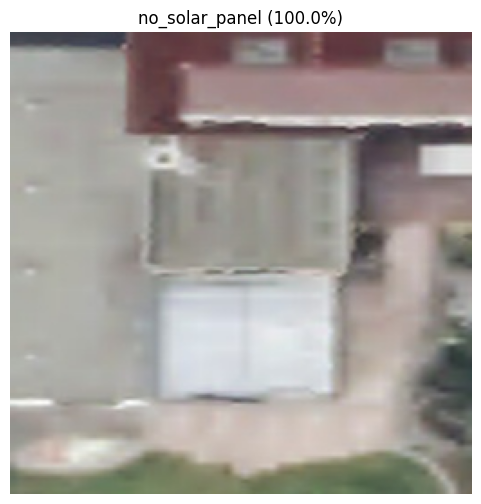


image 1/1 C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw\Gelsenkirchen\yolo_dataset_v2\val\no_solar_panel\no_pv_000005.jpg: 256x256 no_solar_panel 1.00, solar_panel 0.00, 23.6ms
Speed: 2.1ms preprocess, 23.6ms inference, 0.2ms postprocess per image at shape (1, 3, 256, 256)
Image : no_pv_000005.jpg
  no_solar_panel       : 1.0000 (100.0%)
  solar_panel          : 0.0000 (0.0%)
  → Prédiction : no_solar_panel (100.0%)


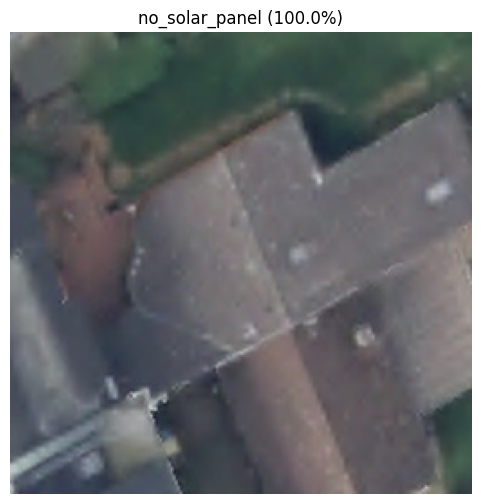


image 1/1 C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw\Gelsenkirchen\yolo_dataset_v2\val\no_solar_panel\no_pv_000007.jpg: 256x256 no_solar_panel 1.00, solar_panel 0.00, 17.4ms
Speed: 1.5ms preprocess, 17.4ms inference, 0.2ms postprocess per image at shape (1, 3, 256, 256)
Image : no_pv_000007.jpg
  no_solar_panel       : 0.9988 (99.9%)
  solar_panel          : 0.0012 (0.1%)
  → Prédiction : no_solar_panel (99.9%)


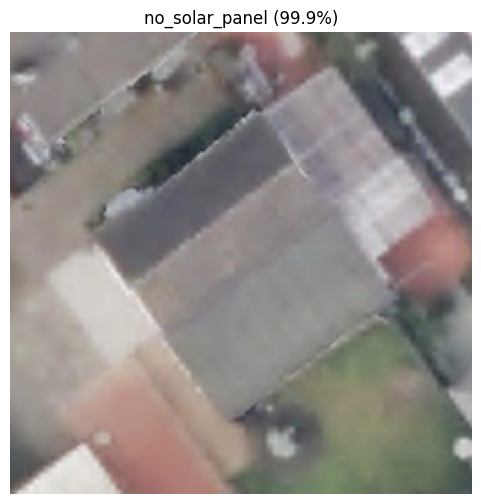


Classe : solar_panel

image 1/1 C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw\Gelsenkirchen\yolo_dataset_v2\val\solar_panel\no_pv_000037.jpg: 256x256 solar_panel 1.00, no_solar_panel 0.00, 14.3ms
Speed: 1.7ms preprocess, 14.3ms inference, 0.2ms postprocess per image at shape (1, 3, 256, 256)
Image : no_pv_000037.jpg
  no_solar_panel       : 0.0000 (0.0%)
  solar_panel          : 1.0000 (100.0%)
  → Prédiction : solar_panel (100.0%)


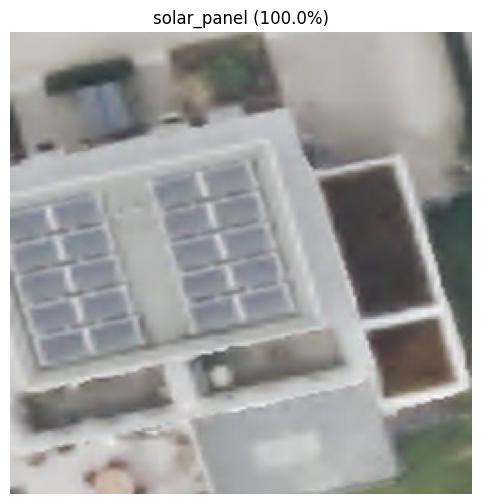


image 1/1 C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw\Gelsenkirchen\yolo_dataset_v2\val\solar_panel\no_pv_000048.jpg: 256x256 solar_panel 1.00, no_solar_panel 0.00, 15.2ms
Speed: 1.6ms preprocess, 15.2ms inference, 0.2ms postprocess per image at shape (1, 3, 256, 256)
Image : no_pv_000048.jpg
  no_solar_panel       : 0.0002 (0.0%)
  solar_panel          : 0.9998 (100.0%)
  → Prédiction : solar_panel (100.0%)


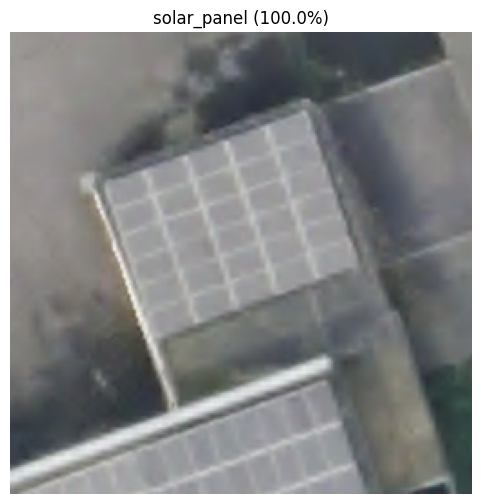


image 1/1 C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw\Gelsenkirchen\yolo_dataset_v2\val\solar_panel\no_pv_000050.jpg: 256x256 solar_panel 1.00, no_solar_panel 0.00, 17.7ms
Speed: 1.9ms preprocess, 17.7ms inference, 0.2ms postprocess per image at shape (1, 3, 256, 256)
Image : no_pv_000050.jpg
  no_solar_panel       : 0.0000 (0.0%)
  solar_panel          : 1.0000 (100.0%)
  → Prédiction : solar_panel (100.0%)


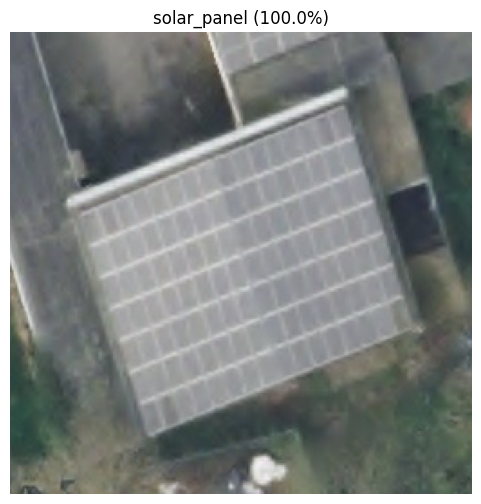


RÉSULTAT GLOBAL
  Accuracy : 193/200 (96.5%)
  Confiance moyenne : 99.0%
  no_solar_panel       : 156/158 (98.7%)
  solar_panel          : 37/42 (88.1%)

  Erreurs :
    Vrai=no_solar_panel, Prédit=solar_panel (confiance=99.8%)
    Vrai=no_solar_panel, Prédit=solar_panel (confiance=100.0%)
    Vrai=solar_panel, Prédit=no_solar_panel (confiance=100.0%)
    Vrai=solar_panel, Prédit=no_solar_panel (confiance=74.0%)
    Vrai=solar_panel, Prédit=no_solar_panel (confiance=100.0%)
    Vrai=solar_panel, Prédit=no_solar_panel (confiance=100.0%)
    Vrai=solar_panel, Prédit=no_solar_panel (confiance=94.1%)
Bâtiment : Hertener Straße 36a
Image : temp_test.jpg
  no_solar_panel       : 1.0000 (100.0%)
  solar_panel          : 0.0000 (0.0%)
  → Prédiction : no_solar_panel (100.0%)


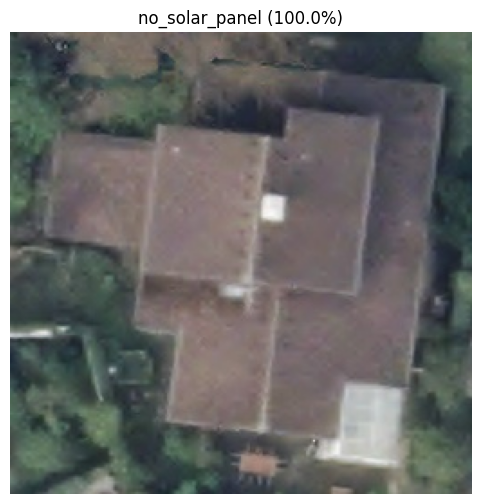

('no_solar_panel', 1.0)

In [ ]:
# =============================================================================
# TEST DU MODÈLE YOLO SUR DES IMAGES
# =============================================================================

# Charger le meilleur modèle
model_path = r"C:\Users\alexandre.batisse\.vscode\Projet\Projet_Stage_Scalian\runs\classify\solar_detection\yolo_pv-5\weights\best.pt"
model = YOLO(model_path)

# ── Test sur une seule image ─────────────────────────────────
def test_single_image(image_path: str):
    """Teste le modèle sur une image et affiche le résultat."""
    results = model(image_path)
    result = results[0]
    
    # Récupérer les probabilités
    probs = result.probs
    class_names = result.names
    
    print(f"Image : {os.path.basename(image_path)}")
    for i, (name, prob) in enumerate(zip(class_names.values(), probs.data)):
        print(f"  {name:20s} : {prob:.4f} ({prob*100:.1f}%)")
    
    predicted_class = class_names[probs.top1]
    confidence = probs.top1conf.item()
    print(f"  → Prédiction : {predicted_class} ({confidence*100:.1f}%)")
    
    # Afficher l'image
    img = Image.open(image_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"{predicted_class} ({confidence*100:.1f}%)")
    plt.axis('off')
    plt.show()
    
    return predicted_class, confidence

# Tester sur quelques images du dossier val
val_dir = os.path.join(DATA_ROOT, city_name, "yolo_dataset_v2", "val")
for cls_dir in os.listdir(val_dir):
    cls_path = os.path.join(val_dir, cls_dir)
    if os.path.isdir(cls_path):
        images = os.listdir(cls_path)[:3]
        print(f"\n{'='*50}")
        print(f"Classe : {cls_dir}")
        print(f"{'='*50}")
        for img_name in images:
            test_single_image(os.path.join(cls_path, img_name))


# ── Test batch sur toutes les images de validation ────────────
def test_batch(model, val_dir: str):
    """Teste le modèle sur tout le set de validation avec matrice de confusion."""
    y_true = []
    y_pred = []
    confidences = []
    
    for cls_name in sorted(os.listdir(val_dir)):
        cls_path = os.path.join(val_dir, cls_name)
        if not os.path.isdir(cls_path):
            continue
        
        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)
            results = model(img_path, verbose=False)
            
            pred_class = results[0].names[results[0].probs.top1]
            conf = results[0].probs.top1conf.item()
            
            y_true.append(cls_name)
            y_pred.append(pred_class)
            confidences.append(conf)
    
    # Résumé
    correct = sum(1 for t, p in zip(y_true, y_pred) if t == p)
    total = len(y_true)
    print(f"\n{'='*50}")
    print(f"RÉSULTAT GLOBAL")
    print(f"{'='*50}")
    print(f"  Accuracy : {correct}/{total} ({correct/total*100:.1f}%)")
    print(f"  Confiance moyenne : {np.mean(confidences)*100:.1f}%")
    
    # Par classe
    for cls in sorted(set(y_true)):
        cls_mask = [i for i, t in enumerate(y_true) if t == cls]
        cls_correct = sum(1 for i in cls_mask if y_pred[i] == cls)
        print(f"  {cls:20s} : {cls_correct}/{len(cls_mask)} ({cls_correct/len(cls_mask)*100:.1f}%)")
    
    # Erreurs
    print(f"\n  Erreurs :")
    for i, (t, p, c) in enumerate(zip(y_true, y_pred, confidences)):
        if t != p:
            print(f"    Vrai={t}, Prédit={p} (confiance={c*100:.1f}%)")

test_batch(model, val_dir)


# ── Test sur une nouvelle image quelconque ────────────────────
# Pour tester sur un bâtiment spécifique non vu pendant l'entraînement
def test_new_building(building_idx: int, df: pd.DataFrame, ortho_folder: str):
    """Extrait l'image d'un bâtiment et lance la prédiction YOLO."""
    row = df.iloc[building_idx]
    
    # Extraire l'image temporaire
    geom = wkt.loads(row['geometry'])
    bounds = geom.bounds
    
    if bounds[0] < 100:
        transformer = Transformer.from_crs("EPSG:4326", "EPSG:25832", always_xy=True)
        minx, miny = transformer.transform(bounds[0], bounds[1])
        maxx, maxy = transformer.transform(bounds[2], bounds[3])
    else:
        minx, miny, maxx, maxy = bounds
    
    minx -= 2
    miny -= 2
    maxx += 2
    maxy += 2
    
    cx = (minx + maxx) / 2
    cy = (miny + maxy) / 2
    
    jp2_files = [f for f in os.listdir(ortho_folder) if f.endswith('.jp2')]
    for f in jp2_files:
        path = os.path.join(ortho_folder, f)
        with rasterio.open(path) as src:
            b = src.bounds
            if b.left <= cx <= b.right and b.bottom <= cy <= b.top:
                window = from_bounds(minx, miny, maxx, maxy, src.transform)
                data = src.read([1, 2, 3], window=window)
                img = np.transpose(data, (1, 2, 0))
                pil_img = Image.fromarray(img.astype(np.uint8))
                pil_img = pil_img.resize((256, 256), Image.LANCZOS)
                
                # Sauvegarder temporairement
                temp_path = "temp_test.jpg"
                pil_img.save(temp_path, quality=95)
                
                # Prédire
                street = row.get('street', '?')
                print(f"Bâtiment : {street}")
                pred, conf = test_single_image(temp_path)
                
                os.remove(temp_path)
                return pred, conf
    
    print("❌ Aucune orthophoto trouvée")
    return None, None

# Tester sur le bâtiment 1000 par exemple
test_new_building(1000, df_individual, ortho_folder)

# ═══════════════════════════════════════════════════════════════
#  PARTIE 4 — LLM PIPELINE
# ═══════════════════════════════════════════════════════════════

## 4.1 — LLM Provider Configuration

In [ ]:
# =============================================================================
# PHASE 2 — PRÉDICTION LLM 
# =============================================================================
load_dotenv()


# ── CONFIGURATION DU MODÈLE ─────────────────────────────────
  # True = Ollama local, False = API Mistral
# ── CONFIGURATION DU MODÈLE ─────────────────────────────────
LLM_PROVIDER = "claude"  # "mistral", "groq", "gemini", "local"

if LLM_PROVIDER == "mistral":
    from langchain_mistralai import ChatMistralAI
    llm = ChatMistralAI(model="mistral-medium-latest", 
                        temperature=0.0, 
                        api_key=os.getenv("MISTRAL_API_KEY"))

if LLM_PROVIDER == "groq":
    from langchain_groq import ChatGroq
    llm = ChatGroq(
    model="llama-3.1-8b-instant",  # ou "mixtral-8x7b-32768"
    temperature=0.0,
    api_key=os.getenv("GROQ_API_KEY"))

if LLM_PROVIDER == "gemini":
    from langchain_google_genai import ChatGoogleGenerativeAI
    llm = ChatGoogleGenerativeAI(
        model="gemini-2.0-flash",
        temperature=0.0,
        api_key=os.getenv("GEMINI_API_KEY"))

if LLM_PROVIDER == "local phi":
    from langchain_ollama import ChatOllama
    llm = ChatOllama(model="phi4-mini", temperature=0.0, num_ctx=4096)

if LLM_PROVIDER == "local mistral" :
    from langchain_ollama import ChatOllama
    llm = ChatOllama(model="mistral", temperature=0.0, num_ctx=4096)

if LLM_PROVIDER == "local gemma" :
    from langchain_ollama import ChatOllama
    llm = ChatOllama(model="gemma2:9b", temperature=0.0, num_ctx=4096)

if LLM_PROVIDER == "claude" :
    from langchain_anthropic import ChatAnthropic
    llm = ChatAnthropic(model="claude-2", temperature=0.0, api_key=os.getenv("CLAUDE_API_KEY"))

print(f"✓ Modèle : {LLM_PROVIDER}")


✓ Modèle : claude


## 4.2 — Profile Extraction from JSON

In [35]:
def extract_json_from_response(raw: str) -> dict:
    """
    Extrait un objet JSON d'une réponse LLM, même si le modèle
    ajoute du texte explicatif autour.
    """
    raw = raw.strip()
    
    # Cas 1 : réponse propre qui commence par {
    if raw.startswith('{'):
        try:
            return json.loads(raw)
        except json.JSONDecodeError:
            pass
    
    # Cas 2 : JSON dans des backticks markdown
    md_match = re.search(r'```(?:json)?\s*(\{.*?\})\s*```', raw, re.DOTALL)
    if md_match:
        try:
            return json.loads(md_match.group(1))
        except json.JSONDecodeError:
            pass
    
    # Cas 3 : trouver le premier { ... } dans le texte
    brace_match = re.search(r'\{[^{}]*\}', raw)
    if brace_match:
        try:
            return json.loads(brace_match.group(0))
        except json.JSONDecodeError:
            pass
    
    # Cas 4 : JSON imbriqué (pour les cas avec des nested braces)
    deep_match = re.search(r'\{.*\}', raw, re.DOTALL)
    if deep_match:
        candidate = deep_match.group(0)
        # Nettoyer les retours à la ligne dans les valeurs
        candidate = re.sub(r'\n\s*', ' ', candidate)
        try:
            return json.loads(candidate)
        except json.JSONDecodeError:
            pass
    
    # Cas 5 : extraire les valeurs manuellement par regex
    result = {}
    
    # Chercher des patterns comme "building_type": "MFH" ou building_type : MFH
    for key in ['building_type', 'type_of_use', 'construction_year_class',
                'initial_heating_system', 'renovation_state',
                'number_of_apartments_min', 'number_of_apartments_max',
                'heated_space', 'initial_heat_demand']:
        # Pattern avec guillemets
        pattern = rf'["\']?{key}["\']?\s*[:=]\s*["\']?([^"\',\n\}}]+)["\']?'
        match = re.search(pattern, raw, re.IGNORECASE)
        if match:
            val = match.group(1).strip().rstrip(',').strip('"\'')
            # Essayer de convertir en nombre si possible
            try:
                val = int(val)
            except ValueError:
                try:
                    val = float(val)
                except ValueError:
                    pass
            result[key] = val
    
    if result:
        return result
    
    print(f"    ⚠️ Impossible d'extraire du JSON : {raw[:150]}")
    return {}

## 4.3 — Few-Shot Examples from Digital Twin

In [36]:
# Colonnes du dataset utilisées pour le few-shot
FEATURE_COLS_ALL = [
    'building_type', 'type_of_use', 'construction_year_class',
    'floor_area', 'heated_space', 'initial_heat_demand',
    'initial_heating_system', 'renovation_state',
    'number_of_apartments_min', 'number_of_apartments_max',
    'construction_year', 'solar_potential'
]

def select_training_examples(df: pd.DataFrame, n: int = 8, seed: int = 42) -> pd.DataFrame:
    np.random.seed(seed)
    
    examples = []
    
    # D'abord, garantir au moins 2 exemples par building_type
    for bt, group in df.groupby('building_type'):
        n_take = min(1, len(group))
        examples.append(group.sample(n=n_take, random_state=seed))
    
    # Ensuite, garantir au moins 1 exemple par construction_year_class
    base = pd.concat(examples)
    for cyc, group in df.groupby('construction_year_class'):
        if cyc not in base['construction_year_class'].values:
            examples.append(group.sample(n=1, random_state=seed))
    
    base = pd.concat(examples).drop_duplicates()
    
    # Compléter jusqu'à n
    remaining = df.loc[df.index.difference(base.index)]
    n_extra = n - len(base)
    if n_extra > 0 and len(remaining) > 0:
        extra = remaining.sample(n=min(n_extra, len(remaining)), random_state=seed)
        base = pd.concat([base, extra])
    
    result = base.head(n)
    
    print(f"✓ {len(result)} exemples sélectionnés")
    print(f"  Couverture building_type : {sorted(result['building_type'].unique())}")
    print(f"  Couverture construction_year_class : {sorted(result['construction_year_class'].unique())}")
    print(f"  Répartition building_type :")
    for bt, count in result['building_type'].value_counts().items():
        print(f"    {bt}: {count}")
    
    return result

training_examples = select_training_examples(df_individual, n=8)

✓ 8 exemples sélectionnés
  Couverture building_type : ['EFH', 'GHD', 'GMH', 'HH', 'Industrie', 'MFH', 'RH', 'Öffentlich']
  Couverture construction_year_class : ['1919 - 1948', '1949 - 1978', '1987 - 1990', '2012 - 2023']
  Répartition building_type :
    EFH: 1
    GHD: 1
    GMH: 1
    HH: 1
    Industrie: 1
    MFH: 1
    RH: 1
    Öffentlich: 1


## 4.4 — Dynamic Prompt Generation

In [37]:
# =============================================================================
# GÉNÉRATION DYNAMIQUE DES PROMPTS
# =============================================================================

# def build_conso_table(config: dict) -> str:
#     lines = ["| Classe | not_renovated | partially_renovated | renovated |"]
#     lines.append("|--------|--------------|-------------------|-----------|")
#     for classe, vals in config['tabula_specific_hd'].items():
#         lines.append(f"| {classe} | {vals.get('not_renovated', '?')} | {vals.get('partially_renovated', '?')} | {vals.get('renovated', '?')} |")
#     return "\n".join(lines)


# def build_heating_rules(config: dict) -> str:
#     lines = []
#     for bt, dist in config.get("heating_distribution", {}).items():
#         if dist:
#             parts = [f"{sys}: {pct}%" for sys, pct in sorted(dist.items(), key=lambda x: -x[1])]
#             lines.append(f"- {bt} → {', '.join(parts)}")
#     return "\n".join(lines)


# def build_hs_fa_rules(config: dict) -> str:
#     lines = []
#     for bt, ratio in config.get("hs_fa_ratio", {}).items():
#         if ratio > 0:
#             lines.append(f"- {bt}: heated_space ≈ floor_area × {ratio}")
#     return "\n".join(lines)


# def build_building_type_rules(stats: dict) -> str:
#     """Génère les règles de classification data-driven à partir de BUILDING_STATS."""
#     lines = []
#     for bt, s in sorted(stats.items()):
#         fa = s.get('floor_area', {})
#         hs = s.get('heated_space', {})
#         count = s.get('count', 0)
#         share = s.get('share_pct', 0)
#         apt = s.get('apartments', {})      
#         ratio = s.get('ratio_hs_fa', {})
        
#         if not fa:
#             continue
        
#         line = f"{bt} ({share}% of the dataset, {count} buildings) :\n"
#         line += f"  - commun floor_area : {fa.get('p25', '?')} — {fa.get('p75', '?')} m² (médian {fa.get('median', '?')}m²)\n"
#         line += f"  - extreme floor_area : {fa.get('min', '?')} — {fa.get('max', '?')} m²"
        
#         if hs:
#             line += f"\n  - commun heated_space : {hs.get('p25', '?')} — {hs.get('p75', '?')} m² (médian {hs.get('median', '?')}m²)"
        
#         if apt:
#             line += f"\n  - apartments : {apt.get('median_min', '?')} — {apt.get('median_max', '?')}"

#         if ratio:
#             line += f"\n  - ratio commun floors (HS/FA) : {ratio.get('p25', '?')} — {ratio.get('p75', '?')} (médian {ratio.get('median', '?')})"

#         lines.append(line)
    
#     return "\n\n".join(lines)


def generate_prompts(city_config: dict) -> tuple[str, str, str]:
    """
    Génère les 3 system prompts dynamiquement à partir des configs.
    Retourne (prompt_level1, prompt_level2, prompt_level3).
    """
    city = city_config.get("city_name", "Unknown")
    # bt_rules = build_building_type_rules(building_stats)
    # heating_rules = build_heating_rules(city_config)
    # conso_table = build_conso_table(TABULA_SPECIFIC_HD)
    # hs_fa_rules = build_hs_fa_rules(city_config)
    
    # Liste des systèmes de chauffage
    # all_systems = city_config.get('all_heating_systems', [])
    # residential_systems = [s for s in all_systems if not s.startswith('Industrie')]
    # industrial_systems = [s for s in all_systems if s.startswith('Industrie')]

    # ── LEVEL 3 ────────────────────────────────────────────────
    prompt_l3 = f"""You are an expert on building energy performance in {city}.

Predict initial_heat_demand in kWh/year (TOTAL annual heat demand).

TABULA/IWU reference specific consumptions vary by building type, construction period, and renovation state.
The TABULA value will be provided for each building. Use it as a baseline but adjust ±30% based on the building context.

Factors that increase consumption: old building, poor insulation, oil/gas heating, large heated space.
Factors that decrease consumption: recent construction, renovated, heat pump, well-insulated.

RESPOND ONLY with this JSON, nothing else:
{{"initial_heat_demand": X.XX}}"""

    return prompt_l3

# Générer les prompts dynamiques
SYSTEM_PROMPT_LEVEL3 = generate_prompts(
    CITY_CONFIG
)
CITY_CENTER = (CITY_CONFIG.get("center_lat", 0), CITY_CONFIG.get("center_lon", 0))

print(f"\n✓ Pipeline prête pour {CITY_CONFIG.get('city_name', 'Unknown')}")

print(f"  Prompt L3 : {(SYSTEM_PROMPT_LEVEL3)}")



✓ Pipeline prête pour Gelsenkirchen
  Prompt L3 : You are an expert on building energy performance in Gelsenkirchen.

Predict initial_heat_demand in kWh/year (TOTAL annual heat demand).

TABULA/IWU reference specific consumptions vary by building type, construction period, and renovation state.
The TABULA value will be provided for each building. Use it as a baseline but adjust ±30% based on the building context.

Factors that increase consumption: old building, poor insulation, oil/gas heating, large heated space.
Factors that decrease consumption: recent construction, renovated, heat pump, well-insulated.

RESPOND ONLY with this JSON, nothing else:
{"initial_heat_demand": X.XX}


## 4.5 — LLM Prediction Launch

In [ ]:
def predict_ihd_llm_v2(profile: dict, ml_predictions: dict, 
                        training_examples: pd.DataFrame, city_config: dict) -> float:
    """
    Prédit IHD via LLM avec les prédictions ML comme input.
    Version améliorée — prompt enrichi avec contexte TABULA + exemples ciblés.
    """
    
    bt = ml_predictions.get('building_type', '')
    cyc = ml_predictions.get('construction_year_class', '')
    rs = ml_predictions.get('renovation_state', 'not_renovated')
    hs = ml_predictions.get('heated_space', 0)
    ihs = ml_predictions.get('initial_heating_system', '')
    footprint = profile.get('footprint', {})
    height = profile.get('height', {})
    fa = footprint.get('floor_area_m2', 0)
    
    # Calculer les fourchettes réelles depuis le dataset pour ce building_type
    same_bt = training_examples[training_examples['building_type'] == bt]
    if len(same_bt) > 10:
        specific_conso = same_bt['initial_heat_demand'] / same_bt['heated_space']
        p10 = specific_conso.quantile(0.1)
        p50 = specific_conso.quantile(0.5)
        p90 = specific_conso.quantile(0.9)
    else:
        p10, p50, p90 = 50, 100, 200

    # Consommation TABULA pour les 3 états de rénovation
    tabula_nr = get_tabula_specific_hd(bt, cyc, 'not_renovated', city_config) or 100
    tabula_pr = get_tabula_specific_hd(bt, cyc, 'partially_renovated', city_config) or 80
    tabula_r = get_tabula_specific_hd(bt, cyc, 'renovated', city_config) or 50
    tabula_current = get_tabula_specific_hd(bt, cyc, rs, city_config) or tabula_nr
    
    # Volume du bâtiment
    h = height.get('height_p90_m', height.get('height_m', 3.4)) if height else 3.4
    volume = fa * h if fa and h else 0
    
    system_prompt = f"""You are a German building energy expert. Predict the TOTAL annual heat demand (IHD) in kWh/year.

RULES:
1. IHD = heated_space × specific_consumption (kWh/m²/year)
2. For {bt} buildings in this dataset, the specific consumption ranges from {p10:.0f} to {p90:.0f} kWh/m²/year (median: {p50:.0f})
3. TABULA reference for {rs}: {tabula_current} kWh/m²/year — this is a theoretical value, real values can differ significantly

KEY FACTORS for specific consumption:
- Renovation state is the STRONGEST factor:
  not_renovated → typically {tabula_nr:.0f} kWh/m²/year
  partially_renovated → typically {tabula_pr:.0f} kWh/m²/year
  renovated → typically {tabula_r:.0f} kWh/m²/year
- Heating system matters: Nachtspeicher/GEH = higher, el.WP = lower, Fernwärme = slightly lower
- Old buildings (pre-1978) with Ölkessel tend to have HIGHER consumption than TABULA suggests
- Recent buildings (post-2000) tend to match TABULA closely

IMPORTANT: Do NOT simply multiply heated_space × TABULA value. 
Look at the examples below and learn the REAL relationship between building characteristics and IHD.

RESPOND ONLY: {{"initial_heat_demand": X.XX}}"""

    # Few-shot — sélectionner des exemples du MÊME building_type
    same_type = training_examples[training_examples['building_type'] == bt]
    if len(same_type) < 5:
        same_type = training_examples
    sample = same_type.sample(n=min(8, len(same_type)), random_state=42)
    
    messages = [SystemMessage(content=system_prompt)]
    
    for _, row in sample.iterrows():
        user_msg = (
            f"building_type: {row['building_type']}, "
            f"construction_year_class: {row['construction_year_class']}, "
            f"renovation_state: {row['renovation_state']}, "
            f"heating_system: {row['initial_heating_system']}, "
            f"floor_area: {row['floor_area']:.1f}m², "
            f"heated_space: {row['heated_space']:.1f}m², "
            f"building_volume: {row['floor_area'] * 3.4:.0f}m³"
        )
        messages.append(HumanMessage(content=user_msg))
        messages.append(AIMessage(content=json.dumps({
            "initial_heat_demand": round(float(row['initial_heat_demand']), 1)
        })))
    
    # Message cible
    target_msg = (
        f"Target building:\n"
        f"  building_type: {bt}\n"
        f"  construction_year_class: {cyc}\n"
        f"  renovation_state: {rs}\n"
        f"  heating_system: {ihs}\n"
        f"  heated_space: {hs:.1f}m²\n"
        f"  floor_area: {fa}m²\n"
        f"  building_volume: {volume:.0f}m³\n"
        f"  floors: {height.get('estimated_floors', '?') if height else '?'}\n"
        f"  distance_center: {profile.get('spatial_context', {}).get('distance_center_km', '?')}km\n"
        f"\nBased on the examples and your expertise, what is the total IHD?"
        f'\n\nRESPOND ONLY: {{"initial_heat_demand": X.XX}}'
    )
    
    messages.append(HumanMessage(content=target_msg))
    
    start = time.time()
    response = llm.invoke(messages)
    elapsed = time.time() - start
    
    raw = response.content.strip()
    prediction = extract_json_from_response(raw)
    
    ihd = prediction.get('initial_heat_demand', None) if prediction else None
    
    if ihd is not None:
        try:
            ihd = float(ihd)
        except (ValueError, TypeError):
            print(f"  ⚠️ IHD non numérique ({ihd}) — fallback TABULA")
            ihd = hs * tabula_current
        
        if ihd < 200 or ihd > 2000000:
            print(f"  ⚠️ IHD aberrant ({ihd}) — fallback sur baseline TABULA")
            ihd = hs * tabula_current
    print(f"✓ IHD LLM v2 — {ihd:.0f} kWh ({elapsed:.1f}s)")
    return ihd

## 4.6 — Hybrid Test ML (XGBoost) + LLM (Mistral

In [39]:
ihd_llm = predict_ihd_llm_v2(profile, predictions_ml, training_examples, CITY_CONFIG)

✓ IHD LLM v2 — 4810 kWh (0.6s)


# ═══════════════════════════════════════════════════════════════
# PART 5 — SOLAR PANEL DETECTION (YOLO Pipeline)
# ═══════════════════════════════════════════════════════════════

## 5.1 — MaStR Data Download

In [ ]:
db = Mastr()
db.download(data=["solar"])  # Télécharge toutes les installations PV

KeyboardInterrupt: 

## 5.2 — MaStR Data Exploration

In [ ]:
# =============================================================================
# FILTRER LES INSTALLATIONS PV POUR NOS VILLES
# =============================================================================

db_path = os.path.expanduser("~/.open-MaStR/data/sqlite/open-mastr.db")
conn = sqlite3.connect(db_path)

# Lire les installations solaires avec les colonnes utiles
df_solar = pd.read_sql("""
    SELECT 
        EinheitMastrNummer,
        Gemeinde,
        Ort,
        Postleitzahl,
        Strasse,
        Hausnummer,
        Breitengrad,
        Laengengrad,
        Nettonennleistung,
        Bruttoleistung,
        Inbetriebnahmedatum,
        AnzahlModule,
        Lage,
        Hauptausrichtung,
        EinheitBetriebsstatus
    FROM solar_extended
    WHERE Gemeinde IS NOT NULL
""", conn)

print(f"Total installations PV en Allemagne : {len(df_solar)}")

# Filtrer par ville
cities = ['Gelsenkirchen', 'Düsseldorf', 'Bottrop', 'Gladbeck']

for city in cities:
    subset = df_solar[df_solar['Gemeinde'].str.contains(city, na=False, case=False)]
    print(f"  {city:20s} : {len(subset)} installations PV")

# Garder les installations de nos villes
df_pv = df_solar[df_solar['Gemeinde'].str.contains('|'.join(cities), na=False, case=False)].copy()
print(f"\nTotal pour nos villes : {len(df_pv)}")

# Explorer les données
print(f"\nColonnes avec coordonnées :")
print(f"  Breitengrad (lat) : {df_pv['Breitengrad'].notna().sum()}/{len(df_pv)} valeurs")
print(f"  Laengengrad (lon) : {df_pv['Laengengrad'].notna().sum()}/{len(df_pv)} valeurs")

print(f"\nPuissance (Nettonennleistung) :")
print(df_pv['Nettonennleistung'].describe())

print(f"\nExemples :")
print(df_pv[['Gemeinde', 'Strasse', 'Hausnummer', 'Breitengrad', 'Laengengrad', 'Nettonennleistung']].head(10).to_string())

conn.close()

Total installations PV en Allemagne : 6206925
  Gelsenkirchen        : 6044 installations PV
  Düsseldorf           : 11630 installations PV
  Bottrop              : 6023 installations PV
  Gladbeck             : 3183 installations PV

Total pour nos villes : 26880

Colonnes avec coordonnées :
  Breitengrad (lat) : 865/26880 valeurs
  Laengengrad (lon) : 865/26880 valeurs

Puissance (Nettonennleistung) :
count    26880.000000
mean        10.774176
std        108.818062
min          0.001000
25%          0.800000
50%          5.000000
75%          9.000000
max      15040.000000
Name: Nettonennleistung, dtype: float64

Exemples :
           Gemeinde     Strasse Hausnummer  Breitengrad  Laengengrad  Nettonennleistung
202        Gladbeck         NaN        NaN          NaN          NaN               4.20
322      Düsseldorf         NaN        NaN          NaN          NaN               2.94
500   Gelsenkirchen         NaN        NaN          NaN          NaN               3.00
527        G

In [17]:
# Analyser la complétude des données de localisation
print("COMPLÉTUDE DES DONNÉES DE LOCALISATION")
print("=" * 60)
print(f"  Coordonnées (lat/lon)  : {df_pv['Breitengrad'].notna().sum()}/{len(df_pv)} ({df_pv['Breitengrad'].notna().sum()/len(df_pv)*100:.1f}%)")
print(f"  Rue (Strasse)          : {df_pv['Strasse'].notna().sum()}/{len(df_pv)} ({df_pv['Strasse'].notna().sum()/len(df_pv)*100:.1f}%)")
print(f"  Numéro (Hausnummer)    : {df_pv['Hausnummer'].notna().sum()}/{len(df_pv)} ({df_pv['Hausnummer'].notna().sum()/len(df_pv)*100:.1f}%)")
print(f"  Code postal (PLZ)      : {df_pv['Postleitzahl'].notna().sum()}/{len(df_pv)} ({df_pv['Postleitzahl'].notna().sum()/len(df_pv)*100:.1f}%)")
print(f"  Ort                    : {df_pv['Ort'].notna().sum()}/{len(df_pv)} ({df_pv['Ort'].notna().sum()/len(df_pv)*100:.1f}%)")

# Combien ont au moins une adresse exploitable (rue + numéro)
has_address = df_pv['Strasse'].notna() & df_pv['Hausnummer'].notna()
print(f"\n  Adresse complète (rue+num) : {has_address.sum()}/{len(df_pv)} ({has_address.sum()/len(df_pv)*100:.1f}%)")

# Combien ont au moins un moyen de matching (adresse OU coordonnées)
has_any = has_address | df_pv['Breitengrad'].notna()
print(f"  Matchable (adresse OU GPS) : {has_any.sum()}/{len(df_pv)} ({has_any.sum()/len(df_pv)*100:.1f}%)")

# Par ville
print(f"\nPar ville :")
for city in cities:
    subset = df_pv[df_pv['Gemeinde'].str.contains(city, na=False)]
    addr = subset['Strasse'].notna() & subset['Hausnummer'].notna()
    gps = subset['Breitengrad'].notna()
    matchable = addr | gps
    print(f"  {city:15s} : {len(subset):5d} PV | adresse: {addr.sum():4d} | GPS: {gps.sum():3d} | matchable: {matchable.sum():4d} ({matchable.sum()/len(subset)*100:.0f}%)")

COMPLÉTUDE DES DONNÉES DE LOCALISATION
  Coordonnées (lat/lon)  : 865/26880 (3.2%)
  Rue (Strasse)          : 862/26880 (3.2%)
  Numéro (Hausnummer)    : 846/26880 (3.1%)
  Code postal (PLZ)      : 26880/26880 (100.0%)
  Ort                    : 26880/26880 (100.0%)

  Adresse complète (rue+num) : 846/26880 (3.1%)
  Matchable (adresse OU GPS) : 866/26880 (3.2%)

Par ville :
  Gelsenkirchen   :  6044 PV | adresse:  197 | GPS: 201 | matchable:  201 (3%)
  Düsseldorf      : 11630 PV | adresse:  354 | GPS: 363 | matchable:  364 (3%)
  Bottrop         :  6023 PV | adresse:  230 | GPS: 235 | matchable:  235 (4%)
  Gladbeck        :  3183 PV | adresse:   65 | GPS:  66 | matchable:   66 (2%)


## 5.3 — MaStR Address Matching

In [ ]:
# =============================================================================
# MATCHING PV MaStR ↔ BÂTIMENTS PAR ADRESSE
# =============================================================================

def normalize_street(s):
    if pd.isna(s) or not isinstance(s, str):
        return ''
    s = str(s).strip().lower()
    # Gérer les deux types d'encodage cassé
    s = s.replace('ãŸ', 'ss').replace('ã¤', 'ae').replace('ã¶', 'oe').replace('ã¼', 'ue')
    s = s.replace('ã©', 'e').replace('ã¨', 'e').replace('ã ', 'a')
    s = s.replace('ß', 'ss').replace('ä', 'ae').replace('ö', 'oe').replace('ü', 'ue')
    s = s.replace('str.', 'strasse').replace('str ', 'strasse ')
    s = s.replace('-', ' ').replace('.', '').strip()
    # Supprimer les espaces multiples
    s = ' '.join(s.split())
    return s

def normalize_hausnr(h):
    """Normalise un numéro de maison : '11 a' → '11a', '31-33' → '31'."""
    if pd.isna(h) or not isinstance(h, str):
        return ''
    h = str(h).strip().lower()
    h = h.replace(' ', '')  # '11 a' → '11a'
    h = h.split('-')[0]     # '31-33' → '31'
    return h

def match_pv_to_buildings(df_buildings: pd.DataFrame, df_pv_city: pd.DataFrame,
                           city_name: str) -> pd.DataFrame:
    """
    Associe les installations PV aux bâtiments par matching d'adresse.
    Stratégie : rue + numéro exact, puis fallback par coordonnées GPS (optimisé avec KDTree).
    """
    df = df_buildings.copy()
    df['pv_panel'] = False
    df['pv_power_kw'] = None
    df['pv_date'] = None
    df['pv_modules'] = None
    df['pv_match_method'] = None

    # Filtrer les PV matchables
    pv_with_address = df_pv_city[
        df_pv_city['Strasse'].notna() & df_pv_city['Hausnummer'].notna()
    ].copy()

    pv_with_gps = df_pv_city[
        df_pv_city['Breitengrad'].notna() & df_pv_city['Laengengrad'].notna()
    ].copy()

    print(f"Matching PV pour {city_name}")
    print(f"  PV avec adresse : {len(pv_with_address)}")
    print(f"  PV avec GPS     : {len(pv_with_gps)}")
    print(f"  Bâtiments       : {len(df)}")

    # ── Méthode 1 : Matching par adresse (inchangé) ───────────────────────
    pv_with_address['_street_norm'] = pv_with_address['Strasse'].apply(normalize_street)
    pv_with_address['_hausnr'] = pv_with_address['Hausnummer'].apply(normalize_hausnr)

    if 'street' in df.columns:
        df['_street_parts'] = df['street'].apply(lambda s: str(s).strip() if pd.notna(s) else '')
        df['_hausnr'] = df['_street_parts'].str.extract(r'(\d+\w*)$', expand=False).apply(normalize_hausnr)
        df['_street_name'] = df['_street_parts'].str.replace(r'\s*\d+\w*$', '', regex=True)
        df['_street_norm'] = df['_street_name'].apply(normalize_street)

    matched_by_address = 0

    for _, pv_row in pv_with_address.iterrows():
        pv_street = pv_row['_street_norm']
        pv_hausnr = pv_row['_hausnr']

        if not pv_street or not pv_hausnr:
            continue

        mask = (df['_street_norm'] == pv_street) & (df['_hausnr'] == pv_hausnr)
        matches = df[mask]

        if len(matches) == 0:
            mask = df['_street_norm'].str.contains(pv_street, na=False) & (df['_hausnr'] == pv_hausnr)
            matches = df[mask]

        if len(matches) > 0:
            idx = matches.index[0]
            power = float(pv_row['Nettonennleistung']) if pd.notna(pv_row['Nettonennleistung']) else 0
            if df.loc[idx, 'pv_panel']:
                current_power = df.loc[idx, 'pv_power_kw'] or 0
                df.loc[idx, 'pv_power_kw'] = current_power + power
            else:
                df.loc[idx, 'pv_panel'] = True
                df.loc[idx, 'pv_power_kw'] = power
                df.loc[idx, 'pv_date'] = pv_row.get('Inbetriebnahmedatum', None)
                df.loc[idx, 'pv_modules'] = int(pv_row['AnzahlModule']) if pd.notna(pv_row.get('AnzahlModule')) else None
                df.loc[idx, 'pv_match_method'] = 'address'
                matched_by_address += 1

    print(f"  ✓ Matchés par adresse : {matched_by_address}")

    # ── Méthode 2 : Matching par GPS (OPTIMISÉ) ───────────────
    matched_by_gps = 0

    if len(pv_with_gps) > 0 and 'geometry' in df.columns:

        transformer = Transformer.from_crs('EPSG:4326', 'EPSG:25832', always_xy=True)

        # Préparer les coordonnées des bâtiments
        building_coords = []
        building_indices = []

        for idx, row in df.iterrows():
            if pd.isna(row['geometry']):
                continue
            try:
                geom = wkt.loads(row['geometry'])
                c = geom.centroid
                # Convertir en UTM si coordonnées en degrés
                if c.x < 100:  # Longitude < 100 → degrés
                    bx, by = transformer.transform(c.x, c.y)
                else:  # Déjà en UTM
                    bx, by = c.x, c.y
                building_coords.append((bx, by))
                building_indices.append(idx)
            except:
                continue

        # Créer le KDTree
        if building_coords:
            kdtree = KDTree(building_coords)
        else:
            print("  ⚠ Aucun bâtiment avec géométrie valide pour le matching GPS")
            kdtree = None

        if kdtree is not None:
            for _, pv_row in pv_with_gps.iterrows():
                try:
                    pv_x, pv_y = transformer.transform(
                        float(pv_row['Laengengrad']),
                        float(pv_row['Breitengrad'])
                    )
                    # Rechercher dans un rayon de 30m
                    dist, idx_in_tree = kdtree.query((pv_x, pv_y), k=1, distance_upper_bound=30)

                    if dist <= 30:
                        building_idx = building_indices[idx_in_tree]
                        # Vérifier si déjà matché par adresse
                        if df.loc[building_idx, 'pv_panel'] and df.loc[building_idx, 'pv_match_method'] == 'address':
                            continue

                        power = float(pv_row['Nettonennleistung']) if pd.notna(pv_row['Nettonennleistung']) else 0
                        if df.loc[building_idx, 'pv_panel']:
                            current_power = df.loc[building_idx, 'pv_power_kw'] or 0
                            df.loc[building_idx, 'pv_power_kw'] = current_power + power
                        else:
                            df.loc[building_idx, 'pv_panel'] = True
                            df.loc[building_idx, 'pv_power_kw'] = power
                            df.loc[building_idx, 'pv_date'] = pv_row.get('Inbetriebnahmedatum', None)
                            df.loc[building_idx, 'pv_modules'] = int(pv_row['AnzahlModule']) if pd.notna(pv_row.get('AnzahlModule')) else None
                            df.loc[building_idx, 'pv_match_method'] = 'gps'
                            matched_by_gps += 1
                except:
                    continue

        print(f"  ✓ Matchés par GPS     : {matched_by_gps}")

    # Nettoyage
    cols_to_drop = [c for c in df.columns if c.startswith('_')]
    df = df.drop(columns=cols_to_drop, errors='ignore')

    # Résumé
    total_pv = df['pv_panel'].sum()
    print(f"\n  RÉSULTAT FINAL — {city_name}")
    print(f"  Bâtiments avec PV : {total_pv}/{len(df)} ({total_pv/len(df)*100:.2f}%)")
    if total_pv > 0:
        print(f"  Puissance moyenne  : {df[df['pv_panel']]['pv_power_kw'].mean():.1f} kW")
        print(f"  Puissance médiane  : {df[df['pv_panel']]['pv_power_kw'].median():.1f} kW")
        print(f"  Par building_type  :")
        for bt in sorted(df['building_type'].unique()):
            bt_total = len(df[df['building_type'] == bt])
            bt_pv = df[(df['building_type'] == bt) & (df['pv_panel'])].shape[0]
            if bt_total > 0:
                print(f"    {bt:15s} : {bt_pv}/{bt_total} ({bt_pv/bt_total*100:.1f}%)")

    return df


conn = sqlite3.connect(os.path.expanduser("~/.open-MaStR/data/sqlite/open-mastr.db"))

df_pv_city = pd.read_sql(f"""
    SELECT 
        Gemeinde, Strasse, Hausnummer, Postleitzahl,
        Breitengrad, Laengengrad, Nettonennleistung,
        Inbetriebnahmedatum, AnzahlModule
    FROM solar_extended
    WHERE Gemeinde LIKE '%{city_name}%'
""", conn)

conn.close()


print(f"{city_name} : {len(df_pv_city)} installations PV dans MaStR")

df_individual = match_pv_to_buildings(df_individual, df_pv_city, city_name)

# Sauvegarder
enriched_path = os.path.join(DATA_ROOT, city_name, f"{city_name}_buildings_enriched_v2.csv")
df_individual.to_csv(enriched_path, index=False)
print(f"\n✓ Dataset sauvegardé : {enriched_path}")

Gelsenkirchen : 6044 installations PV dans MaStR
Matching PV pour Gelsenkirchen
  PV avec adresse : 197
  PV avec GPS     : 201
  Bâtiments       : 44339
  ✓ Matchés par adresse : 109
  ✓ Matchés par GPS     : 46

  RÉSULTAT FINAL — Gelsenkirchen
  Bâtiments avec PV : 155/44339 (0.35%)
  Puissance moyenne  : 146.7 kW
  Puissance médiane  : 74.0 kW
  Par building_type  :
    EFH             : 4/12983 (0.0%)
    GHD             : 56/3655 (1.5%)
    GMH             : 8/1319 (0.6%)
    HH              : 0/7 (0.0%)
    Industrie       : 21/1034 (2.0%)
    MFH             : 44/17906 (0.2%)
    RH              : 2/6424 (0.0%)
    Öffentlich      : 20/1011 (2.0%)

✓ Dataset sauvegardé : C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw\Gelsenkirchen\Gelsenkirchen_buildings_enriched_v2.csv


## 5.4 — Unmatched Buildings Verification

In [ ]:

# =============================================================================
# ANALYSE DES PV NON MATCHÉS
# =============================================================================

# 1. Charger les données matchées
df_matched = pd.read_csv(os.path.join(DATA_ROOT, city_name, f"{city_name}_buildings_enriched_v2.csv"))

# 2. Identifier les PV non matchés dans MaStR
#    (Ceux qui n'ont pas été associés à un bâtiment dans df_matched)

# Récupérer les indices des bâtiments avec PV
matched_building_indices = df_matched[df_matched['pv_panel']].index.tolist()

# Récupérer les adresses des bâtiments matchés par adresse
matched_addresses = set()
if 'street' in df_matched.columns:
    for idx in matched_building_indices:
        if df_matched.loc[idx, 'pv_match_method'] == 'address':
            street = df_matched.loc[idx, 'street']
            matched_addresses.add(str(street).strip().lower())

# Récupérer les coordonnées des bâtiments matchés par GPS
matched_coords = set()
for idx in matched_building_indices:
    if df_matched.loc[idx, 'pv_match_method'] == 'gps' and 'geometry' in df_matched.columns:
        try:
            geom = wkt.loads(df_matched.loc[idx, 'geometry'])
            c = geom.centroid
            matched_coords.add((round(c.x, 4), round(c.y, 4)))
        except:
            pass

# 3. Analyser les PV non matchés dans MaStR
unmatched_pv = []

for _, pv_row in df_pv_city.iterrows():
    # Vérifier si ce PV a été matché par adresse
    street = str(pv_row['Strasse']).strip().lower() if pd.notna(pv_row['Strasse']) else None
    hausnr = str(pv_row['Hausnummer']).strip().lower() if pd.notna(pv_row['Hausnummer']) else None

    matched_by_address = False
    if street and hausnr:
        # Vérifier si une adresse similaire existe dans les bâtiments matchés
        for matched_addr in matched_addresses:
            if street in matched_addr or matched_addr in street:
                matched_by_address = True
                break

    # Vérifier si ce PV a été matché par GPS
    matched_by_gps = False
    if pd.notna(pv_row['Breitengrad']) and pd.notna(pv_row['Laengengrad']):
        coord = (round(float(pv_row['Laengengrad']), 4), round(float(pv_row['Breitengrad']), 4))
        if coord in matched_coords:
            matched_by_gps = True

    # Si non matché par aucune méthode
    if not matched_by_address and not matched_by_gps:
        unmatched_pv.append({
            **pv_row.to_dict(),
            'reason': 'non_matched',
            'street_normalized': normalize_street(pv_row['Strasse']) if pd.notna(pv_row['Strasse']) else None,
            'hausnr_normalized': str(pv_row['Hausnummer']).strip().lower() if pd.notna(pv_row['Hausnummer']) else None
        })

# Convertir en DataFrame
df_unmatched_pv = pd.DataFrame(unmatched_pv)

print(f"\n{'='*60}")
print(f"ANALYSE DES PV NON MATCHÉS — {city_name}")
print(f"{'='*60}")
print(f"Total PV dans MaStR : {len(df_pv_city)}")
print(f"PV matchés           : {len(df_pv_city) - len(df_unmatched_pv)}")
print(f"PV NON matchés      : {len(df_unmatched_pv)} ({len(df_unmatched_pv)/len(df_pv_city)*100:.1f}%)")

# =============================================================================
# CATEGORISER LES PV NON MATCHÉS
# =============================================================================

# 1. PV avec adresse mais pas de matching
unmatched_with_address = df_unmatched_pv[
    df_unmatched_pv['Strasse'].notna() & df_unmatched_pv['Hausnummer'].notna()
].copy()
unmatched_with_address['category'] = 'adresse_mais_pas_de_matching'

# 2. PV avec GPS mais pas de matching
unmatched_with_gps = df_unmatched_pv[
    df_unmatched_pv['Breitengrad'].notna() & df_unmatched_pv['Laengengrad'].notna()
].copy()
unmatched_with_gps['category'] = 'gps_mais_pas_de_matching'

# 3. PV sans adresse ni GPS
unmatched_no_data = df_unmatched_pv[
    (df_unmatched_pv['Strasse'].isna() | df_unmatched_pv['Hausnummer'].isna()) &
    (df_unmatched_pv['Breitengrad'].isna() | df_unmatched_pv['Laengengrad'].isna())
].copy()
unmatched_no_data['category'] = 'pas_d_adresse_ni_gps'

# 4. PV avec adresse ET GPS mais pas de matching
unmatched_both = df_unmatched_pv[
    (df_unmatched_pv['Strasse'].notna() & df_unmatched_pv['Hausnummer'].notna()) &
    (df_unmatched_pv['Breitengrad'].notna() & df_unmatched_pv['Laengengrad'].notna())
].copy()
unmatched_both['category'] = 'adresse_et_gps_mais_pas_de_matching'

print(f"\nRépartition des PV non matchés :")
print(f"  Avec adresse mais pas de matching    : {len(unmatched_with_address)}")
print(f"  Avec GPS mais pas de matching          : {len(unmatched_with_gps)}")
print(f"  Sans adresse ni GPS                  : {len(unmatched_no_data)}")
print(f"  Avec adresse ET GPS mais pas de matching : {len(unmatched_both)}")

# =============================================================================
# VISUALISER LES PV NON MATCHÉS (ÉCHANTILLON)
# =============================================================================

def display_unmatched_pv_sample(df, n=5):
    """Affiche un échantillon des PV non matchés avec leurs détails."""
    if len(df) == 0:
        print("  Aucun PV dans cette catégorie.")
        return

    sample = df.head(n)
    display(HTML(f"<h4>Échantillon de {len(df)} PV non matchés ({sample['category'].iloc[0]})</h4>"))

    # Afficher les colonnes importantes
    display_columns = [
        'Strasse', 'Hausnummer', 'Postleitzahl',
        'Breitengrad', 'Laengengrad',
        'Nettonennleistung', 'Inbetriebnahmedatum',
        'street_normalized', 'hausnr_normalized'
    ]
    available_columns = [col for col in display_columns if col in sample.columns]
    display(sample[available_columns])

# Afficher des échantillons de chaque catégorie
print(f"\n{'='*60}")
print("ÉCHANTILLONS DE PV NON MATCHÉS")
print(f"{'='*60}")

display_unmatched_pv_sample(unmatched_with_address, 5)
print()
display_unmatched_pv_sample(unmatched_with_gps, 5)
print()
display_unmatched_pv_sample(unmatched_both, 5)

# =============================================================================
# VÉRIFIER SI LES ADRESSES EXISTENT DANS LE DIGITAL TWIN
# =============================================================================

print(f"\n{'='*60}")
print("VÉRIFICATION DES ADRESSES DANS LE DIGITAL TWIN")
print(f"{'='*60}")

# Pour les PV avec adresse mais non matchés
if len(unmatched_with_address) > 0:
    print(f"\nVérification des {len(unmatched_with_address)} PV avec adresse mais non matchés...")

    # Normaliser les adresses des bâtiments dans le digital twin
    if 'street' in df_matched.columns:
        df_matched['_street_norm_dt'] = df_matched['street'].apply(normalize_street)
        df_matched['_hausnr_dt'] = df_matched['street'].str.extract(r'(\d+\w*)$', expand=False).fillna('').str.lower()

        # Pour chaque PV non matché, vérifier s'il existe une adresse similaire dans le digital twin
        for _, pv_row in unmatched_with_address.iterrows():
            pv_street_norm = pv_row['street_normalized']
            pv_hausnr = pv_row['hausnr_normalized']

            if not pv_street_norm or not pv_hausnr:
                continue

            #Chercher des correspondances exactes ou partielles
            exact_matches = df_matched[
                (df_matched['_street_norm_dt'] == pv_street_norm) &
                (df_matched['_hausnr_dt'] == pv_hausnr)
            ]

            partial_matches = df_matched[
                (df_matched['_street_norm_dt'].str.contains(pv_street_norm, na=False)) &
                (df_matched['_hausnr_dt'] == pv_hausnr)
            ]

            if len(exact_matches) > 0:
                unmatched_with_address.at[_, 'dt_match_type'] = 'exact'
                unmatched_with_address.at[_, 'dt_match_count'] = len(exact_matches)
                unmatched_with_address.at[_, 'dt_match_indices'] = ','.join(map(str, exact_matches.index.tolist()))
            elif len(partial_matches) > 0:
                unmatched_with_address.at[_, 'dt_match_type'] = 'partial'
                unmatched_with_address.at[_, 'dt_match_count'] = len(partial_matches)
                unmatched_with_address.at[_, 'dt_match_indices'] = ','.join(map(str, partial_matches.index.tolist()))
            else:
                unmatched_with_address.at[_, 'dt_match_type'] = 'none'
                unmatched_with_address.at[_, 'dt_match_count'] = 0

        # Statistiques
        match_stats = unmatched_with_address['dt_match_type'].value_counts()
        print(f"  Correspondances dans le digital twin :")
        for match_type, count in match_stats.items():
            print(f"    {match_type:10s} : {count} ({count/len(unmatched_with_address)*100:.1f}%)")

        # Afficher les PV sans aucune correspondance dans le digital twin
        no_match_in_dt = unmatched_with_address[unmatched_with_address['dt_match_type'] == 'none']
        if len(no_match_in_dt) > 0:
            print(f"\n  {len(no_match_in_dt)} PV avec adresse mais AUCUNE correspondance dans le digital twin :")
            display(no_match_in_dt[['Strasse', 'Hausnummer', 'Postleitzahl', 'Nettonennleistung']].head())

# =============================================================================
# GÉNÉRER UN FICHIER POUR VÉRIFICATION MANUELLE (GOOGLE MAPS)
# =============================================================================

print(f"\n{'='*60}")
print("GÉNÉRATION D'UN FICHIER POUR VÉRIFICATION MANUELLE")
print(f"{'='*60}")

# Créer un DataFrame pour vérification manuelle
verification_df = pd.DataFrame()

# Ajouter les PV non matchés avec adresse
if len(unmatched_with_address) > 0:
    addr_df = unmatched_with_address[['Strasse', 'Hausnummer', 'Postleitzahl', 'Breitengrad', 'Laengengrad']].copy()
    addr_df['source'] = 'adresse_non_matchée'
    addr_df['category'] = 'À vérifier: adresse existe mais pas de matching'
    verification_df = pd.concat([verification_df, addr_df], ignore_index=True)

# Ajouter les PV non matchés avec GPS
if len(unmatched_with_gps) > 0:
    gps_df = unmatched_with_gps[['Strasse', 'Hausnummer', 'Postleitzahl', 'Breitengrad', 'Laengengrad']].copy()
    gps_df['source'] = 'gps_non_matché'
    gps_df['category'] = 'À vérifier: GPS existe mais pas de matching'
    verification_df = pd.concat([verification_df, gps_df], ignore_index=True)

# Ajouter les PV avec adresse ET GPS non matchés
if len(unmatched_both) > 0:
    both_df = unmatched_both[['Strasse', 'Hausnummer', 'Postleitzahl', 'Breitengrad', 'Laengengrad']].copy()
    both_df['source'] = 'adresse_et_gps_non_matchés'
    both_df['category'] = 'À vérifier: adresse ET GPS existent mais pas de matching'
    verification_df = pd.concat([verification_df, both_df], ignore_index=True)

# Sauvegarder le fichier de vérification
if len(verification_df) > 0:
    verification_path = os.path.join(DATA_ROOT, city_name, f"{city_name}_pv_unmatched_for_verification.csv")
    verification_df.to_csv(verification_path, index=False)
    print(f"✓ Fichier de vérification sauvegardé : {verification_path}")
    print(f"  Contient {len(verification_df)} PV à vérifier manuellement.")

    # Afficher un extrait
    print(f"\n  Exemple de PV à vérifier :")
    display(verification_df.head())
else:
    print("  Aucun PV non matché à vérifier.")

# =============================================================================
# ANALYSE DES ERREURS DE MATCHING POTENTIELLES
# =============================================================================

print(f"\n{'='*60}")
print("ANALYSE DES ERREURS DE MATCHING POTENTIELLES")
print(f"{'='*60}")

# 1. Vérifier les PV avec adresse et GPS non matchés
if len(unmatched_both) > 0:
    print(f"\nAnalyse des {len(unmatched_both)} PV avec adresse ET GPS mais non matchés...")

    # Pour chaque PV, vérifier s'il existe un bâtiment proche (mais pas assez proche pour le matching)
    transformer = Transformer.from_crs('EPSG:4326', 'EPSG:25832', always_xy=True)

    # Préparer les coordonnées des bâtiments
    building_coords = []
    building_indices = []
    for idx, row in df_matched.iterrows():
        if pd.isna(row['geometry']):
            continue
        try:
            geom = wkt.loads(row['geometry'])
            c = geom.centroid
            if c.x < 100:  # Coordonnées en degrés
                bx, by = transformer.transform(c.x, c.y)
            else:
                bx, by = c.x, c.y
            building_coords.append((bx, by))
            building_indices.append(idx)
        except:
            continue

    if building_coords:
        kdtree = KDTree(building_coords)

        for _, pv_row in unmatched_both.iterrows():
            try:
                pv_x, pv_y = transformer.transform(
                    float(pv_row['Laengengrad']),
                    float(pv_row['Breitengrad'])
                )
                # Chercher dans un rayon plus large (100m)
                dist, idx_in_tree = kdtree.query((pv_x, pv_y), k=1, distance_upper_bound=100)

                if dist <= 100:  # Si un bâtiment trouvé dans 100m
                    building_idx = building_indices[idx_in_tree]
                    unmatched_both.at[_, 'nearest_building_dist'] = dist
                    unmatched_both.at[_, 'nearest_building_idx'] = building_idx

                    # Vérifier la distance exacte
                    if dist > 30:  # Trop loin pour le matching (seuil = 30m)
                        unmatched_both.at[_, 'error_type'] = f'distance_trop_grande_{dist:.1f}m'
                    else:
                        # Vérifier si le bâtiment a déjà un PV
                        if df_matched.loc[building_idx, 'pv_panel']:
                            unmatched_both.at[_, 'error_type'] = 'batiment_deja_matche'
                        else:
                            unmatched_both.at[_, 'error_type'] = 'inconnu'
                else:
                    unmatched_both.at[_, 'error_type'] = 'aucun_batiment_proche'

            except:
                unmatched_both.at[_, 'error_type'] = 'erreur_coordonnees'

        # Statistiques sur les erreurs
        if 'error_type' in unmatched_both.columns:
            error_stats = unmatched_both['error_type'].value_counts()
            print(f"  Causes possibles d'erreur de matching :")
            for error_type, count in error_stats.items():
                print(f"    {error_type:30s} : {count} ({count/len(unmatched_both)*100:.1f}%)")

            # Afficher les PV avec distance trop grande
            distance_issues = unmatched_both[unmatched_both['error_type'].str.contains('distance_trop_grande')]
            if len(distance_issues) > 0:
                print(f"\n  {len(distance_issues)} PV avec bâtiment proche mais trop loin (>30m) :")
                display(distance_issues[['Strasse', 'Hausnummer', 'nearest_building_dist', 'error_type']].head())


ANALYSE DES PV NON MATCHÉS — Gelsenkirchen
Total PV dans MaStR : 6044
PV matchés           : 149
PV NON matchés      : 5895 (97.5%)

Répartition des PV non matchés :
  Avec adresse mais pas de matching    : 49
  Avec GPS mais pas de matching          : 52
  Sans adresse ni GPS                  : 5843
  Avec adresse ET GPS mais pas de matching : 49

ÉCHANTILLONS DE PV NON MATCHÉS


,Strasse,Hausnummer,Postleitzahl,Breitengrad,Laengengrad,Nettonennleistung,Inbetriebnahmedatum,street_normalized,hausnr_normalized
13,Achternbergstraße,11 a,45884,51.486000,7.086000,44.0,2011-07-18,achternbergstrasse,11 a
76,Ewaldstraße,51 C,45892,51.578000,7.112000,300.0,2019-02-28,ewaldstrasse,51 c
160,Daimlerstraße,7,45891,51.545000,7.072000,63.0,2009-12-15,daimlerstrasse,7
257,Hafenstraße,10,45881,51.528792,7.067242,94.0,2011-10-19,hafenstrasse,10
258,Hafenstraße,10,45881,51.528581,7.067423,160.0,2012-03-30,hafenstrasse,10


,Strasse,Hausnummer,Postleitzahl,Breitengrad,Laengengrad,Nettonennleistung,Inbetriebnahmedatum,street_normalized,hausnr_normalized
13,Achternbergstraße,11 a,45884,51.486000,7.086000,44.0,2011-07-18,achternbergstrasse,11 a
31,Uechtingstraße,NaN,45881,51.510000,7.080000,594.0,2019-01-30,uechtingstrasse,NaN
76,Ewaldstraße,51 C,45892,51.578000,7.112000,300.0,2019-02-28,ewaldstrasse,51 c
160,Daimlerstraße,7,45891,51.545000,7.072000,63.0,2009-12-15,daimlerstrasse,7
257,Hafenstraße,10,45881,51.528792,7.067242,94.0,2011-10-19,hafenstrasse,10


,Strasse,Hausnummer,Postleitzahl,Breitengrad,Laengengrad,Nettonennleistung,Inbetriebnahmedatum,street_normalized,hausnr_normalized
13,Achternbergstraße,11 a,45884,51.486000,7.086000,44.0,2011-07-18,achternbergstrasse,11 a
76,Ewaldstraße,51 C,45892,51.578000,7.112000,300.0,2019-02-28,ewaldstrasse,51 c
160,Daimlerstraße,7,45891,51.545000,7.072000,63.0,2009-12-15,daimlerstrasse,7
257,Hafenstraße,10,45881,51.528792,7.067242,94.0,2011-10-19,hafenstrasse,10
258,Hafenstraße,10,45881,51.528581,7.067423,160.0,2012-03-30,hafenstrasse,10



VÉRIFICATION DES ADRESSES DANS LE DIGITAL TWIN

Vérification des 49 PV avec adresse mais non matchés...
  Correspondances dans le digital twin :
    none       : 49 (100.0%)

  49 PV avec adresse mais AUCUNE correspondance dans le digital twin :


,Strasse,Hausnummer,Postleitzahl,Nettonennleistung
13,Achternbergstraße,11 a,45884,44.0
76,Ewaldstraße,51 C,45892,300.0
160,Daimlerstraße,7,45891,63.0
257,Hafenstraße,10,45881,94.0
258,Hafenstraße,10,45881,160.0



GÉNÉRATION D'UN FICHIER POUR VÉRIFICATION MANUELLE
✓ Fichier de vérification sauvegardé : C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw\Gelsenkirchen\Gelsenkirchen_pv_unmatched_for_verification.csv
  Contient 150 PV à vérifier manuellement.

  Exemple de PV à vérifier :


,Strasse,Hausnummer,Postleitzahl,Breitengrad,Laengengrad,source,category
0,Achternbergstraße,11 a,45884,51.486000,7.086000,adresse_non_matchée,À vérifier: adresse existe mais pas de matching
1,Ewaldstraße,51 C,45892,51.578000,7.112000,adresse_non_matchée,À vérifier: adresse existe mais pas de matching
2,Daimlerstraße,7,45891,51.545000,7.072000,adresse_non_matchée,À vérifier: adresse existe mais pas de matching
3,Hafenstraße,10,45881,51.528792,7.067242,adresse_non_matchée,À vérifier: adresse existe mais pas de matching
4,Hafenstraße,10,45881,51.528581,7.067423,adresse_non_matchée,À vérifier: adresse existe mais pas de matching



ANALYSE DES ERREURS DE MATCHING POTENTIELLES

Analyse des 49 PV avec adresse ET GPS mais non matchés...
  Causes possibles d'erreur de matching :
    batiment_deja_matche           : 19 (38.8%)
    aucun_batiment_proche          : 5 (10.2%)
    distance_trop_grande_34.5m     : 1 (2.0%)
    distance_trop_grande_35.9m     : 1 (2.0%)
    distance_trop_grande_63.7m     : 1 (2.0%)
    distance_trop_grande_91.8m     : 1 (2.0%)
    distance_trop_grande_41.1m     : 1 (2.0%)
    distance_trop_grande_36.9m     : 1 (2.0%)
    distance_trop_grande_36.4m     : 1 (2.0%)
    distance_trop_grande_78.6m     : 1 (2.0%)
    distance_trop_grande_54.3m     : 1 (2.0%)
    distance_trop_grande_46.5m     : 1 (2.0%)
    distance_trop_grande_42.7m     : 1 (2.0%)
    distance_trop_grande_69.4m     : 1 (2.0%)
    distance_trop_grande_31.8m     : 1 (2.0%)
    distance_trop_grande_56.7m     : 1 (2.0%)
    distance_trop_grande_46.9m     : 1 (2.0%)
    distance_trop_grande_33.1m     : 1 (2.0%)
    distance_trop_gran

,Strasse,Hausnummer,nearest_building_dist,error_type
76,Ewaldstraße,51 C,34.495590,distance_trop_grande_34.5m
476,Hobergstraße,24 a,35.931843,distance_trop_grande_35.9m
485,Habichtsweg,8,63.664886,distance_trop_grande_63.7m
789,Schwarzmühlenstraße,109,91.820735,distance_trop_grande_91.8m
949,Habichtsweg,4,41.112103,distance_trop_grande_41.1m


## 5.5 — Orthophoto (.jp2) Download & Verification

In [ ]:
# =============================================================================
# 1. EXTRACTION DES COORDONNÉES DES FICHIERS LOCAUX (TIF)
# =============================================================================

def extract_coordinates_from_tif(filename):
    """
    Extrait les parties XXXX et YYYY des noms de fichiers comme 'ndom50_32XXX_YYYY_1_nw_2022.tif'
    Retourne un tuple (XXXX, YYYY)
    """
    # Pattern pour extraire les deux parties numériques
    pattern = re.compile(r'ndom\d+_32(\d{3})_(\d{4})_1_nw_\d+')
    match = pattern.search(filename)

    if match:
        return match.group(1), match.group(2)
    return None, None

# Chemin vers votre dossier contenant les fichiers TIF
local_directory = r"C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw\Gelsenkirchen\height"  # À adapter
tif_files = [f for f in os.listdir(local_directory) if f.endswith('.tif')]

coordinates = []
for filename in tif_files:
    x, y = extract_coordinates_from_tif(filename)
    if x and y:
        coordinates.append((x, y))

print(f"Trouvé {len(coordinates)} paires de coordonnées dans les fichiers TIF")
print(f"Exemples: {coordinates[:5]}")

# =============================================================================
# 2. GÉNÉRATION DES NOMS DE FICHIERS SUR LE SITE
# =============================================================================

def generate_site_filename(x, y):
    """
    Génère le nom de fichier sur le site au format: dop_jp2_f10_32_XXX_YYYY_1_nw
    """
    return f"32_{x}_{y}_1_nw_2024"

# Générer les noms de fichiers pour le site
site_filenames = [generate_site_filename(x, y) for x, y in coordinates]
print(f"\nNoms de fichiers pour le site: {site_filenames[:5]}")

# =============================================================================
# 3. GÉNÉRATION DES URLs COMPLÈTES
# =============================================================================

def generate_url(filename, base_url):
    """
    Génère l'URL complète pour téléchargement
    """
    # URL de base: https://www.opengeodata.nrw.de/produkte/geobasis/lusat/akt/dop/dop_jp2_f10/
    return f"{base_url.rstrip('')}{quote(filename)}.jp2"

# URL de base du site
base_url = "https://www.opengeodata.nrw.de/produkte/geobasis/lusat/akt/dop/dop_jp2_f10/dop10rgbi_"

# Générer toutes les URLs
download_urls = [generate_url(filename, base_url) for filename in site_filenames]

print(f"\nExemples d'URLs générées:")
for url in download_urls[:5]:
    print(f"  {url}")

# =============================================================================
# 4. SAUVEGARDE DES RÉSULTATS
# =============================================================================

# Sauvegarder dans un fichier texte
output_file = "download_urls.txt"
with open(output_file, 'w') as f:
    for url in download_urls:
        f.write(url + '\n')

print(f"\n✓ Liste des {len(download_urls)} URLs sauvegardée dans {output_file}")

# =============================================================================
# 5. VÉRIFICATION DES RÉSULTATS
# =============================================================================

print(f"\n{'='*80}")
print("VÉRIFICATION DES RÉSULTATS")
print(f"{'='*80}")

print(f"\n{'Fichier TIF':<30} {'X':<10} {'Y':<10} {'Fichier site':<20} {'URL':<60}")
print("-" * 120)

for i in range(min(5, len(coordinates))):
    tif_file = tif_files[i]
    x, y = coordinates[i]
    site_file = site_filenames[i]
    url = download_urls[i]
    print(f"{tif_file:<30} {x:<10} {y:<10} {site_file:<20} {url[:57]}...")

# Statistiques
print(f"\nStatistiques:")
print(f"  Fichiers TIF traités: {len(tif_files)}")
print(f"  Coordonnées extraites: {len(coordinates)}")
print(f"  URLs générées: {len(download_urls)}")
print(f"  Correspondance: {'OK' if len(coordinates) == len(download_urls) else 'Problème'}")

# =============================================================================
# ÉTAPE 1 — Vérifier que les orthophotos .jp2 sont lisibles
# =============================================================================

ortho_folder = os.path.join(DATA_ROOT, city_name, "Satellite_Files")
jp2_files = [f for f in os.listdir(ortho_folder) if f.endswith('.jp2')]
print(f"Fichiers .jp2 trouvés : {len(jp2_files)}")

# Tester la lecture d'un fichier
test_file = os.path.join(ortho_folder, jp2_files[0])
try:
    with rasterio.open(test_file) as src:
        print(f"\n✓ Fichier lisible : {jp2_files[0]}")
        print(f"  Taille : {src.width} × {src.height} pixels")
        print(f"  Bandes : {src.count} ({['R','G','B','NIR'][:src.count]})")
        print(f"  Résolution : {src.res[0]}m/pixel")
        print(f"  CRS : {src.crs}")
        print(f"  Bounds : {src.bounds}")
        
        # Lire un petit échantillon pour vérifier les valeurs
        sample = src.read([1,2,3], window=rasterio.windows.Window(5000, 5000, 100, 100))
        print(f"  Valeurs RGB : min={sample.min()}, max={sample.max()}, dtype={sample.dtype}")
except Exception as e:
    print(f"❌ Erreur : {e}")

Trouvé 249 paires de coordonnées dans les fichiers TIF
Exemples: [('358', '5718'), ('358', '5719'), ('358', '5720'), ('358', '5721'), ('358', '5722')]

Noms de fichiers pour le site: ['32_358_5718_1_nw_2024', '32_358_5719_1_nw_2024', '32_358_5720_1_nw_2024', '32_358_5721_1_nw_2024', '32_358_5722_1_nw_2024']

Exemples d'URLs générées:
  https://www.opengeodata.nrw.de/produkte/geobasis/lusat/akt/dop/dop_jp2_f10/dop10rgbi_32_358_5718_1_nw_2024.jp2
  https://www.opengeodata.nrw.de/produkte/geobasis/lusat/akt/dop/dop_jp2_f10/dop10rgbi_32_358_5719_1_nw_2024.jp2
  https://www.opengeodata.nrw.de/produkte/geobasis/lusat/akt/dop/dop_jp2_f10/dop10rgbi_32_358_5720_1_nw_2024.jp2
  https://www.opengeodata.nrw.de/produkte/geobasis/lusat/akt/dop/dop_jp2_f10/dop10rgbi_32_358_5721_1_nw_2024.jp2
  https://www.opengeodata.nrw.de/produkte/geobasis/lusat/akt/dop/dop_jp2_f10/dop10rgbi_32_358_5722_1_nw_2024.jp2

✓ Liste des 249 URLs sauvegardée dans download_urls.txt

VÉRIFICATION DES RÉSULTATS

Fichier TIF  

## 5.6 — Roof Image Extraction

In [ ]:
def extract_roof_images_batch(df: pd.DataFrame, ortho_folder: str, output_dir: str,
                             output_size: int = 256, padding_m: float = 3.0,
                             max_images: int = None):
    """
    Extrait les images de toits de tous les bâtiments du dataset.
    Gère la conversion entre EPSG:4326 (WGS84) et EPSG:25832 (UTM 32N).
    """
    os.makedirs(output_dir, exist_ok=True)

    # Créer un transformateur de coordonnées (WGS84 → UTM 32N)
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:25832", always_xy=True)

    # Indexer les orthophotos avec leurs bounds en UTM
    print("Indexation des orthophotos...")
    jp2_files = [f for f in os.listdir(ortho_folder) if f.endswith('.jp2')]
    ortho_index = []

    for f in jp2_files:
        path = os.path.join(ortho_folder, f)
        try:
            with rasterio.open(path) as src:
                b = src.bounds
                ortho_index.append({
                    'path': path,
                    'left': b.left, 'right': b.right,
                    'bottom': b.bottom, 'top': b.top,
                    'crs': src.crs
                })
        except Exception as e:
            print(f"  ⚠ Erreur avec {f}: {str(e)}")
            continue

    print(f"  {len(ortho_index)} orthophotos indexées")

    # Extraire les images
    df_subset = df.head(max_images) if max_images else df
    extracted = 0
    failed = 0

    print(f"Extraction des images de toits ({len(df_subset)} bâtiments)...")

    for i, (idx, row) in enumerate(df_subset.iterrows()):
        if i % 50 == 0:
            print(f"  {i}/{len(df_subset)} — {extracted} extraits, {failed} échecs")

        try:
            # 1. Charger la géométrie du bâtiment
            if pd.isna(row['geometry']):
                failed += 1
                continue

            geom = wkt.loads(row['geometry'])
            bounds_wgs84 = geom.bounds  # (minx, miny, maxx, maxy) en WGS84

            # 2. Convertir les bounds en UTM 32N
            minx_utm, miny_utm = transformer.transform(bounds_wgs84[0], bounds_wgs84[1])
            maxx_utm, maxy_utm = transformer.transform(bounds_wgs84[2], bounds_wgs84[3])

            # Ajouter le padding en mètres (déjà en UTM)
            minx_utm -= padding_m
            miny_utm -= padding_m
            maxx_utm += padding_m
            maxy_utm += padding_m

            # 3. Trouver l'orthophoto qui contient le centre du bâtiment
            cx = (minx_utm + maxx_utm) / 2
            cy = (miny_utm + maxy_utm) / 2

            ortho_file = None
            for oi in ortho_index:
                if oi['left'] <= cx <= oi['right'] and oi['bottom'] <= cy <= oi['top']:
                    ortho_file = oi['path']
                    break

            if ortho_file is None:
                failed += 1
                continue

            # 4. Lire l'image depuis l'orthophoto
            with rasterio.open(ortho_file) as src:
                # Créer une fenêtre de lecture
                window = from_bounds(minx_utm, miny_utm, maxx_utm, maxy_utm, src.transform)

                # Lire les bandes RGB (1, 2, 3)
                data = src.read([1, 2, 3], window=window)

                # Vérifier que l'image a une taille minimale
                if data.shape[1] < 5 or data.shape[2] < 5:
                    failed += 1
                    continue

                # Convertir en image PIL
                img = np.transpose(data, (1, 2, 0))
                pil_img = Image.fromarray(img.astype(np.uint8))

                # Redimensionner
                pil_img = pil_img.resize((output_size, output_size), Image.LANCZOS)

                # Sauvegarder
                has_pv = row.get('pv_panel', False)
                label = "pv" if has_pv else "no_pv"
                filename = f"{label}_{idx:06d}.jpg"
                output_path = os.path.join(output_dir, filename)
                pil_img.save(output_path, quality=95)

                extracted += 1

        except Exception as e:
            failed += 1
            if i < 5:  # Afficher les erreurs pour les 5 premiers
                print(f"    Erreur avec le bâtiment {idx}: {str(e)}")
            continue

    print(f"\n✓ Extraction terminée : {extracted} images, {failed} échecs")
    return extracted

def extract_roof_images_batch_v2(df: pd.DataFrame, ortho_folder: str, output_dir: str,
                                  output_size: int = 256, padding_m: float = 2.0,
                                  max_images: int = None):
    """
    Extrait les images de toits — version corrigée.
    Gère correctement le CRS et le labelling PV.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # Déterminer le CRS des géométries du dataset
    # Tester sur le premier bâtiment
    test_geom = wkt.loads(df.iloc[0]['geometry'])
    test_c = test_geom.centroid
    geom_is_wgs84 = test_c.x < 100  # Si longitude < 100, c'est du WGS84
    
    transformer = None
    if geom_is_wgs84:
        transformer = Transformer.from_crs("EPSG:4326", "EPSG:25832", always_xy=True)
        print("  Géométries en WGS84 — conversion vers UTM 25832")
    else:
        print("  Géométries déjà en UTM 25832")
    
    # Indexer les orthophotos
    print("Indexation des orthophotos...")
    jp2_files = [f for f in os.listdir(ortho_folder) if f.endswith('.jp2')]
    ortho_index = []
    
    for f in jp2_files:
        path = os.path.join(ortho_folder, f)
        try:
            with rasterio.open(path) as src:
                b = src.bounds
                ortho_index.append({
                    'path': path, 'name': f,
                    'left': b.left, 'right': b.right,
                    'bottom': b.bottom, 'top': b.top,
                })
        except:
            continue
    
    print(f"  {len(ortho_index)} orthophotos indexées")
    
    # Filtrer le dataset
    df_subset = df.head(max_images) if max_images else df
    extracted = 0
    failed = 0
    pv_count = 0
    
    # Log des PV pour debug
    pv_buildings = df_subset[df_subset.get('pv_panel', False) == True]
    print(f"  Bâtiments PV dans l'échantillon : {len(pv_buildings)}")
    
    print(f"\nExtraction ({len(df_subset)} bâtiments)...")
    
    for i, (idx, row) in enumerate(df_subset.iterrows()):
        if i % 200 == 0:
            print(f"  {i}/{len(df_subset)} — {extracted} extraits ({pv_count} PV), {failed} échecs")
        
        try:
            if pd.isna(row['geometry']):
                failed += 1
                continue
            
            geom = wkt.loads(row['geometry'])
            bounds = geom.bounds  # (minx, miny, maxx, maxy)
            
            # Convertir en UTM si nécessaire
            if transformer:
                minx, miny = transformer.transform(bounds[0], bounds[1])
                maxx, maxy = transformer.transform(bounds[2], bounds[3])
            else:
                minx, miny, maxx, maxy = bounds
            
            # Padding en mètres
            minx -= padding_m
            miny -= padding_m
            maxx += padding_m
            maxy += padding_m
            
            # Trouver l'orthophoto
            cx = (minx + maxx) / 2
            cy = (miny + maxy) / 2
            
            ortho_file = None
            for oi in ortho_index:
                if oi['left'] <= cx <= oi['right'] and oi['bottom'] <= cy <= oi['top']:
                    ortho_file = oi['path']
                    break
            
            if ortho_file is None:
                failed += 1
                continue
            
            with rasterio.open(ortho_file) as src:
                window = from_bounds(minx, miny, maxx, maxy, src.transform)
                data = src.read([1, 2, 3], window=window)
                
                if data.shape[1] < 10 or data.shape[2] < 10:
                    failed += 1
                    continue
                
                img = np.transpose(data, (1, 2, 0))
                pil_img = Image.fromarray(img.astype(np.uint8))
                pil_img = pil_img.resize((output_size, output_size), Image.LANCZOS)
                
                # Labelling basé sur pv_panel du dataframe
                has_pv = bool(row.get('pv_panel', False))
                label = "pv" if has_pv else "no_pv"
                if has_pv:
                    pv_count += 1
                
                # Inclure l'adresse dans le nom pour faciliter le debug
                street = str(row.get('street', '')).replace(' ', '_').replace('/', '_')[:30]
                filename = f"{label}_{idx:06d}_{street}.jpg"
                pil_img.save(os.path.join(output_dir, filename), quality=95)
                extracted += 1
                
        except Exception as e:
            failed += 1
            continue
    
    print(f"\n✓ Extraction terminée :")
    print(f"  Total extrait : {extracted}")
    print(f"  Dont PV       : {pv_count}")
    print(f"  Échecs        : {failed}")
    
    return extracted

# Lancer l'extraction
output_dir = os.path.join(DATA_ROOT, city_name, "roof_imagesV2")
extract_roof_images_batch_v2(
    df_individual, ortho_folder, output_dir,
    max_images=200  # Tester avec 200 bâtiments
)

  Géométries en WGS84 — conversion vers UTM 25832
Indexation des orthophotos...
  249 orthophotos indexées
  Bâtiments PV dans l'échantillon : 1

Extraction (200 bâtiments)...
  0/200 — 0 extraits (0 PV), 0 échecs

✓ Extraction terminée :
  Total extrait : 200
  Dont PV       : 1
  Échecs        : 0


200

## 5.7 — Extracted Images Visualization

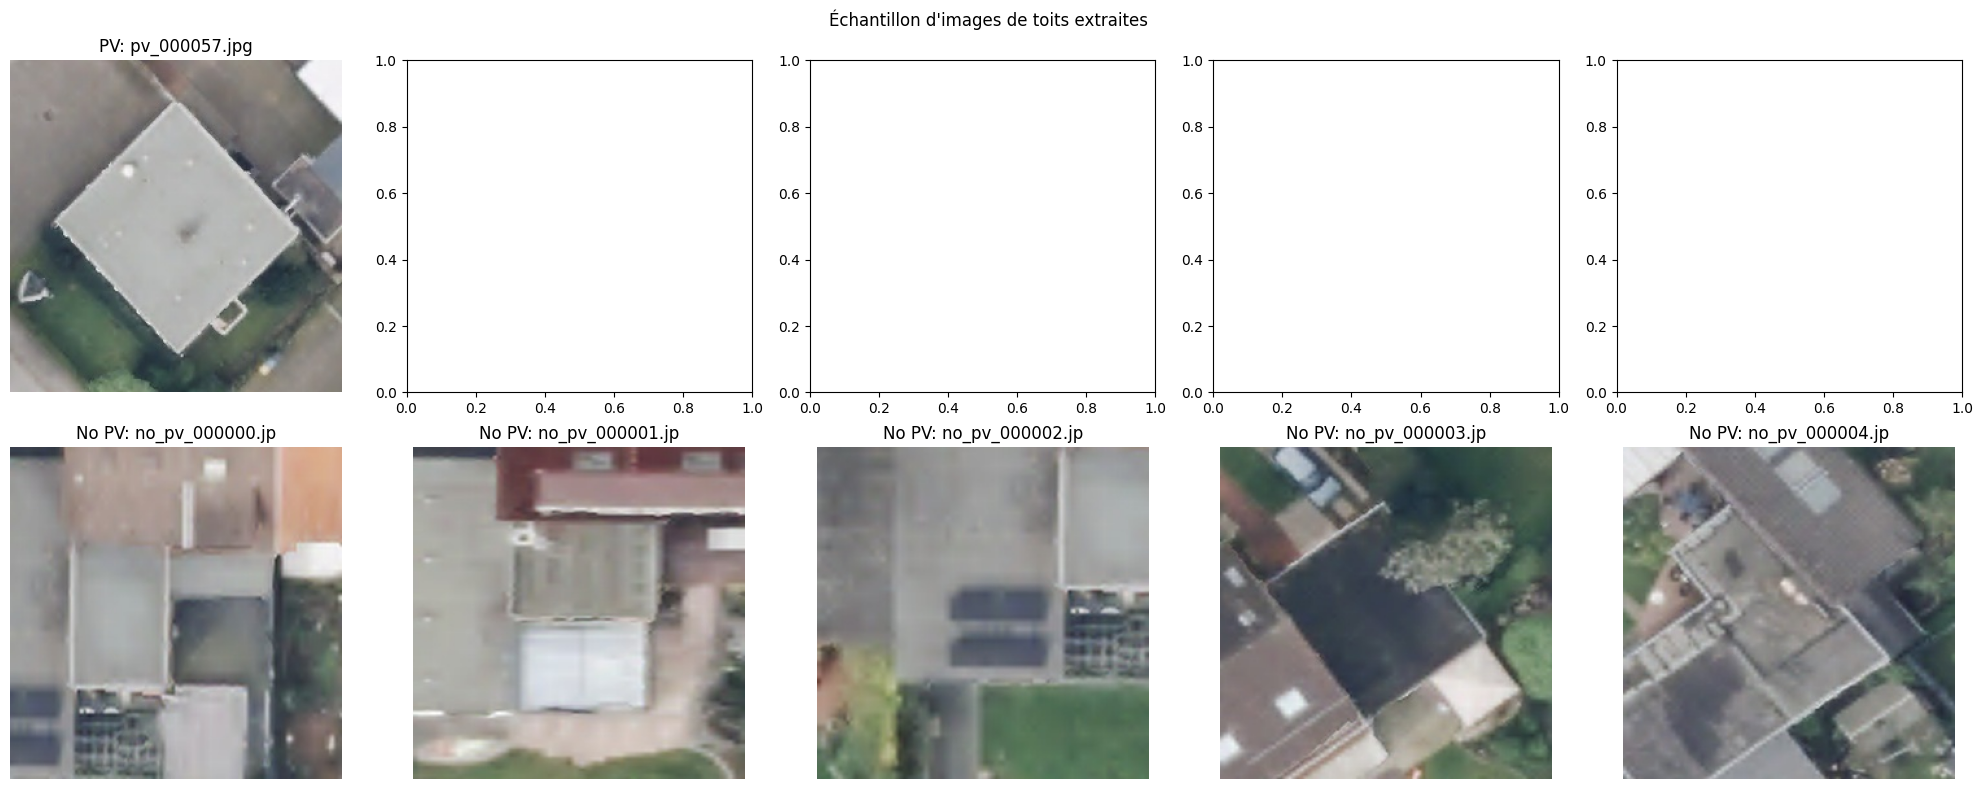

In [ ]:
# =============================================================================
# ÉTAPE 3 — Visualiser quelques images extraites
# =============================================================================

roof_dir = os.path.join(DATA_ROOT, city_name, "roof_images")
images = os.listdir(roof_dir)

# Afficher quelques images avec et sans PV
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

pv_images = [f for f in images if f.startswith('pv_')][:5]
no_pv_images = [f for f in images if f.startswith('no_pv_')][:5]

for i, img_name in enumerate(pv_images):
    img = Image.open(os.path.join(roof_dir, img_name))
    axes[0][i].imshow(img)
    axes[0][i].set_title(f"PV: {img_name[:15]}")
    axes[0][i].axis('off')

for i, img_name in enumerate(no_pv_images):
    img = Image.open(os.path.join(roof_dir, img_name))
    axes[1][i].imshow(img)
    axes[1][i].set_title(f"No PV: {img_name[:15]}")
    axes[1][i].axis('off')

plt.suptitle("Échantillon d'images de toits extraites")
plt.tight_layout()
plt.savefig('roof_samples.png', dpi=150)
plt.show()

## 5.8 — PV Image Augmentation

In [ ]:
def augment_pv_images(pv_folder: str, target_count: int = 100):
    """
    Augmente les images PV existantes par rotation, flip, luminosité.
    """
    pv_images = [f for f in os.listdir(pv_folder) if f.endswith('.jpg')]
    original_count = len(pv_images)
    
    print(f"Images PV originales : {original_count}")
    
    augmentations = [
        ('rot90', lambda img: img.rotate(90)),
        ('rot180', lambda img: img.rotate(180)),
        ('rot270', lambda img: img.rotate(270)),
        ('fliph', lambda img: img.transpose(Image.FLIP_LEFT_RIGHT)),
        ('flipv', lambda img: img.transpose(Image.FLIP_TOP_BOTTOM)),
        ('bright', lambda img: ImageEnhance.Brightness(img).enhance(1.3)),
        ('dark', lambda img: ImageEnhance.Brightness(img).enhance(0.7)),
        ('contrast', lambda img: ImageEnhance.Contrast(img).enhance(1.4)),
        ('blur', lambda img: img.filter(ImageFilter.GaussianBlur(radius=1))),
    ]
    
    count = original_count
    for img_name in pv_images:
        if count >= target_count:
            break
        img = Image.open(os.path.join(pv_folder, img_name))
        
        for aug_name, aug_fn in augmentations:
            if count >= target_count:
                break
            aug_img = aug_fn(img.copy())
            new_name = f"{aug_name}_{img_name}"
            aug_img.save(os.path.join(pv_folder, new_name), quality=95)
            count += 1
    
    print(f"  → Images PV après augmentation : {count}")

# Augmenter les images PV dans le dossier d'entraînement
pv_train_dir = os.path.join(DATA_ROOT, city_name, "yolo_dataset", "train", "solar_panel")
augment_pv_images(pv_train_dir, target_count=800)

Images PV originales : 159
  → Images PV après augmentation : 800


## 5.9 — Test Roof Images Extraction

In [69]:
# =============================================================================
# EXTRACTION D'IMAGES DE TEST (SANS LABEL)
# =============================================================================

def extract_test_images(df: pd.DataFrame, ortho_folder: str, output_dir: str,
                        start_idx: int = 500, n_images: int = 100,
                        output_size: int = 256, padding_m: float = 2.0):
    """Extrait des images de toits SANS labelling pour test du modèle."""
    os.makedirs(output_dir, exist_ok=True)
    
    # Déterminer le CRS
    test_geom = wkt.loads(df.iloc[0]['geometry'])
    geom_is_wgs84 = test_geom.centroid.x < 100
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:25832", always_xy=True) if geom_is_wgs84 else None
    
    # Indexer les orthophotos
    jp2_files = [f for f in os.listdir(ortho_folder) if f.endswith('.jp2')]
    ortho_index = []
    for f in jp2_files:
        path = os.path.join(ortho_folder, f)
        try:
            with rasterio.open(path) as src:
                b = src.bounds
                ortho_index.append({'path': path, 'left': b.left, 'right': b.right,
                                     'bottom': b.bottom, 'top': b.top})
        except:
            continue
    
    # Extraire à partir d'un index différent de l'entraînement
    df_test = df.iloc[start_idx:start_idx + n_images]
    extracted = 0
    
    print(f"Extraction de {len(df_test)} images de test (index {start_idx} à {start_idx + n_images})...")
    
    for i, (idx, row) in enumerate(df_test.iterrows()):
        try:
            if pd.isna(row['geometry']):
                continue
            
            geom = wkt.loads(row['geometry'])
            bounds = geom.bounds
            
            if transformer:
                minx, miny = transformer.transform(bounds[0], bounds[1])
                maxx, maxy = transformer.transform(bounds[2], bounds[3])
            else:
                minx, miny, maxx, maxy = bounds
            
            minx -= padding_m
            miny -= padding_m
            maxx += padding_m
            maxy += padding_m
            
            cx = (minx + maxx) / 2
            cy = (miny + maxy) / 2
            
            ortho_file = None
            for oi in ortho_index:
                if oi['left'] <= cx <= oi['right'] and oi['bottom'] <= cy <= oi['top']:
                    ortho_file = oi['path']
                    break
            
            if ortho_file is None:
                continue
            
            with rasterio.open(ortho_file) as src:
                window = from_bounds(minx, miny, maxx, maxy, src.transform)
                data = src.read([1, 2, 3], window=window)
                if data.shape[1] < 10 or data.shape[2] < 10:
                    continue
                
                img = np.transpose(data, (1, 2, 0))
                pil_img = Image.fromarray(img.astype(np.uint8))
                pil_img = pil_img.resize((output_size, output_size), Image.LANCZOS)
                
                # Nom simple avec adresse pour vérification manuelle
                street = str(row.get('street', 'unknown')).replace(' ', '_').replace('/', '-')[:40]
                filename = f"test_{idx:06d}_{street}.jpg"
                pil_img.save(os.path.join(output_dir, filename), quality=95)
                extracted += 1
                
        except:
            continue
    
    print(f"✓ {extracted} images de test extraites dans {output_dir}")
    return extracted

# Extraire 100 images de test (bâtiments 500-600, pas dans l'entraînement)
test_dir = os.path.join(DATA_ROOT, city_name, "roof_images_test")
extract_test_images(df_individual, ortho_folder, test_dir, start_idx=600, n_images=100)

Extraction de 100 images de test (index 600 à 700)...
✓ 100 images de test extraites dans C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw\Gelsenkirchen\roof_images_test


100

## 5.10 — 1000 Images Extraction for Labelling

In [82]:
# =============================================================================
# EXTRACTION MASSIVE + LABELLING ASSISTÉ
# =============================================================================

def extract_and_prepare_labelling(df: pd.DataFrame, ortho_folder: str, output_dir: str,
                                   n_images: int = 1000, output_size: int = 256,
                                   padding_m: float = 2.0):
    """
    Extrait un grand nombre d'images de toits pour labelling manuel.
    Inclut un lien Google Maps pour chaque image pour faciliter la vérification.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    test_geom = wkt.loads(df.iloc[0]['geometry'])
    geom_is_wgs84 = test_geom.centroid.x < 100
    transformer_to_utm = Transformer.from_crs("EPSG:4326", "EPSG:25832", always_xy=True) if geom_is_wgs84 else None
    transformer_to_wgs = Transformer.from_crs("EPSG:25832", "EPSG:4326", always_xy=True) if not geom_is_wgs84 else None
    
    # Indexer orthophotos
    jp2_files = [f for f in os.listdir(ortho_folder) if f.endswith('.jp2')]
    ortho_index = []
    for f in jp2_files:
        path = os.path.join(ortho_folder, f)
        try:
            with rasterio.open(path) as src:
                b = src.bounds
                ortho_index.append({'path': path, 'left': b.left, 'right': b.right,
                                     'bottom': b.bottom, 'top': b.top})
        except:
            continue
    
    # Échantillonner aléatoirement
    sample = df.sample(n=min(n_images, len(df)), random_state=42)
    
    extracted = 0
    log_entries = []
    
    print(f"Extraction de {len(sample)} images pour labelling...")
    
    for i, (idx, row) in enumerate(sample.iterrows()):
        if i % 200 == 0:
            print(f"  {i}/{len(sample)} — {extracted} extraits")
        
        try:
            if pd.isna(row['geometry']):
                continue
            
            geom = wkt.loads(row['geometry'])
            bounds = geom.bounds
            centroid = geom.centroid
            
            # Coordonnées UTM pour extraction
            if transformer_to_utm:
                minx, miny = transformer_to_utm.transform(bounds[0], bounds[1])
                maxx, maxy = transformer_to_utm.transform(bounds[2], bounds[3])
                lat, lon = centroid.y, centroid.x
            else:
                minx, miny, maxx, maxy = bounds
                lon_wgs, lat_wgs = transformer_to_wgs.transform(centroid.x, centroid.y)
                lat, lon = lat_wgs, lon_wgs
            
            minx -= padding_m
            miny -= padding_m
            maxx += padding_m
            maxy += padding_m
            
            cx = (minx + maxx) / 2
            cy = (miny + maxy) / 2
            
            ortho_file = None
            for oi in ortho_index:
                if oi['left'] <= cx <= oi['right'] and oi['bottom'] <= cy <= oi['top']:
                    ortho_file = oi['path']
                    break
            
            if ortho_file is None:
                continue
            
            with rasterio.open(ortho_file) as src:
                window = from_bounds(minx, miny, maxx, maxy, src.transform)
                data = src.read([1, 2, 3], window=window)
                if data.shape[1] < 10 or data.shape[2] < 10:
                    continue
                
                img = np.transpose(data, (1, 2, 0))
                pil_img = Image.fromarray(img.astype(np.uint8))
                pil_img = pil_img.resize((output_size, output_size), Image.LANCZOS)
                
                street = str(row.get('street', 'unknown')).replace(' ', '_').replace('/', '-')[:40]
                filename = f"roof_{idx:06d}_{street}.jpg"
                pil_img.save(os.path.join(output_dir, filename), quality=95)
                
                log_entries.append({
                    'filename': filename,
                    'index': idx,
                    'street': row.get('street', ''),
                    'building_type': row.get('building_type', ''),
                    'lat': round(lat, 6),
                    'lon': round(lon, 6),
                    'google_maps': f"https://www.google.com/maps/@{lat},{lon},19z",
                    'mastr_pv': bool(row.get('pv_panel', False)),
                    'label': ''  # À remplir manuellement
                })
                extracted += 1
                
        except:
            continue
    
    # Sauvegarder le log CSV pour faciliter le labelling
    df_log = pd.DataFrame(log_entries)
    log_path = os.path.join(output_dir, '_labelling_guide.csv')
    df_log.to_csv(log_path, index=False)
    
    print(f"\n✓ {extracted} images extraites")
    print(f"✓ Guide de labelling : {log_path}")
    print(f"\nPour labeller :")
    print(f"  1. Ouvrir {log_path} dans Excel")
    print(f"  2. Pour chaque image, cliquer le lien Google Maps")
    print(f"  3. Vérifier si le toit a un panneau solaire")
    print(f"  4. Remplir la colonne 'label' avec 'pv' ou 'no_pv'")
    
    return df_log

# Extraire 1000 images avec guide de labelling
labelling_dir = os.path.join(DATA_ROOT, city_name, "roof_images_labelling")
df_labelling = extract_and_prepare_labelling(
    df_individual, ortho_folder, labelling_dir, n_images=1000
)

Extraction de 1000 images pour labelling...
  0/1000 — 0 extraits
  200/1000 — 200 extraits
  400/1000 — 400 extraits
  600/1000 — 600 extraits
  800/1000 — 800 extraits

✓ 1000 images extraites
✓ Guide de labelling : C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw\Gelsenkirchen\roof_images_labelling\_labelling_guide.csv

Pour labeller :
  1. Ouvrir C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw\Gelsenkirchen\roof_images_labelling\_labelling_guide.csv dans Excel
  2. Pour chaque image, cliquer le lien Google Maps
  3. Vérifier si le toit a un panneau solaire
  4. Remplir la colonne 'label' avec 'pv' ou 'no_pv'


## 5.11 — Labelled Images Organization for YOLO

In [86]:
# =============================================================================
# ORGANISER LES IMAGES LABELLISÉES POUR YOLO
# =============================================================================

def organize_labelled_images(labelling_dir: str, yolo_dir: str, train_ratio: float = 0.8):
    """
    Lit le CSV de labelling et organise les images en structure YOLO.
    """
    print(f"label dir :  {labelling_dir}")
    log_path = os.path.join(labelling_dir, '_labelling_guide.csv')
    df_labels = pd.read_csv(log_path, sep = ";")
    
    # Filtrer les images labellisées
    df_labelled = df_labels[df_labels['label'].isin(['pv', 'no_pv'])]
    print(f"Images labellisées : {len(df_labelled)}")
    print(f"  PV     : {(df_labelled['label'] == 'pv').sum()}")
    print(f"  No PV  : {(df_labelled['label'] == 'no_pv').sum()}")
    
    if len(df_labelled) == 0:
        print("❌ Aucune image labellisée — remplir la colonne 'label' dans le CSV")
        return
    
    # Créer la structure YOLO
    for split in ['train', 'val']:
        for cls in ['solar_panel', 'no_solar_panel']:
            os.makedirs(os.path.join(yolo_dir, split, cls), exist_ok=True)
    
    # Mélanger et splitter
    df_labelled = df_labelled.sample(frac=1, random_state=42)
    split_idx = int(len(df_labelled) * train_ratio)
    
    for i, (_, row) in enumerate(df_labelled.iterrows()):
        src_path = os.path.join(labelling_dir, row['filename'])
        if not os.path.exists(src_path):
            continue
        
        split = 'train' if i < split_idx else 'val'
        cls = 'solar_panel' if row['label'] == 'pv' else 'no_solar_panel'
        
        dst_path = os.path.join(yolo_dir, split, cls, row['filename'])
        shutil.copy(src_path, dst_path)
    
    # Compter
    for split in ['train', 'val']:
        for cls in ['solar_panel', 'no_solar_panel']:
            n = len(os.listdir(os.path.join(yolo_dir, split, cls)))
            print(f"  {split}/  {cls}: {n}")

# Après avoir rempli le CSV, organiser
yolo_dir_v2 = os.path.join(DATA_ROOT, city_name, "yolo_dataset_v2")
organize_labelled_images(labelling_dir, yolo_dir_v2)

label dir :  C:\Users\alexandre.batisse\.vscode\Projet\Use_Case_5_SCALIAN_x_COENERGY\data\Raw\Gelsenkirchen\roof_images_labelling
Images labellisées : 599
  PV     : 23
  No PV  : 576
  train/  solar_panel: 19
  train/  no_solar_panel: 460
  val/  solar_panel: 4
  val/  no_solar_panel: 116


## 5.12 — CLIP Pre-trained Model Test (alternative)

In [ ]:
# =============================================================================
# OPTION 1 : Utiliser un modèle pré-entraîné depuis Hugging Face
# =============================================================================

# pip install transformers torch

# Modèle de classification d'images pré-entraîné pour panneaux solaires
# Plusieurs options sur Hugging Face :
# - "google/vit-base-patch16-224" (Vision Transformer, fine-tunable)
# - Des modèles spécifiques solar panel detection

# Tester avec un ViT générique + zero-shot classification

def test_pretrained_solar_detection(image_path: str):
    """Teste un modèle pré-entraîné de classification d'images."""
    
    # Zero-shot classification avec CLIP
    classifier = pipeline("zero-shot-image-classification", 
                          model="openai/clip-vit-base-patch32")
    
    img = Image.open(image_path)
    
    results = classifier(
        img,
        candidate_labels=["rooftop with solar panels installed",
                          "rooftop without solar panels",
                          "building roof with photovoltaic modules",
                          "empty building roof"]
    )
    
    print(f"Image : {os.path.basename(image_path)}")
    for r in results:
        print(f"  {r['label']:45s} : {r['score']*100:.1f}%")
    
    # Simplifier le résultat
    solar_score = sum(r['score'] for r in results if 'solar' in r['label'] or 'photovoltaic' in r['label'])
    no_solar_score = sum(r['score'] for r in results if 'without' in r['label'] or 'empty' in r['label'])
    
    print(f"\n  Solar : {solar_score*100:.1f}% | No solar : {no_solar_score*100:.1f}%")
    return solar_score > no_solar_score, solar_score

# Tester sur quelques images
test_dir = os.path.join(DATA_ROOT, city_name, "roof_images_test")
test_images = sorted(os.listdir(test_dir))[:26]

for img_name in test_images:
    test_pretrained_solar_detection(os.path.join(test_dir, img_name))
    print()

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 20064.82it/s]


Image : test_000500_Am_Bowengarten_163.jpg
  empty building roof                           : 75.8%
  rooftop without solar panels                  : 18.7%
  rooftop with solar panels installed           : 3.8%
  building roof with photovoltaic modules       : 1.7%

  Solar : 24.2% | No solar : 94.5%



Loading weights: 100%|██████████| 398/398 [00:00<00:00, 20853.37it/s]


Image : test_000501_Am_Bowengarten_165.jpg
  empty building roof                           : 84.7%
  rooftop without solar panels                  : 11.0%
  rooftop with solar panels installed           : 2.3%
  building roof with photovoltaic modules       : 2.1%

  Solar : 15.3% | No solar : 95.6%



Loading weights: 100%|██████████| 398/398 [00:00<00:00, 22816.94it/s]


...

Image : test_000523_Steinstraße_2.jpg
  rooftop without solar panels                  : 42.4%
  empty building roof                           : 31.0%
  rooftop with solar panels installed           : 20.7%
  building roof with photovoltaic modules       : 5.8%

  Solar : 69.0% | No solar : 73.4%



Loading weights: 100%|██████████| 398/398 [00:00<00:00, 22884.50it/s]


Image : test_000524_nan.jpg
  empty building roof                           : 50.7%
  rooftop without solar panels                  : 45.3%
  rooftop with solar panels installed           : 3.1%
  building roof with photovoltaic modules       : 0.9%

  Solar : 49.3% | No solar : 96.0%



Loading weights: 100%|██████████| 398/398 [00:00<00:00, 27317.30it/s]


Image : test_000525_nan.jpg
  empty building roof                           : 80.3%
  rooftop without solar panels                  : 16.1%
  rooftop with solar panels installed           : 2.3%
  building roof with photovoltaic modules       : 1.3%

  Solar : 19.7% | No solar : 96.4%



In [157]:
def test_clip_solar_detection(image_path: str, classifier=None):
    """Teste la détection PV avec CLIP — scoring corrigé."""
    
    if classifier is None:
        classifier = pipeline("zero-shot-image-classification",
                              model="openai/clip-vit-base-patch32")
    
    img = Image.open(image_path)
    
    results = classifier(
        img,
        candidate_labels=["rooftop with solar panels installed",
                          "rooftop without solar panels",
                          "building roof with photovoltaic modules",
                          "empty building roof"]
    )
    
    # Score corrigé : seuls les labels POSITIFS comptent
    scores = {r['label']: r['score'] for r in results}
    
    solar_positive = (scores.get("rooftop with solar panels installed", 0) + 
                      scores.get("building roof with photovoltaic modules", 0))
    solar_negative = (scores.get("rooftop without solar panels", 0) + 
                      scores.get("empty building roof", 0))
    
    # Décision basée sur tes résultats ground truth :
    # Les vrais PV ont solar_positive > 35% ET solar_negative < 65%
    # Les faux positifs ont solar_negative > 65%
    has_pv = solar_positive > 0.35 and solar_negative < 0.65
    
    return {
        'image': os.path.basename(image_path),
        'solar_positive': round(solar_positive * 100, 1),
        'solar_negative': round(solar_negative * 100, 1),
        'has_pv': has_pv,
        'scores': scores,
    }

In [ ]:
# =============================================================================
# TEST CLIP SUR TOUT LE DATASET DE TEST
# =============================================================================

classifier = pipeline("zero-shot-image-classification",
                      model="openai/clip-vit-base-patch32")

test_dir = os.path.join(DATA_ROOT, city_name, "roof_images_test")
test_images = sorted([f for f in os.listdir(test_dir) if f.endswith('.jpg')])

print(f"Test CLIP sur {len(test_images)} images...")
print(f"{'='*70}")

all_results = []

for img_name in test_images:
    img_path = os.path.join(test_dir, img_name)
    result = test_clip_solar_detection(img_path, classifier)
    all_results.append(result)
    
    if result['has_pv']:
        print(f"  🔆 {img_name[:50]:50s} | solar={result['solar_positive']:.1f}% neg={result['solar_negative']:.1f}%")

# Résumé
df_clip = pd.DataFrame(all_results)
n_pv = df_clip['has_pv'].sum()
print(f"\n{'='*70}")
print(f"RÉSUMÉ CLIP")
print(f"{'='*70}")
print(f"  Solar panel détecté : {n_pv}/{len(df_clip)} ({n_pv/len(df_clip)*100:.1f}%)")
print(f"\n  Détections :")
for _, row in df_clip[df_clip['has_pv']].iterrows():
    print(f"    {row['image'][:50]} (solar={row['solar_positive']:.1f}%, neg={row['solar_negative']:.1f}%)")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 12260.44it/s]


Test CLIP sur 200 images...
  🔆 test_000502_nan.jpg                                | solar=49.3% neg=50.7%
  🔆 test_000508_Am_Bugapark_69.jpg                     | solar=58.3% neg=41.7%
  🔆 test_000513_Am_Bugapark_1d.jpg                     | solar=48.9% neg=51.1%
  🔆 test_000515_nan.jpg                                | solar=38.1% neg=61.9%
  🔆 test_000517_Am_Bugapark_60.jpg                     | solar=37.9% neg=62.1%
  🔆 test_000552_nan.jpg                                | solar=37.7% neg=62.3%
  🔆 test_000561_Lange_Straße_62.jpg                    | solar=47.3% neg=52.7%
  🔆 test_000588_nan.jpg                                | solar=35.1% neg=64.9%
  🔆 test_000618_Rosenstraße_89.jpg                     | solar=40.1% neg=59.9%
  🔆 test_000630_nan.jpg                                | solar=40.1% neg=59.9%
  🔆 test_000651_nan.jpg                                | solar=38.0% neg=62.0%
  🔆 test_000699_nan.jpg                                | solar=43.7% neg=56.3%

RÉSUMÉ CLIP
  Solar pan

# ═══════════════════════════════════════════════════════════════
# PART 6 — USE CASE 5 PART 2 (future work)
# ═══════════════════════════════════════════════════════════════